# DESI PV Y3 $z$-bin TFR Calibration w/o zero-pointing

In redshift bins of width 0.001 (or 0.005), identify DESI observations with measurements suitable for the Tully-Fisher relation. Export the SGA IDs of the TFR galaxies and apply a multi-bin joint fit to calibrate the TFR at $0.4R_{26}$.  Only use those galaxies identified as being part of the central population based on an elliptical fit within each redshift bin.

Version: **27 July 2026**

**Note:** This requires using a subclassed version of `hyperfit`.

In [3]:
import numpy as np

import matplotlib.pyplot as plt
plt.rcParams['text.usetex'] = False
from matplotlib import cm, colors
from matplotlib.patches import Ellipse
import matplotlib as mpl

# We have more than 10 redshift bins, so we need to change the default color map so that they are all plotted with different colors
# from cycler import cycler
# plt.rcParams['axes.prop_cycle'] = cycler('color', plt.get_cmap('tab20').colors)

import ligo.skymap.plot

from astropy.table import Table, vstack, join
from astropy.coordinates import SkyCoord, Distance
from astropy.cosmology import Planck18, FlatLambdaCDM
from astropy.wcs import WCS
from astropy.visualization.wcsaxes import SphericalCircle
from astropy import units as u
from astropy import constants as c
from astropy import constants as const
from astropy.io import fits

from cosmoprimo.fiducial import DESI

from scipy.spatial.distance import cdist, euclidean

import os

from corner import corner, hist2d
import math
import pickle

from sklearn.covariance import EllipticEnvelope
from matplotlib.patches import Ellipse
from scipy.stats import chi2

from tqdm import tqdm
from hdbscan import HDBSCAN
from scipy.stats import binned_statistic
from matplotlib.projections import get_projection_names

from desiutil.plots import init_sky

# Custom functions / classes
import sys
# sys.path.insert(1, '/global/u1/k/kadglass/DESI_SGA/TF/')
# sys.path.insert(1, '/Users/kdouglass/Documents/Research/DESI/PV_survey/code/TF/')
sys.path.insert(1, '/global/u1/s/sgmoore1/DESI_SGA/TF/')
from help_functions import adjust_lightness
from line_fits import hyperfit_line_multi
from TF_photoCorrect import BASS_corr, MW_dust, k_corr, internal_dust
from z_CMB_convert import convert_z_frame

/global/homes/s/sgmoore1/.conda/envs/astro-base/lib/python3.10/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


In [4]:
# Base values for later conversions (all in units in km/s).
c_kms = c.c.to_value('km/s')

h = 1.
H0 = 100*h

q0 = 0.2

# Access SGA Iron Data

The following selections have already been applied:
* `DELTACHI2 > 25` & `ZWARN = 0` for the centers
* $10 < V < 1000$ km/s and $\Delta V / V_\text{min}$ for the observations at $0.4R_{26}$
* Visual inspection

In [5]:
# sgapath = '/global/cfs/cdirs/desi/science/td/pv/tfgalaxies/Y1'
sgapath = 'vrot_cats'
# sgafits = os.path.join(sgapath, 'SGA-2020_loa_Vrot.fits')
sgafits = os.path.join(sgapath, 'SGA-2020_loa_Vrot_v5.fits')

sgatab = Table.read(sgafits)
sgatab[:5]

SGA_ID,SGA_GALAXY,GALAXY,PGC,RA_LEDA,DEC_LEDA,MORPHTYPE,PA_LEDA,D25_LEDA,BA_LEDA,Z_LEDA,SB_D25_LEDA,MAG_LEDA,BYHAND,REF,GROUP_ID,GROUP_NAME,GROUP_MULT,GROUP_PRIMARY,GROUP_RA,GROUP_DEC,GROUP_DIAMETER,BRICKNAME,RA,DEC,D26,D26_REF,PA,BA,RA_MOMENT,DEC_MOMENT,SMA_MOMENT,G_SMA50,R_SMA50,Z_SMA50,SMA_SB22,SMA_SB22.5,SMA_SB23,SMA_SB23.5,SMA_SB24,SMA_SB24.5,SMA_SB25,SMA_SB25.5,SMA_SB26,G_MAG_SB22,R_MAG_SB22,Z_MAG_SB22,G_MAG_SB22.5,R_MAG_SB22.5,Z_MAG_SB22.5,G_MAG_SB23,R_MAG_SB23,Z_MAG_SB23,G_MAG_SB23.5,R_MAG_SB23.5,Z_MAG_SB23.5,G_MAG_SB24,R_MAG_SB24,Z_MAG_SB24,G_MAG_SB24.5,R_MAG_SB24.5,Z_MAG_SB24.5,G_MAG_SB25,R_MAG_SB25,Z_MAG_SB25,G_MAG_SB25.5,R_MAG_SB25.5,Z_MAG_SB25.5,G_MAG_SB26,R_MAG_SB26,Z_MAG_SB26,SMA_SB22_ERR,SMA_SB22.5_ERR,SMA_SB23_ERR,SMA_SB23.5_ERR,SMA_SB24_ERR,SMA_SB24.5_ERR,SMA_SB25_ERR,SMA_SB25.5_ERR,SMA_SB26_ERR,G_MAG_SB22_ERR,R_MAG_SB22_ERR,Z_MAG_SB22_ERR,G_MAG_SB22.5_ERR,R_MAG_SB22.5_ERR,Z_MAG_SB22.5_ERR,G_MAG_SB23_ERR,R_MAG_SB23_ERR,Z_MAG_SB23_ERR,G_MAG_SB23.5_ERR,R_MAG_SB23.5_ERR,Z_MAG_SB23.5_ERR,G_MAG_SB24_ERR,R_MAG_SB24_ERR,Z_MAG_SB24_ERR,G_MAG_SB24.5_ERR,R_MAG_SB24.5_ERR,Z_MAG_SB24.5_ERR,G_MAG_SB25_ERR,R_MAG_SB25_ERR,Z_MAG_SB25_ERR,G_MAG_SB25.5_ERR,R_MAG_SB25.5_ERR,Z_MAG_SB25.5_ERR,G_MAG_SB26_ERR,R_MAG_SB26_ERR,Z_MAG_SB26_ERR,G_COG_PARAMS_MTOT,G_COG_PARAMS_M0,G_COG_PARAMS_ALPHA1,G_COG_PARAMS_ALPHA2,G_COG_PARAMS_CHI2,R_COG_PARAMS_MTOT,R_COG_PARAMS_M0,R_COG_PARAMS_ALPHA1,R_COG_PARAMS_ALPHA2,R_COG_PARAMS_CHI2,Z_COG_PARAMS_MTOT,Z_COG_PARAMS_M0,Z_COG_PARAMS_ALPHA1,Z_COG_PARAMS_ALPHA2,Z_COG_PARAMS_CHI2,ELLIPSEBIT,Z_DESI,ZERR_DESI,PHOTSYS,V_0p4R26,V_0p4R26_ERR,LOGVROT,LOGVROT_ERR,logV_SBcorr,logV_correction_factor,logV_SBcorr_err
int64,bytes16,bytes29,int64,float64,float64,bytes21,float32,float32,float32,float32,float32,float32,bool,bytes13,int64,bytes35,int16,bool,float64,float64,float32,bytes8,float64,float64,float32,bytes4,float32,float32,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int32,float64,float64,bytes1,float64,float64,float64,float64,float64,float64,float64
20,SGA-2020 20,SDSSJ173412.71+572041.6,3331584,263.5529355,57.34490699999999,S?,152.58,0.4487454,0.5333349,0.08364453,24.92448,18.036,False,LEDA-20181114,5,SDSSJ173412.71+572041.6,1,True,263.5529355,57.34490699999999,0.4487454,2635p572,263.55294849855886,57.344862145664294,0.4460123,SB26,152.3756,0.5778338,263.5528114673963,57.34481025685253,10.459747,5.9780583,5.751067,4.821581,1.4858595,3.4448266,5.1149526,6.748707,8.426254,9.720271,11.022999,12.0887985,13.380368,20.656942,20.044735,19.40886,19.194794,18.66572,18.231262,18.599888,18.123905,17.745926,18.256256,17.807074,17.476473,18.040592,17.60353,17.319197,17.926336,17.500519,17.228865,17.85259,17.42695,17.180876,17.811844,17.39206,17.151228,17.783718,17.36542,17.143204,0.02069058,0.026094317,0.03480586,0.05076174,0.08751116,0.10309491,0.08337893,0.10982923,0.13734566,0.031223593,0.046367057,0.0777883,0.015935475,0.020728666,0.032657374,0.012760426,0.014699919,0.022893604,0.010505663,0.011998588,0.018923525,0.010358521,0.011374098,0.017719442,0.010557283,0.0112259,0.017149422,0.010553381,0.011049819,0.017135512,0.010413324,0.010993488,0.01699026,0.010291049,0.010862263,0.017057167,17.6411,0.6362121,0.53480667,2.8045392,1.7123051,17.22401,0.6144014,0.53440714,2.7180903,2.1161501,17.062769,0.44818503,0.43006793,3.1755726,0.9

In [6]:
### Make sure if we don't have a measurement in one of the bands, we switch the value to NaN
for col in ['G_MAG_SB26', 'R_MAG_SB26','Z_MAG_SB26']:
    sgatab[col][sgatab[col] == -1] = np.nan

## Compute maximum volume for each galaxy

Since the SGA is a size-limited catalog ($D_{26} > 0.2$ arcmin), there is a maximum volume within which each galaxy could be located to be included in the SGA.  Let's calculate that maximum volume so that we can use it as a weight in the TFR calibration.

In [7]:
Planck18_h = FlatLambdaCDM(H0=100, Om0=0.3151)

In [6]:
dist = Distance(z=np.abs(sgatab['Z_DESI']), cosmology=Planck18_h)

sgatab['D26_kpc'] = 2*dist.to('kpc')*np.tan(0.5*sgatab['D26']*u.arcmin)

sgatab['DIST_MAX'] = 0.5*sgatab['D26_kpc']/np.tan(0.1*u.arcmin)

dist_max = Distance(z=0.1, cosmology=Planck18_h)

sgatab['MAX_VOL_FRAC'] = sgatab['DIST_MAX'].to('Mpc')**3 / dist_max.to('Mpc')**3

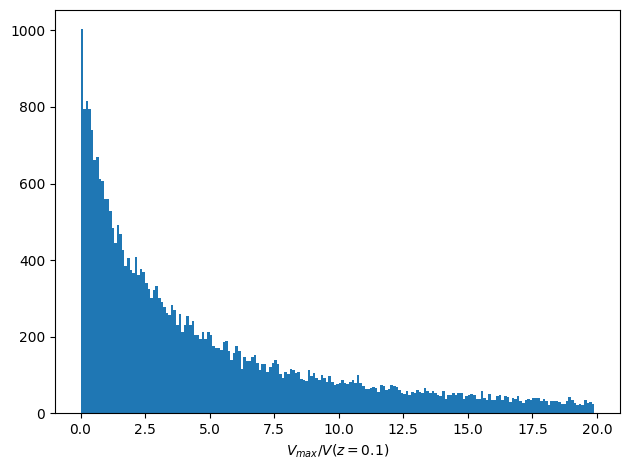

In [7]:
plt.figure(tight_layout=True)

plt.hist(sgatab['MAX_VOL_FRAC'], np.arange(0, 20, 0.1))

plt.xlabel('$V_{max}$/$V(z = 0.1)$');

## Convert to CMB frame

In [8]:
sgatab['Z_DESI_CMB'] = convert_z_frame(sgatab['Z_DESI'], sgatab['RA'], sgatab['DEC'])

In [9]:
np.min(sgatab["Z_DESI"]), len(sgatab[sgatab["Z_DESI"]<0])

(-0.0006685686534794439, 4)

# Load Morphological Classification

## SSL

As an alternative to morphological classification of the galaxies, we also produced a classification based on the SSL sorter (using a nearest-neighbor query; Largett et al., in prep.). The classification ignored the Hubble sub-types and grouped the galaxies into four main categories:
1. Spiral
2. Elliptical
3. Lenticular
4. Irregular

Let's also load this table and add it to the SGA table.

In [10]:
# ai_morphpath = '/global/cfs/cdirs/desi/science/td/pv'
ai_morphpath = '.'
# ai_morphpath = '/global/cfs/cdirs/desi/science/td/pv/SGA2020'
# ai_morphcsv = os.path.join(ai_morphpath, 'sga10278_morphologies_model_analysis.csv')
ai_morphcsv = '/global/homes/s/sgmoore1/DESI_SGA/TF/Y3/SGAY3TFMorphologies.csv'
ai_morphtab = Table.read(ai_morphcsv)
ai_morphtab

SGA_ID,Predicted_Type_spiral,Predicted_Type_elliptical,Predicted_Type_irregular,Predicted_Type_lenticular,Predicted_Type
float64,str6,str10,str9,str10,str10
218203.0,Other,Other,Irregular,Other,Irregular
218205.0,Other,Other,Irregular,Other,Irregular
218239.0,Other,Other,Irregular,Other,Irregular
218275.0,Other,Other,Irregular,Other,Irregular
218304.0,Spiral,Other,Other,Other,Spiral
218367.0,Other,Other,Irregular,Other,Irregular
218376.0,Spiral,Other,Other,Other,Spiral
218201.0,Other,Other,Irregular,Other,Irregular
218385.0,Spiral,Other,Other,Other,Spiral


### Combine ML morphtypes with SGA catalog

In [11]:
sgatab = join(sgatab, ai_morphtab['SGA_ID', 'Predicted_Type'], keys='SGA_ID', join_type='left')

# Rename Predicted_Type to MORPHTYPE_AI
sgatab['Predicted_Type'].name = 'MORPHTYPE_AI'

## John Lucey's VI results

https://astro.dur.ac.uk/~jrl/DESI_TF_Y3/index.html

We are only considering galaxies that he considers bad for TF (strong asymmetry, double galaxies, stellar contamination).

In [12]:
lucey_VIpath = 'VI_JohnLucey/'

rejects = lucey_VIpath + 'REJECTS.txt'

reject_tab = Table.read(rejects, format='ascii.commented_header')
reject_tab['VI'] = 'reject'
reject_tab

SGA_ID,DESI_NAME,RA,Dec,z_desi,BA,G_R,G_R_err,V_0p4R26,V_0p4R26_err,R_MAG_SB26_CORR,R_MAG_SB26_ERR_CORR,LOGDIST_AVG,LOGDIST_AVG_ERR,MAIN,VI
int64,str22,float64,float64,float64,float64,float64,float64,int64,int64,float64,float64,float64,float64,int64,str6
692,DESIXJ12411157+1819512,190.298193,18.330884,0.0691,0.5,0.4903,0.0288,85,6,16.7987,0.1126,0.1983,0.0552,0,reject
2526,DESIXJ10124098+4543539,153.170765,45.731651,0.0241,0.3969,0.3677,0.0227,46,6,16.4224,0.1398,0.1804,0.0717,0,reject
2804,DESIXJ07581109+3420293,119.546191,34.341483,0.0198,0.2924,0.5585,0.035,121,5,14.3538,0.1607,-0.0479,0.0527,0,reject
3420,DESIXJ01135557+0034028,18.48153,0.567434,0.0418,0.761,0.3742,0.0169,82,22,16.5482,0.0542,0.0391,0.1185,0,reject
5964,DESIXJ16261820+4219580,246.57584,42.332773,0.0465,0.9154,0.3389,0.0122,41,23,16.543,0.0311,0.4811,0.2514,0,reject
6243,DESIXJ13403564+1214293,205.148492,12.241463,0.0927,0.6161,0.8506,0.0122,315,14,15.3396,0.0872,-0.1452,0.0505,0,reject
6493,DESIXJ12450567+1054032,191.273606,10.900881,0.0035,0.8997,0.6761,0.0011,213,23,13.575,0.0287,-0.8711,0.0609,0,reject
7553,DESIXJ09534429-0005255,148.434553,-0.090407,0.0836,0.7665,0.6715,0.0185,237,20,15.136,0.0574,0.0103,0.0557,0,reject
8007,DESIXJ03051303-0700487,46.304307,-7.013516,0.0284,0.427,0.4408,0.0256,25,10,16.5644,0.1281,0.5769,0.1991,0,reject


### Combine John's results with Y1 TF sample

In [13]:
sgatab = join(sgatab, reject_tab['SGA_ID', 'VI'], keys='SGA_ID', join_type='left')

# Rename VI column to JOHN_VI
sgatab['VI'].name = 'JOHN_VI'

In [14]:
sgatab[:5]

SGA_ID,SGA_GALAXY,GALAXY,PGC,RA_LEDA,DEC_LEDA,MORPHTYPE,PA_LEDA,D25_LEDA,BA_LEDA,Z_LEDA,SB_D25_LEDA,MAG_LEDA,BYHAND,REF,GROUP_ID,GROUP_NAME,GROUP_MULT,GROUP_PRIMARY,GROUP_RA,GROUP_DEC,GROUP_DIAMETER,BRICKNAME,RA,DEC,D26,D26_REF,PA,BA,RA_MOMENT,DEC_MOMENT,SMA_MOMENT,G_SMA50,R_SMA50,Z_SMA50,SMA_SB22,SMA_SB22.5,SMA_SB23,SMA_SB23.5,SMA_SB24,SMA_SB24.5,SMA_SB25,SMA_SB25.5,SMA_SB26,G_MAG_SB22,R_MAG_SB22,Z_MAG_SB22,G_MAG_SB22.5,R_MAG_SB22.5,Z_MAG_SB22.5,G_MAG_SB23,R_MAG_SB23,Z_MAG_SB23,G_MAG_SB23.5,R_MAG_SB23.5,Z_MAG_SB23.5,G_MAG_SB24,R_MAG_SB24,Z_MAG_SB24,G_MAG_SB24.5,R_MAG_SB24.5,Z_MAG_SB24.5,G_MAG_SB25,R_MAG_SB25,Z_MAG_SB25,G_MAG_SB25.5,R_MAG_SB25.5,Z_MAG_SB25.5,G_MAG_SB26,R_MAG_SB26,Z_MAG_SB26,SMA_SB22_ERR,SMA_SB22.5_ERR,SMA_SB23_ERR,SMA_SB23.5_ERR,SMA_SB24_ERR,SMA_SB24.5_ERR,SMA_SB25_ERR,SMA_SB25.5_ERR,SMA_SB26_ERR,G_MAG_SB22_ERR,R_MAG_SB22_ERR,Z_MAG_SB22_ERR,G_MAG_SB22.5_ERR,R_MAG_SB22.5_ERR,Z_MAG_SB22.5_ERR,G_MAG_SB23_ERR,R_MAG_SB23_ERR,Z_MAG_SB23_ERR,G_MAG_SB23.5_ERR,R_MAG_SB23.5_ERR,Z_MAG_SB23.5_ERR,G_MAG_SB24_ERR,R_MAG_SB24_ERR,Z_MAG_SB24_ERR,G_MAG_SB24.5_ERR,R_MAG_SB24.5_ERR,Z_MAG_SB24.5_ERR,G_MAG_SB25_ERR,R_MAG_SB25_ERR,Z_MAG_SB25_ERR,G_MAG_SB25.5_ERR,R_MAG_SB25.5_ERR,Z_MAG_SB25.5_ERR,G_MAG_SB26_ERR,R_MAG_SB26_ERR,Z_MAG_SB26_ERR,G_COG_PARAMS_MTOT,G_COG_PARAMS_M0,G_COG_PARAMS_ALPHA1,G_COG_PARAMS_ALPHA2,G_COG_PARAMS_CHI2,R_COG_PARAMS_MTOT,R_COG_PARAMS_M0,R_COG_PARAMS_ALPHA1,R_COG_PARAMS_ALPHA2,R_COG_PARAMS_CHI2,Z_COG_PARAMS_MTOT,Z_COG_PARAMS_M0,Z_COG_PARAMS_ALPHA1,Z_COG_PARAMS_ALPHA2,Z_COG_PARAMS_CHI2,ELLIPSEBIT,Z_DESI,ZERR_DESI,PHOTSYS,V_0p4R26,V_0p4R26_ERR,LOGVROT,LOGVROT_ERR,logV_SBcorr,logV_correction_factor,logV_SBcorr_err,D26_kpc,DIST_MAX,MAX_VOL_FRAC,Z_DESI_CMB,MORPHTYPE_AI,JOHN_VI
,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,kpc,kpc,,,,
float64,bytes16,bytes29,int64,float64,float64,bytes21,float32,float32,float32,float32,float32,float32,bool,bytes13,int64,bytes35,int16,bool,float64,float64,float32,bytes8,float64,float64,float32,bytes4,float32,float32,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int32,float64,float64,bytes1,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,str10,str6
20.0,SGA-2020 20,SDSSJ173412.71+572041.6,3331584,263.5529355,57.34490699999999,S?,152.58,0.4487454,0.5333349,0.08364453,24.92448,18.036,False,LEDA-20181114,5,SDSSJ173412.71+572041.6,1,True,263.5529355,57.34490699999999,0.4487454,2635p572,263.55294849855886,57.344862145664294,0.4460123,SB26,152.3756,0.5778338,263.5528114673963,57.34481025685253,10.459747,5.9780583,5.751067,4.821581,1.4858595,3.4448266,5.1149526,6.748707,8.426254,9.720271,11.022999,12.0887985,13.380368,20.656942,20.044735,19.40886,19.194794,18.66572,18.231262,18.599888,18.123905,17.745926,18.256256,17.807074,17.476473,18.040592,17.60353,17.319197,17.926336,17.500519,17.228865,17.85259,17.42695,17.180876,17.811844,17.39206,17.151228,17.783718,17.36542,17.143204,0.02069058,0.026094317,0.03480586,0.05076174,0.08751116,0.10309491,0.08337893,0.10982923,0.13734566,0.031223593,0.046367057,0.0777883,0.015935475,0.020728666,0.032657374,0.012760426,0.014699919,0.022893604,0.010505663,0.011998588,0.018923525,0.010358521,0.011374098,0.017719442,0.010557283,0.0112259,0.0171494

## Override classification for large galaxies based on VI

We have manually assigned classifications for all of the objects with $D26> 1$ arcmin using `Morphology_VI.ipynb`. We will force the morphologies of these objects to match our VI classifications, and keep the SSL classifications for all of the smaller objects.

In [15]:
vi = Table.read('/pscratch/sd/s/sgmoore1/TF/DR2_TF_VI_morphology.fits')

vi['morphology_VI'][vi['morphology_VI'] == 'irregul'] = 'Irregular'
vi['morphology_VI'][vi['morphology_VI'] == 'spiral'] = 'Spiral'

/tmp/ipykernel_316534/1275941586.py:3: StringTruncateWarning: truncated right side string(s) longer than 7 character(s) during assignment
  vi['morphology_VI'][vi['morphology_VI'] == 'irregul'] = 'Irregular'


In [16]:
sgatab['MORPHTYPE_VI'] = vi['morphology_VI']

sgatab['MORPHTYPE'][sgatab['D26']>1] = sgatab['MORPHTYPE_VI'][sgatab['D26']>1]
sgatab['MORPHTYPE'][sgatab['D26']<1] = sgatab['MORPHTYPE_AI'][sgatab['D26']<1]    

# Remove contaminating ellipticals and lenticulars

Since we will independently calibrate on the spiral and irregular populations, we will remove any objects that have elliptical or lenticular morphologies, as well as any objects that do not receive classifications.

In [17]:
print(len(sgatab))

sgatab = sgatab[(sgatab['MORPHTYPE'] == 'Spiral') |(sgatab['MORPHTYPE'] == 'Irregular')]

print(len(sgatab))

35578
32488


# Photometric corrections

### Survey offsets

In [18]:
sys_corr, sys_corr_err = BASS_corr(sgatab['PHOTSYS'])

### MW dust corrections

In [19]:
# Import E(B-V) dust map
ebv_directory = '/global/cfs/cdirs/desicollab/users/rongpu/dust/desi_ebv/public_data/maps/'
# ebv_directory = '/Users/kdouglass/Documents/Research/data/DESI/'
ebv_filename = 'desi_dust_gr_512.fits'
ebv_map = Table.read(ebv_directory + ebv_filename)

In [20]:
MWdust_corr, MWdust_corr_err = MW_dust(sgatab['RA'], sgatab['DEC'], ebv_map)

/global/u1/s/sgmoore1/DESI_SGA/TF/TF_photoCorrect.py:90: UserWarning: Warning: converting a masked element to nan.
  EBV_err[i] = ebv_map['EBV_GR_ERR'][i_ebv]


In [21]:
# Flip NaN values to 0
MWdust_corr_err[np.isnan(MWdust_corr_err)] = 0

### Internal dust extinction correction

This is based off of a linear fit to ($b/a$, $m_r$), removing any correlation between $b/a$ and $m_r$.

In [22]:
# temp_infile = open('/pscratch/sd/s/sgmoore1/TF/pickles/loa_internalDust_z0p1_mcmc.pickle', 'rb')
temp_infile = open('/pscratch/sd/s/sgmoore1/TF/pickles/loa_internalDust_nokcorr_mcmc.pickle', 'rb')
# temp_infile = open('../loa_internalDust_nokcorr_mcmc.pickle', 'rb') #without k-corr
dust_mcmc_samples_r,_, dust_mcmc_samples_g,_, dust_mcmc_samples_z,_ = pickle.load(temp_infile)
temp_infile.close()

In [23]:
internalDust_coeffs_r = np.median(dust_mcmc_samples_r, axis=1)
internalDust_coeffs_g = np.median(dust_mcmc_samples_g, axis=1)
internalDust_coeffs_z = np.median(dust_mcmc_samples_z, axis=1)

internalDust_coeffs_err_r = np.zeros(len(internalDust_coeffs_r))
internalDust_coeffs_err_g = np.zeros(len(internalDust_coeffs_g))
internalDust_coeffs_err_z = np.zeros(len(internalDust_coeffs_z))

internalDust_coeffs_err_r[0] = np.std(dust_mcmc_samples_r[0][(-1.5 < dust_mcmc_samples_r[0]) & (dust_mcmc_samples_r[0] < 0)])
internalDust_coeffs_err_r[1] = np.std(dust_mcmc_samples_r[1][(0 < dust_mcmc_samples_r[1]) & (dust_mcmc_samples_r[1] < 1)])

internalDust_coeffs_err_g[0] = np.std(dust_mcmc_samples_g[0][(-1.5 < dust_mcmc_samples_g[0]) & (dust_mcmc_samples_g[0] < 0)])
internalDust_coeffs_err_g[1] = np.std(dust_mcmc_samples_g[1][(0 < dust_mcmc_samples_g[1]) & (dust_mcmc_samples_g[1] < 1)])

internalDust_coeffs_err_z[0] = np.std(dust_mcmc_samples_z[0][(-1.5 < dust_mcmc_samples_z[0]) & (dust_mcmc_samples_z[0] < 0)])
internalDust_coeffs_err_z[1] = np.std(dust_mcmc_samples_z[1][(0 < dust_mcmc_samples_z[1]) & (dust_mcmc_samples_z[1] < 1)])

In [24]:
internalDust_corr_r, internalDust_corr_err_r = internal_dust(sgatab['BA'], 
                                                             internalDust_coeffs_r, 
                                                             internalDust_coeffs_err_r)

internalDust_corr_g, internalDust_corr_err_g = internal_dust(sgatab['BA'], 
                                                             internalDust_coeffs_g, 
                                                             internalDust_coeffs_err_g)

internalDust_corr_z, internalDust_corr_err_z = internal_dust(sgatab['BA'], 
                                                             internalDust_coeffs_z, 
                                                             internalDust_coeffs_err_z)

In [25]:
print(internalDust_coeffs_r[0], internalDust_coeffs_err_r[0])


-0.7649209228168957 0.2173486175169116


## Apply corrections

In [26]:
##### without k-correction, since we are calibrating in redshift bins

sgatab['G_MAG_SB26_CORR'] = sgatab['G_MAG_SB26'] - MWdust_corr[0] + sys_corr - internalDust_corr_g
sgatab['R_MAG_SB26_CORR'] = sgatab['R_MAG_SB26'] - MWdust_corr[1] + sys_corr - internalDust_corr_r
sgatab['Z_MAG_SB26_CORR'] = sgatab['Z_MAG_SB26'] - MWdust_corr[2] + sys_corr - internalDust_corr_z

In [27]:
sgatab['G_MAG_SB26_ERR_CORR'] = np.sqrt(sgatab['G_MAG_SB26_ERR']**2 + MWdust_corr_err[0]**2 + sys_corr_err**2 + internalDust_corr_err_g**2)
sgatab['R_MAG_SB26_ERR_CORR'] = np.sqrt(sgatab['R_MAG_SB26_ERR']**2 + MWdust_corr_err[1]**2 + sys_corr_err**2 + internalDust_corr_err_r**2)
sgatab['Z_MAG_SB26_ERR_CORR'] = np.sqrt(sgatab['Z_MAG_SB26_ERR']**2 + MWdust_corr_err[2]**2 + sys_corr_err**2 + internalDust_corr_err_z**2)

In [28]:
#### Add extra columns for Alex 

sgatab['R_MWDUST_CORR'] = MWdust_corr[1]
sgatab['R_SYS_CORR'] = sys_corr
sgatab['R_INTDUST_CORR'] = internalDust_corr_r

sgatab['MU_ZCMB'] = 5*np.log10(Planck18_h.comoving_distance(sgatab["Z_DESI_CMB"]).value * (1 + sgatab["Z_DESI"]))+25
sgatab['MU_ZCMB'][sgatab['Z_DESI_CMB']<0] = Planck18_h.distmod(sgatab['Z_DESI_CMB'][sgatab['Z_DESI_CMB']<0])

sgatab['R_ABSMAG_SB26'] = sgatab['R_MAG_SB26_CORR'] - sgatab['MU_ZCMB'].value
sgatab['G_ABSMAG_SB26'] = sgatab['G_MAG_SB26_CORR'] - sgatab['MU_ZCMB'].value
sgatab['Z_ABSMAG_SB26'] = sgatab['Z_MAG_SB26_CORR'] - sgatab['MU_ZCMB'].value

# sgatab['logV'] = np.log10(sgatab['V_0p4R26'])
# sgatab['logV_ERR'] = 0.434*sgatab['V_0p4R26_ERR']/sgatab['V_0p4R26']

sgatab['R_ABSMAG_SB26_CORR'] = sgatab['R_ABSMAG_SB26']
sgatab['R_ABSMAG_SB26_ERR'] = sgatab['R_MAG_SB26_ERR_CORR']
sgatab['R_ABSMAG_SB26_ERR_CORR'] = sgatab['R_MAG_SB26_ERR_CORR']

sgatab['G_ABSMAG_SB26_CORR'] = sgatab['G_ABSMAG_SB26']
sgatab['G_ABSMAG_SB26_ERR'] = sgatab['G_MAG_SB26_ERR_CORR']
sgatab['G_ABSMAG_SB26_ERR_CORR'] = sgatab['G_MAG_SB26_ERR_CORR']

sgatab['Z_ABSMAG_SB26_CORR'] = sgatab['Z_ABSMAG_SB26']
sgatab['Z_ABSMAG_SB26_ERR'] = sgatab['Z_MAG_SB26_ERR_CORR']
sgatab['Z_ABSMAG_SB26_ERR_CORR'] = sgatab['Z_MAG_SB26_ERR_CORR']


# sgatab.write('/global/cfs/cdirs/desi/science/td/pv/tfgalaxies/Y3/SGA-2020_loa_Vrot.fits', overwrite=True)

/tmp/ipykernel_316534/3465912953.py:7: RuntimeWarning: invalid value encountered in log10
  sgatab['MU_ZCMB'] = 5*np.log10(Planck18_h.comoving_distance(sgatab["Z_DESI_CMB"]).value * (1 + sgatab["Z_DESI"]))+25


# Redshift bins

Separate the galaxies into redshift bins of width 0.005, starting at a redshift of 0, so that we can fit an ellipse in each redshift bin.
The optimal scale for these ellipse was determined using the TF mocks to be 2.86.

In [29]:
zmin=0
# zmin = 0.03
zmax = 0.1
dz = 0.005
zbins = np.arange(zmin, zmax+dz/2, dz)

zbin_indices = np.digitize(sgatab['Z_DESI_CMB'], zbins, right=True)
binwidth=dz

In [30]:
for i in range(len(zbins) + 1):
    if i == 0:
        print(f'{i:2d}  z <= {zbins[i]:0.3f}  {np.sum(zbin_indices == i):3d} galaxies')
    elif i == len(zbins):
        print(f'{i:2d}  z > {zbins[i-1]:0.3f}  {np.sum(zbin_indices == i):3d} galaxies')
    else:
        print(f'{i:2d}  {zbins[i-1]:0.3f} < z <= {zbins[i]:0.3f}  {np.sum(zbin_indices == i):3d} galaxies')

 0  z <= 0.000    1 galaxies
 1  0.000 < z <= 0.005  109 galaxies
 2  0.005 < z <= 0.010  390 galaxies
 3  0.010 < z <= 0.015  680 galaxies
 4  0.015 < z <= 0.020  1124 galaxies
 5  0.020 < z <= 0.025  1700 galaxies
 6  0.025 < z <= 0.030  2250 galaxies
 7  0.030 < z <= 0.035  2723 galaxies
 8  0.035 < z <= 0.040  2437 galaxies
 9  0.040 < z <= 0.045  2306 galaxies
10  0.045 < z <= 0.050  2006 galaxies
11  0.050 < z <= 0.055  1983 galaxies
12  0.055 < z <= 0.060  1840 galaxies
13  0.060 < z <= 0.065  1886 galaxies
14  0.065 < z <= 0.070  1748 galaxies
15  0.070 < z <= 0.075  1449 galaxies
16  0.075 < z <= 0.080  1418 galaxies
17  0.080 < z <= 0.085  1337 galaxies
18  0.085 < z <= 0.090  999 galaxies
19  0.090 < z <= 0.095  705 galaxies
20  0.095 < z <= 0.100  567 galaxies
21  z > 0.100  2830 galaxies


# Apply Cuts Suitable for Calibrating the TFR

Requirements:
* $10~\mathrm{km/s} < V_\mathrm{rot} < 1000~\mathrm{km/s}$ at $0.4R_{26}$
* $\Delta V/V_\mathrm{min} \leq 5$
* Passed visual inspection (both ours and John Lucey's)
* $i > 45^\circ$
* Spiral-type morphology
* Not an outlier (based on fitting an ellipse to the data)

The first 2.5 items have already been applied (our VI results have already been applied, but not John's).

In [31]:
def fit_ellipse(x,y, contam=0.05):
    X = np.vstack([x, y]).T
    ee = EllipticEnvelope(contamination=contam, random_state=0)
    ee.fit(X)
    return ee.location_, ee.covariance_

def plot_ellipse(mean, cov, ax, n_std=2.0, **kwargs):
    """
    Draw a confidence ellipse from mean and covariance.
    n_std=2 ~ 95% for 2D
    """
    eigvals, eigvecs = np.linalg.eigh(cov)
    order = eigvals.argsort()[::-1]
    eigvals, eigvecs = eigvals[order], eigvecs[:, order]

    angle = np.degrees(np.arctan2(*eigvecs[:,0][::-1]))

    width, height = 2 * n_std * np.sqrt(eigvals)

    ellipse = Ellipse(
        xy=mean,
        width=width,
        height=height,
        angle=angle,
        **kwargs
    )
    ax.add_patch(ellipse)

def ellipse_boolean(x, y, n_std, mean=None, cov=None, contam=0.05):

    X = np.vstack([x, y]).T

    if mean is None or cov is None:
        ee = EllipticEnvelope(contamination=contam, random_state=0)
        ee.fit(X)
        mahal_sq = ee.mahalanobis(X)
    else:
        cov_inv = np.linalg.inv(cov)
        diff = X - mean
        mahal_sq = np.sum((diff @ cov_inv) * diff, axis=1)

    return mahal_sq > n_std**2

## Fit an ellipse in each redshift bin

We will separately fit the ellipses to the spiral and irregular populations

In [15]:
cosmo = FlatLambdaCDM(H0=H0, Om0=0.3151)
# cosmo = DESI()

# sgatab['MU_ZCMB'] = cosmo.distmod(sgatab['Z_DESI_CMB'])

# sgatab['MU_ZCMB'] = 5*np.log10(cosmo.comoving_distance(sgatab["Z_DESI_CMB"]).value * (1 + sgatab["Z_DESI"]))+25

sgatab['R_ABSMAG_SB26'] = sgatab['R_MAG_SB26_CORR'] - sgatab['MU_ZCMB'].value

In [33]:
zmin=0.01
zmax = 0.1
dz = 0.005
zbins = np.arange(zmin, zmax+dz/2, dz)
zc = 0.5*dz + zbins[:-1]
zbin_indices = np.digitize(sgatab['Z_DESI_CMB'], zbins, right=True)
binwidth=dz

mu_zc = cosmo.distmod(zc)

In [34]:
# sigma = 2.5
sigma = 2.86
mu_x = []
mu_y = []
cov_xx = []
cov_xy = []
cov_yx = []
cov_yy = []
z_min = []
# # fit the lowest bin in absolute magnitude space (if we don't want to start at zero)
# z_min.append(0)
# x = np.log10(sgatab['V_0p4R26'][zbin_indices==0])
# y = sgatab['R_ABSMAG_SB26'][zbin_indices==0]
# ellipse_mean, ellipse_cov = fit_ellipse(x,y)
# # print(ellipse_mean, ellipse_cov)
# mu_x.append(ellipse_mean[0])
# mu_y.append(ellipse_mean[1])
# cov_xx.append(ellipse_cov[0][0]) 
# cov_xy.append(ellipse_cov[0][1]) 
# cov_yx.append(ellipse_cov[1][0]) 
# cov_yy.append(ellipse_cov[1][1]) 
sgatab_spiral = sgatab[sgatab['MORPHTYPE']=='Spiral']
zbin_indices = np.digitize(sgatab_spiral['Z_DESI_CMB'], zbins, right=True)

for i in range(1,len(zbins)):
    z_min.append(0.005*(i-1))
    x = sgatab_spiral['logV_SBcorr'][zbin_indices==i]
    y = sgatab_spiral['R_MAG_SB26_CORR'][zbin_indices==i]

    ellipse_mean, ellipse_cov = fit_ellipse(x,y, contam=0.05)
    # print(ellipse_mean, ellipse_cov)
    mu_x.append(ellipse_mean[0])
    mu_y.append(ellipse_mean[1])
    cov_xx.append(ellipse_cov[0][0]) 
    cov_xy.append(ellipse_cov[0][1]) 
    cov_yx.append(ellipse_cov[1][0]) 
    cov_yy.append(ellipse_cov[1][1]) 

# # ## fit the highest bin in absolute magnitude space (if we care about above z=0.1)
# i=len(zbins)
# z_min.append(zmax)
# x = np.log10(sgatab['V_0p4R26'][zbin_indices==0])
# y = sgatab['R_ABSMAG_SB26'][zbin_indices==0]
# ellipse_mean, ellipse_cov = fit_ellipse(x,y)
# # print(ellipse_mean, ellipse_cov)
# mu_x.append(ellipse_mean[0])
# mu_y.append(ellipse_mean[1])
# cov_xx.append(ellipse_cov[0][0]) 
# cov_xy.append(ellipse_cov[0][1]) 
# cov_yx.append(ellipse_cov[1][0]) 
# cov_yy.append(ellipse_cov[1][1]) 

In [35]:
ellipse_params = Table([mu_x, mu_y, cov_xx, cov_xy, cov_yx, cov_yy],
    names=['MU_X', 'MU_Y', 'COV_XX', 'COV_XY', 'COV_YX', 'COV_YY'])
# ellipse_params.write(f'/global/homes/s/sgmoore1/DESI_SGA/TF/Y3/v3/TF_Y3_ellipse_fit_mr_0p01-0p1.fits')

In [36]:
# sigma = 2.5
sigma = 2.86
mu_x_irr = []
mu_y_irr = []
cov_xx_irr = []
cov_xy_irr = []
cov_yx_irr = []
cov_yy_irr = []
z_min = []
# # fit the lowest bin in absolute magnitude space (if we don't want to start at zero)
# z_min.append(0)
# x = np.log10(sgatab['V_0p4R26'][zbin_indices==0])
# y = sgatab['R_ABSMAG_SB26'][zbin_indices==0]
# ellipse_mean, ellipse_cov = fit_ellipse(x,y)
# # print(ellipse_mean, ellipse_cov)
# mu_x.append(ellipse_mean[0])
# mu_y.append(ellipse_mean[1])
# cov_xx.append(ellipse_cov[0][0]) 
# cov_xy.append(ellipse_cov[0][1]) 
# cov_yx.append(ellipse_cov[1][0]) 
# cov_yy.append(ellipse_cov[1][1]) 
sgatab_irr = sgatab[sgatab['MORPHTYPE']=='Irregular']
zbin_indices_irr = np.digitize(sgatab_irr['Z_DESI_CMB'], zbins, right=True)

for i in range(1,len(zbins)):
    z_min.append(0.005*(i-1))
    x = sgatab_irr['logV_SBcorr'][zbin_indices_irr==i]
    y = sgatab_irr['R_MAG_SB26_CORR'][zbin_indices_irr==i]

    ellipse_mean, ellipse_cov = fit_ellipse(x,y, contam=0.05)
    # print(ellipse_mean, ellipse_cov)
    mu_x_irr.append(ellipse_mean[0])
    mu_y_irr.append(ellipse_mean[1])
    cov_xx_irr.append(ellipse_cov[0][0]) 
    cov_xy_irr.append(ellipse_cov[0][1]) 
    cov_yx_irr.append(ellipse_cov[1][0]) 
    cov_yy_irr.append(ellipse_cov[1][1]) 

# # ## fit the highest bin in absolute magnitude space (if we care about above z=0.1)
# i=len(zbins)
# z_min.append(zmax)
# x = np.log10(sgatab['V_0p4R26'][zbin_indices==0])
# y = sgatab['R_ABSMAG_SB26'][zbin_indices==0]
# ellipse_mean, ellipse_cov = fit_ellipse(x,y)
# # print(ellipse_mean, ellipse_cov)
# mu_x.append(ellipse_mean[0])
# mu_y.append(ellipse_mean[1])
# cov_xx.append(ellipse_cov[0][0]) 
# cov_xy.append(ellipse_cov[0][1]) 
# cov_yx.append(ellipse_cov[1][0]) 
# cov_yy.append(ellipse_cov[1][1]) 

In [37]:
ellipse_params_irr = Table([mu_x_irr, mu_y_irr, cov_xx_irr, cov_xy_irr, cov_yx_irr, cov_yy_irr],
    names=['MU_X', 'MU_Y', 'COV_XX', 'COV_XY', 'COV_YX', 'COV_YY'])

In [38]:
ellipse_params

MU_X,MU_Y,COV_XX,COV_XY,COV_YX,COV_YY
float64,float64,float64,float64,float64,float64
1.926125720777938,14.579111307743487,0.035454595012504864,-0.19685378025659125,-0.19685378025659125,1.393714767574973
2.0101617578260313,14.671759862298721,0.03009365023473064,-0.1750958980671371,-0.1750958980671371,1.2770860981625909
2.0338103023935004,14.95836416081841,0.02757343402698793,-0.15003764935523534,-0.15003764935523534,1.0505846185044785
2.052960922190693,15.222014248764888,0.024160649354583362,-0.12385187171938064,-0.12385187171938064,0.8546640462436162
2.0800463596626693,15.365527371599688,0.020800032977329873,-0.10765741742573405,-0.10765741742573405,0.7317050010207068
2.1048382942015147,15.486816816629567,0.018682122175499145,-0.0850292392709056,-0.0850292392709056,0.5655115170723728
2.129065947591701,15.566360865273758,0.016953406249570768,-0.07367895494332509,-0.07367895494332509,0.485121616418164
2.1368876111700366,15.731314211948108,0.017119923933059663,-0.0752078923303472,-0.0752078923303472,0.465863680698819
2.1621736512449083,15.784070782689035,0.014277634763692211,-0.06144532561398323,-0.06144532561398323,0.3970607966539574


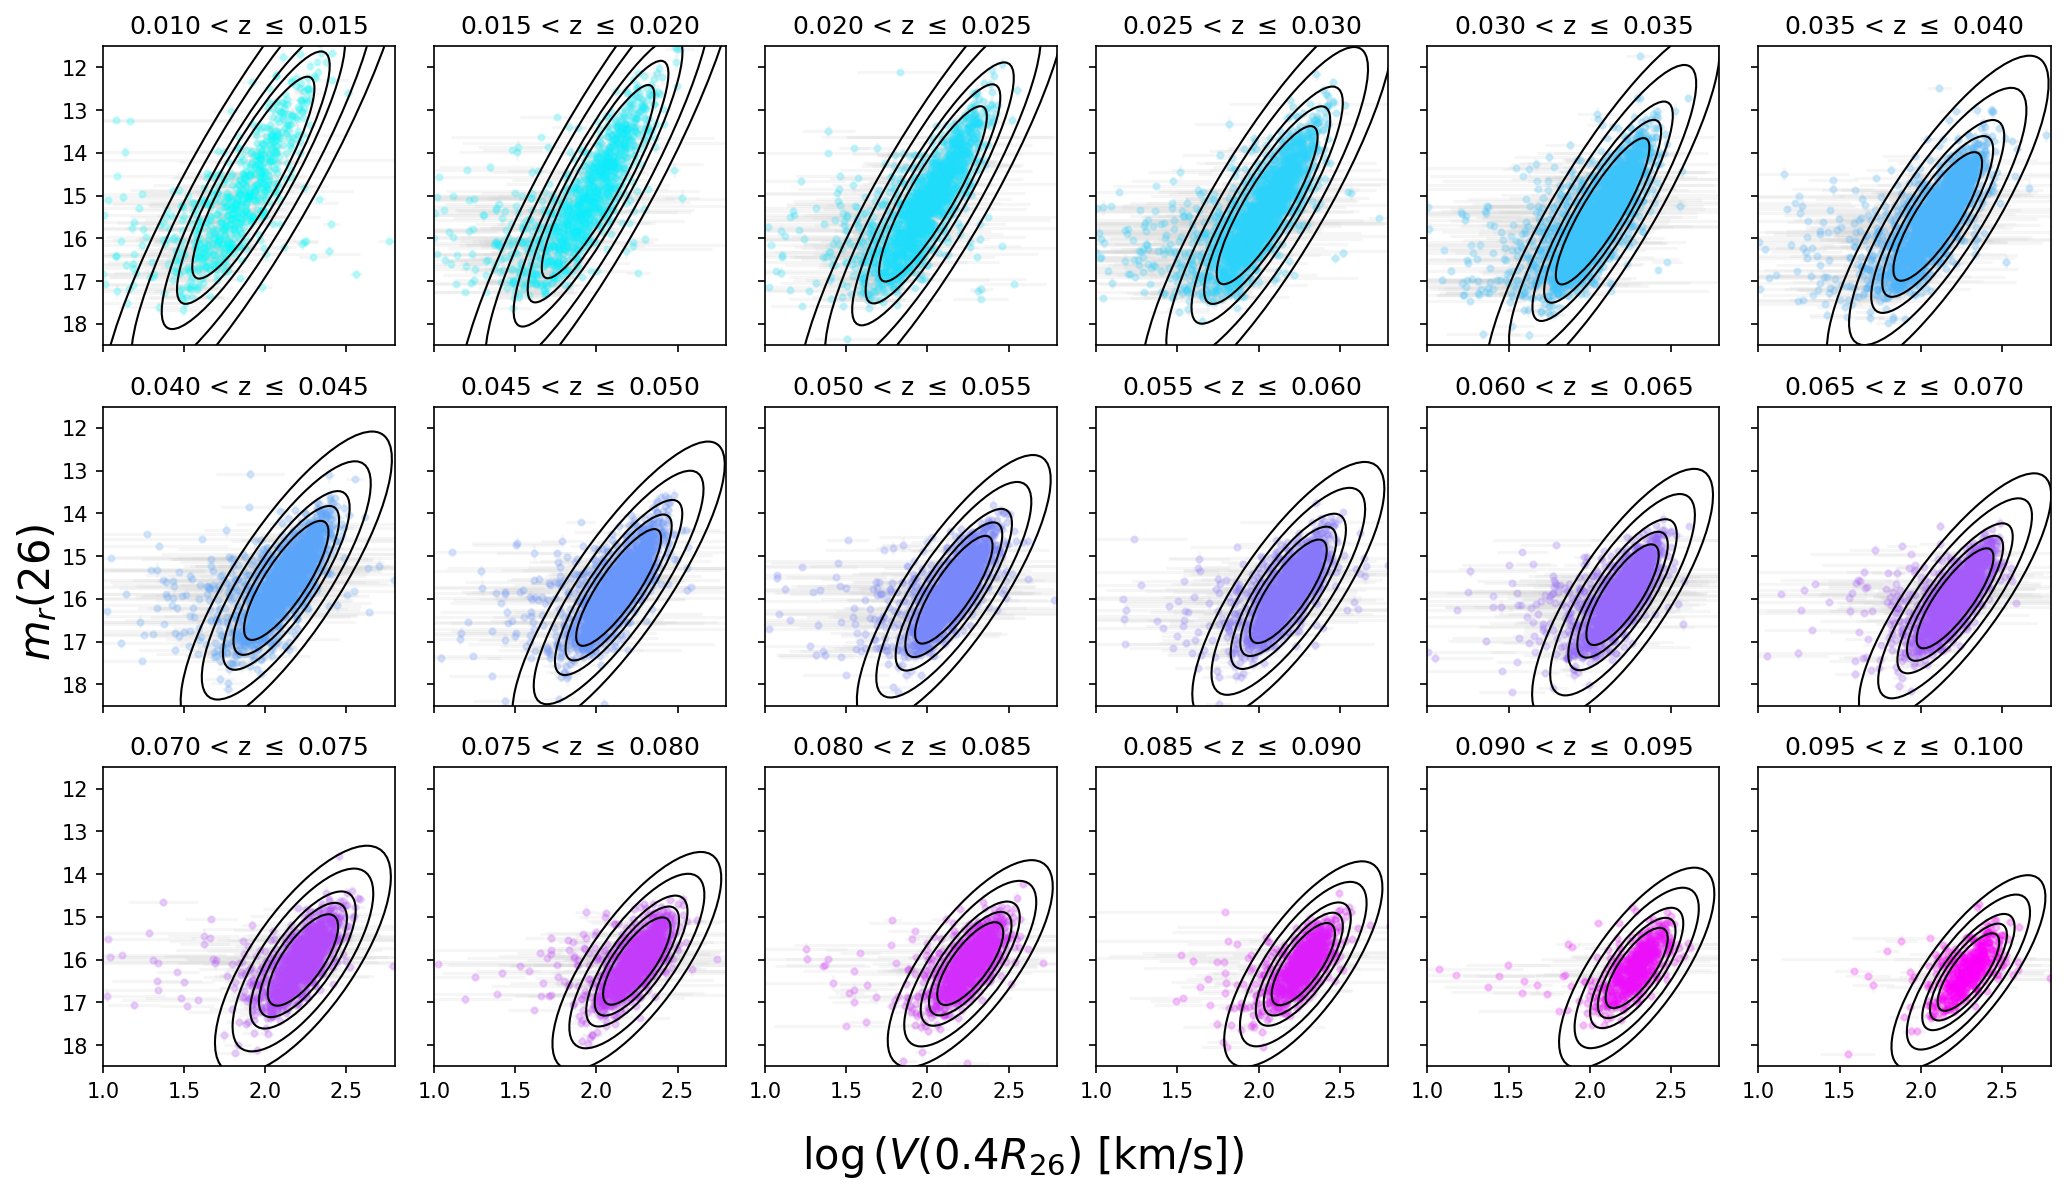

In [39]:
ncols=6
zbin_indices = np.digitize(sgatab['Z_DESI_CMB'], zbins, right=True)
fig, axs = plt.subplots(nrows=3, ncols=ncols, sharex=True, sharey=True, figsize=(14,8), tight_layout=True,
                        facecolor='none', dpi=150)
# fig, axs = plt.subplots(nrows=3, ncols=5, sharex=True, sharey=True, figsize=(10,8), tight_layout=True)
m = len(mu_x)
color = iter(plt.cm.cool(np.linspace(0,1,m)))
for i in range(m):
    c = next(color)
    
    row = int(i/ncols)
    col = i%ncols
    
    eb = axs[row,col].errorbar(sgatab['logV_SBcorr'][zbin_indices==i+1],#+1], 
                               sgatab['R_MAG_SB26_CORR'][zbin_indices==i+1],#+1], 
                               xerr=sgatab['logV_SBcorr_err'][zbin_indices==i+1],#+1], 
                               yerr=sgatab['R_MAG_SB26_ERR_CORR'][zbin_indices==i+1],#+1], 
                               fmt='.', color=c, ecolor='lightgray', alpha=0.2)
    # axs[row,col].plot(_logv + logV0, a_*_logv + b_[i], color=c)
    plot_ellipse(mean=(mu_x[i], mu_y[i]), cov = ([cov_xx[i], cov_xy[i]],[cov_yx[i], cov_yy[i]]),
                 n_std = 5, ax=axs[row,col], edgecolor='k', facecolor='none', zorder=6)
    plot_ellipse(mean=(mu_x[i], mu_y[i]), cov = ([cov_xx[i], cov_xy[i]],[cov_yx[i], cov_yy[i]]),
                 n_std = 2.5, ax=axs[row,col], edgecolor='k', facecolor='none', zorder=6)
    plot_ellipse(mean=(mu_x[i], mu_y[i]), cov = ([cov_xx[i], cov_xy[i]],[cov_yx[i], cov_yy[i]]),
                 n_std = 3, ax=axs[row,col], edgecolor='k', facecolor='none', zorder=6)
    plot_ellipse(mean=(mu_x[i], mu_y[i]), cov = ([cov_xx[i], cov_xy[i]],[cov_yx[i], cov_yy[i]]),
                 n_std = 4, ax=axs[row,col], edgecolor='k', facecolor='none', zorder=6)
    plot_ellipse(mean=(mu_x[i], mu_y[i]), cov = ([cov_xx[i], cov_xy[i]],[cov_yx[i], cov_yy[i]]),
                 n_std = 2, ax=axs[row,col], edgecolor='k', facecolor='none', zorder=6)

    
    # axs[row,col].set(xlim=[1.5, 2.6], ylim=[18, 13], title=f'{zbins[i]:.3f} < z $\leq$ {(zbins[i+1] if i+2 < len(zbins) else zmax):.3f}')
    axs[row,col].set(xlim=[1, 2.8], ylim=[18.5, 11.5], title=f'{zbins[i]:.3f} < z $\leq$ {(zbins[i+1] if i+2 < len(zbins) else zmax):.3f}')

# Delete extra axes
# fig.delaxes(axs[-1,-1])

fig.supxlabel(r'$\log{(V(0.4R_{26})~[\mathrm{km/s}]}$)', fontsize=20)
fig.supylabel(r'$m_r (26)$', fontsize=20);

# plt.savefig('/pscratch/sd/s/sgmoore1/TF/figures/v7_bin_ellipses_prefit.png', 
#             dpi=150, 
#             facecolor='none')


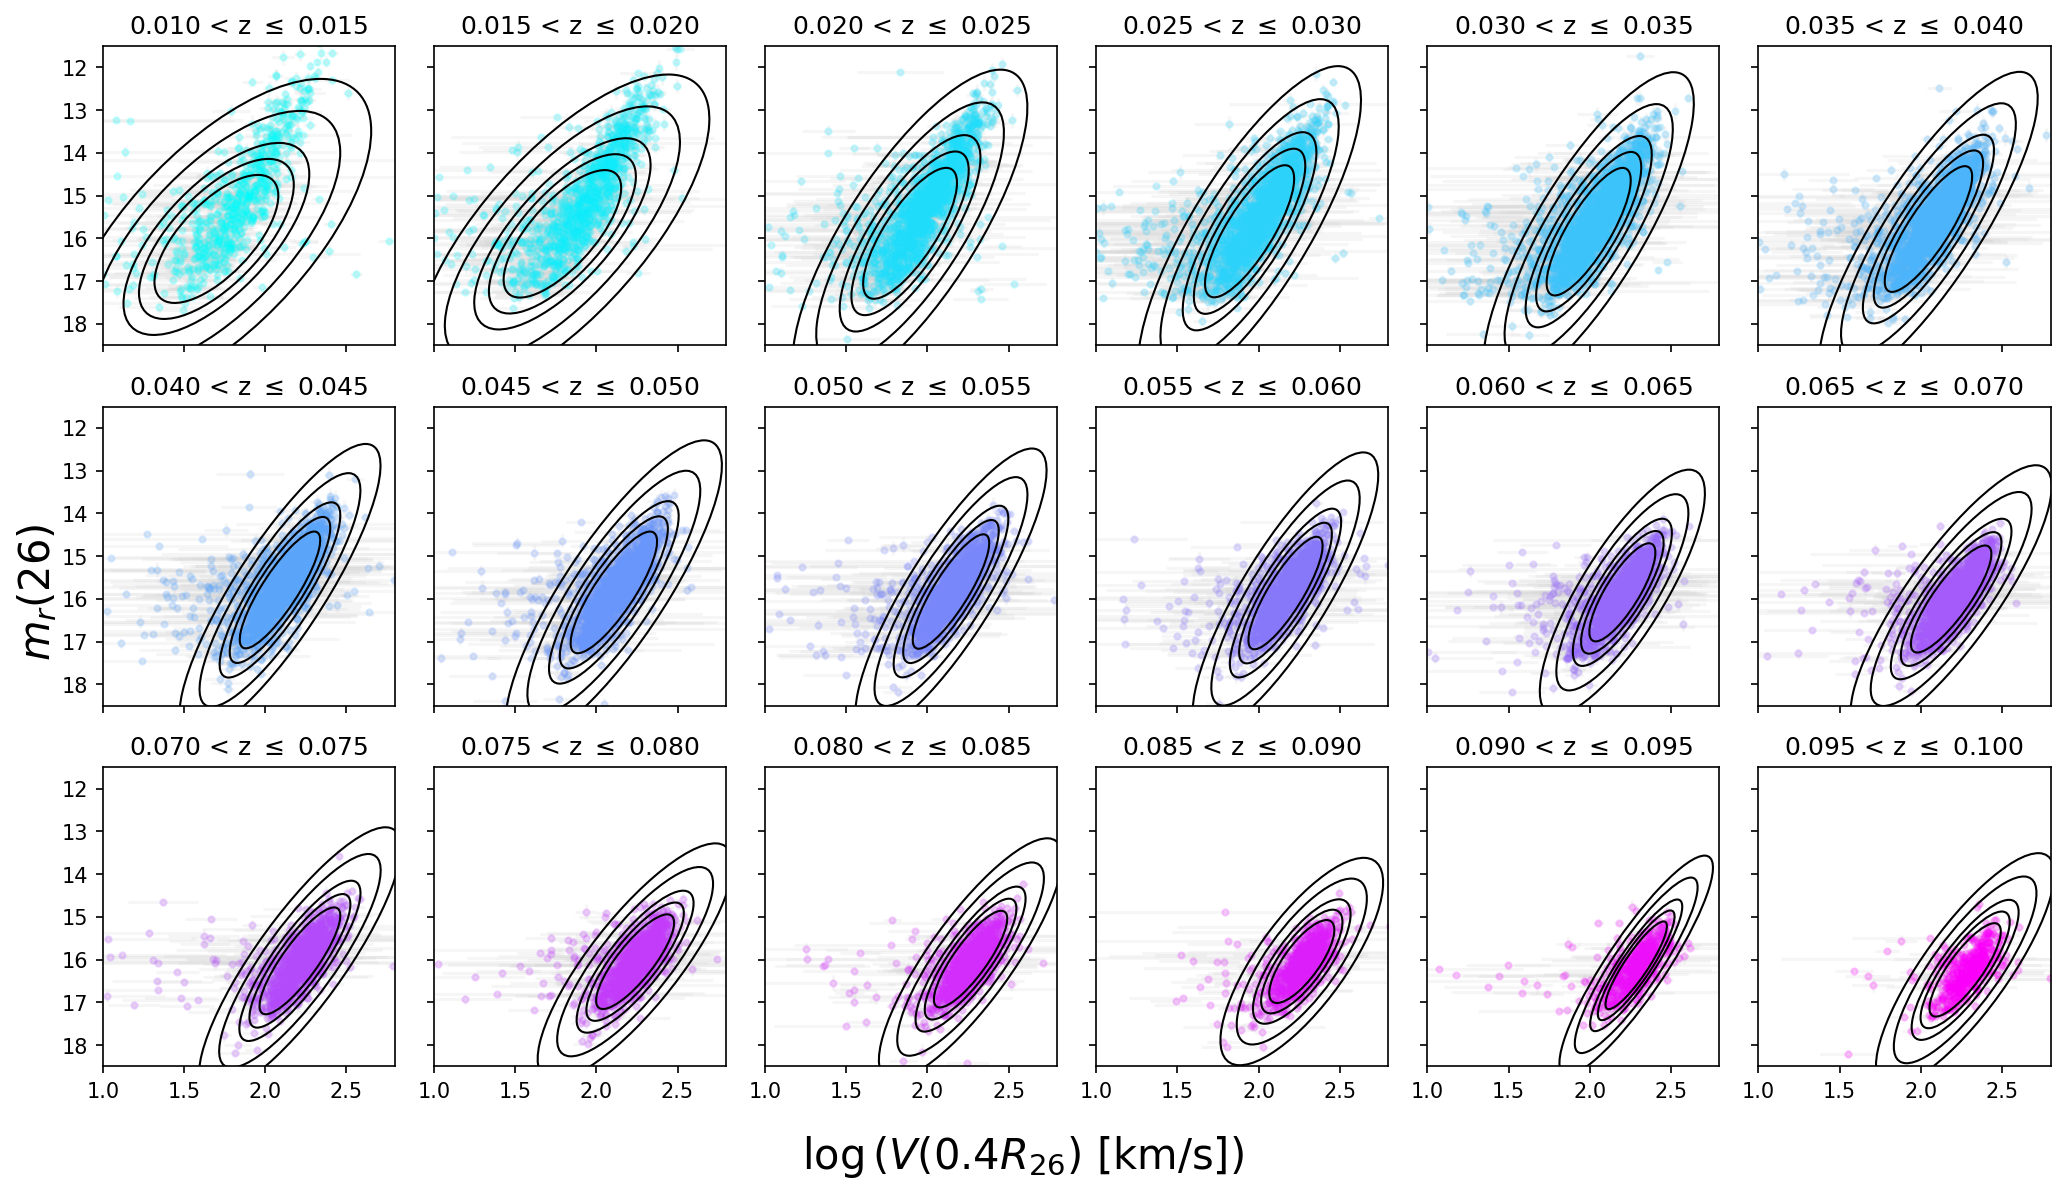

In [40]:
ncols=6
# zbin_indices = np.digitize(sgatab['Z_DESI_CMB'], zbins, right=True)
fig, axs = plt.subplots(nrows=3, ncols=ncols, sharex=True, sharey=True, figsize=(14,8), tight_layout=True,
                        facecolor='none', dpi=150)
# fig, axs = plt.subplots(nrows=3, ncols=5, sharex=True, sharey=True, figsize=(10,8), tight_layout=True)
m = len(mu_x)
color = iter(plt.cm.cool(np.linspace(0,1,m)))
for i in range(m):
    c = next(color)
    
    row = int(i/ncols)
    col = i%ncols
    
    eb = axs[row,col].errorbar(sgatab['logV_SBcorr'][zbin_indices==i+1],#+1], 
                               sgatab['R_MAG_SB26_CORR'][zbin_indices==i+1],#+1], 
                               xerr=sgatab['logV_SBcorr_err'][zbin_indices==i+1],#+1], 
                               yerr=sgatab['R_MAG_SB26_ERR_CORR'][zbin_indices==i+1],#+1], 
                               fmt='.', color=c, ecolor='lightgray', alpha=0.2)
    # axs[row,col].plot(_logv + logV0, a_*_logv + b_[i], color=c)
    plot_ellipse(mean=(mu_x_irr[i], mu_y_irr[i]), cov = ([cov_xx_irr[i], cov_xy_irr[i]],[cov_yx_irr[i], cov_yy_irr[i]]),
                 n_std = 5, ax=axs[row,col], edgecolor='k', facecolor='none', zorder=6)
    plot_ellipse(mean=(mu_x_irr[i], mu_y_irr[i]), cov = ([cov_xx_irr[i], cov_xy_irr[i]],[cov_yx_irr[i], cov_yy_irr[i]]),
                 n_std = 2.5, ax=axs[row,col], edgecolor='k', facecolor='none', zorder=6)
    plot_ellipse(mean=(mu_x_irr[i], mu_y_irr[i]), cov = ([cov_xx_irr[i], cov_xy_irr[i]],[cov_yx_irr[i], cov_yy_irr[i]]),
                 n_std = 3, ax=axs[row,col], edgecolor='k', facecolor='none', zorder=6)
    plot_ellipse(mean=(mu_x_irr[i], mu_y_irr[i]), cov = ([cov_xx_irr[i], cov_xy_irr[i]],[cov_yx_irr[i], cov_yy_irr[i]]),
                 n_std = 4, ax=axs[row,col], edgecolor='k', facecolor='none', zorder=6)
    plot_ellipse(mean=(mu_x_irr[i], mu_y_irr[i]), cov = ([cov_xx_irr[i], cov_xy_irr[i]],[cov_yx_irr[i], cov_yy_irr[i]]),
                 n_std = 2, ax=axs[row,col], edgecolor='k', facecolor='none', zorder=6)

    
    # axs[row,col].set(xlim=[1.5, 2.6], ylim=[18, 13], title=f'{zbins[i]:.3f} < z $\leq$ {(zbins[i+1] if i+2 < len(zbins) else zmax):.3f}')
    axs[row,col].set(xlim=[1, 2.8], ylim=[18.5, 11.5], title=f'{zbins[i]:.3f} < z $\leq$ {(zbins[i+1] if i+2 < len(zbins) else zmax):.3f}')

# Delete extra axes
# fig.delaxes(axs[-1,-1])

fig.supxlabel(r'$\log{(V(0.4R_{26})~[\mathrm{km/s}]}$)', fontsize=20)
fig.supylabel(r'$m_r (26)$', fontsize=20);

# plt.savefig('/pscratch/sd/s/sgmoore1/TF/figures/v7_bin_ellipses_prefit.png', 
#             dpi=150, 
#             facecolor='none')


In [41]:
# sigma=2.5

zmin=0.01
# zmin = 0.03
zmax = 0.1
dz = 0.005
zbins = np.arange(zmin, zmax+dz/2, dz)


 ###### Do a separate fit for just the irregulars
# sigma=2.5
sp_mask = (sgatab['MORPHTYPE'] == 'Spiral')
sgatab_sp = sgatab[sp_mask]

zbin_indices_sp = np.digitize(sgatab_sp['Z_DESI_CMB'], zbins, right=True)

# Create output array with the full length of sgatab
outlier_boolean = np.zeros(len(sgatab), dtype=bool)

# Indices of the irregular galaxies in the full table
sp_indices = np.where(sp_mask)[0]

## do the lowest and highest bins separately since they are in absmag space
bin_mask = (zbin_indices_sp == 0)
x = sgatab_sp['logV_SBcorr'][bin_mask]
y = sgatab_sp['R_ABSMAG_SB26'][bin_mask]
# outlier_bin_sp = ellipse_boolean(x, y, sigma, mean=(mu_x[0], (mu_y[0] - mu_zc[0].value)), cov = ([cov_xx[0], cov_xy[0]],[cov_yx[0], cov_yy[0]]))
outlier_bin_sp = ellipse_boolean(x, y, sigma)
outlier_boolean[sp_indices[bin_mask]] = outlier_bin_sp

for i in range(1, len(zbins)):
    bin_mask = (zbin_indices_sp == i)

    x = sgatab_sp['logV_SBcorr'][bin_mask]
    y = sgatab_sp['R_MAG_SB26_CORR'][bin_mask]

    # Outliers *within this bin*
    outlier_bin_sp = ellipse_boolean(x, y, sigma)

    # Write results back into global array
    outlier_boolean[sp_indices[bin_mask]] = outlier_bin_sp

bin_mask = (zbin_indices_sp == len(zbins))
x = sgatab_sp['logV_SBcorr'][bin_mask]
y = sgatab_sp['R_ABSMAG_SB26'][bin_mask]
outlier_bin_sp = ellipse_boolean(x, y, sigma)
outlier_boolean[sp_indices[bin_mask]] = outlier_bin_sp

print(np.sum(outlier_boolean), len(outlier_boolean), np.sum(outlier_boolean)/len(outlier_boolean))

2075 32488 0.06386973651809899


In [42]:
 ###### Do a separate fit for just the irregulars
# sigma=2.5
irr_mask = (sgatab['MORPHTYPE'] == 'Irregular')
sgatab_irr = sgatab[irr_mask]

zbin_indices_irr = np.digitize(sgatab_irr['Z_DESI_CMB'], zbins, right=True)

# Create output array with the full length of sgatab
outlier_boolean_irr = np.zeros(len(sgatab), dtype=bool)

# Indices of the irregular galaxies in the full table
irr_indices = np.where(irr_mask)[0]

## do the lowest and highest bins separately since they are in absmag space
bin_mask = (zbin_indices_irr == 0)
x = sgatab_irr['logV_SBcorr'][bin_mask]
y = sgatab_irr['R_ABSMAG_SB26'][bin_mask]
# outlier_bin_irr = ellipse_boolean(x, y, sigma, mean=(mu_x_irr[0], (mu_y_irr[0] - mu_zc[0].value)), cov = ([cov_xx_irr[0], cov_xy_irr[0]],[cov_yx_irr[0], cov_yy_irr[0]]))
outlier_bin_irr = ellipse_boolean(x, y, sigma)
outlier_boolean_irr[irr_indices[bin_mask]] = outlier_bin_irr

for i in range(1, len(zbins)):
    bin_mask = (zbin_indices_irr == i)

    x = sgatab_irr['logV_SBcorr'][bin_mask]
    y = sgatab_irr['R_MAG_SB26_CORR'][bin_mask]

    # Outliers *within this bin*
    outlier_bin_irr = ellipse_boolean(x, y, sigma)

    # Write results back into global array
    outlier_boolean_irr[irr_indices[bin_mask]] = outlier_bin_irr

bin_mask = (zbin_indices_irr == len(zbins))
x = sgatab_irr['logV_SBcorr'][bin_mask]
y = sgatab_irr['R_ABSMAG_SB26'][bin_mask]
outlier_bin_irr = ellipse_boolean(x, y, sigma)
outlier_boolean_irr[irr_indices[bin_mask]] = outlier_bin_irr

print(
    np.sum(outlier_boolean_irr),
    np.sum(irr_mask),
    np.sum(outlier_boolean_irr) / np.sum(irr_mask)
)

829 7100 0.11676056338028169


In [43]:
zmin=0.01
# zmin = 0.03
zmax = 0.1
dz = 0.005
zbins = np.arange(zmin, zmax+dz/2, dz)

zbin_indices = np.digitize(sgatab['Z_DESI_CMB'][~outlier_boolean], zbins, right=True)

binwidth=dz

for i in range(len(zbins) + 1):
    if i == 0:
        print(f'{i:2d}  z <= {zbins[i]:0.3f}  {np.sum(zbin_indices == i):3d} galaxies')
    elif i == len(zbins):
        print(f'{i:2d}  z > {zbins[i-1]:0.3f}  {np.sum(zbin_indices == i):3d} galaxies')
    else:
        print(f'{i:2d}  {zbins[i-1]:0.3f} < z <= {zbins[i]:0.3f}  {np.sum(zbin_indices == i):3d} galaxies')

 0  z <= 0.010  450 galaxies
 1  0.010 < z <= 0.015  639 galaxies
 2  0.015 < z <= 0.020  1041 galaxies
 3  0.020 < z <= 0.025  1602 galaxies
 4  0.025 < z <= 0.030  2115 galaxies
 5  0.030 < z <= 0.035  2521 galaxies
 6  0.035 < z <= 0.040  2271 galaxies
 7  0.040 < z <= 0.045  2179 galaxies
 8  0.045 < z <= 0.050  1881 galaxies
 9  0.050 < z <= 0.055  1862 galaxies
10  0.055 < z <= 0.060  1726 galaxies
11  0.060 < z <= 0.065  1760 galaxies
12  0.065 < z <= 0.070  1640 galaxies
13  0.070 < z <= 0.075  1367 galaxies
14  0.075 < z <= 0.080  1331 galaxies
15  0.080 < z <= 0.085  1260 galaxies
16  0.085 < z <= 0.090  934 galaxies
17  0.090 < z <= 0.095  659 galaxies
18  0.095 < z <= 0.100  518 galaxies
19  z > 0.100  2657 galaxies


## Apply other cuts

In [44]:
#- Inclination cut
cosi2 = (sgatab['BA']**2 - q0**2) / (1 - q0**2)
i_min = 45. * u.degree
cosi2_max = np.cos(i_min)**2
is_good_incl = cosi2 < cosi2_max

#- Morphology cut: only ML
is_good_morph_ML = np.zeros_like(is_good_incl, dtype=bool)
is_irregular_ML = np.zeros_like(is_good_incl, dtype=bool)
for i in range(len(sgatab)):
    if sgatab['MORPHTYPE'][i] == 'Spiral':
        is_good_morph_ML[i] = True
    elif sgatab['MORPHTYPE'][i] == 'Irregular':
        is_irregular_ML[i] = True

#- John's VI
is_good_John = sgatab['JOHN_VI'].mask

#- Combine selections:
is_good_sga = is_good_incl & is_good_morph_ML & is_good_John & ~outlier_boolean
is_good_sga_irregular = is_good_incl & is_irregular_ML & is_good_John & ~outlier_boolean_irr

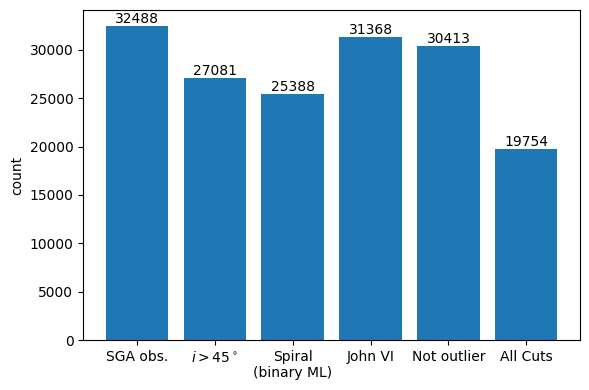

In [45]:
data = {
    'SGA obs.' : len(sgatab),
    # r'$10 < V_\mathrm{rot} < 1000$' : np.sum(is_good_velo),
    # r'$\Delta V/V_\mathrm{min}>5$' : np.sum(is_good_dv),
    r'$i > 45^\circ$' : np.sum(is_good_incl), 
    # 'Spiral' : np.sum(is_good_morph),
    'Spiral\n(binary ML)' : np.sum(is_good_morph_ML),
    'John VI' : np.sum(is_good_John), 
    # 'Not dwarf' : np.sum(~dwarf_boolean), 
    'Not outlier' : np.sum(~outlier_boolean), 
    'All Cuts' : np.sum(is_good_sga), 
    # 'All Cuts\n(binary ML)' : np.sum(is_good_sga_ML)
}
names = list(data.keys())
values = list(data.values())

fig, ax = plt.subplots(1, 1, figsize=(6,4), tight_layout=True)
bars = ax.bar(names, values, color='tab:blue')
ax.bar_label(bars, fmt='%d')
ax.set(ylabel='count');#, yscale='log', ylim=[1e3,1.2e4]);

# fig.savefig('../../Figures/Y1/TF_Y1_SGA_Vrot_cuts.png', dpi=150, facecolor='none');

In [46]:
spiral_boolean = sgatab['MORPHTYPE'] == 'Spiral'
irregular_boolean = sgatab['MORPHTYPE'] == 'Irregular'
# other_boolean = sgatab['MORPHTYPE'] == 'Other'

VI_boolean = sgatab['JOHN_VI'].mask

morph_boolean = (spiral_boolean | irregular_boolean) & VI_boolean

redshift_boolean = (sgatab['Z_DESI_CMB'] > 0.01) & (sgatab['Z_DESI_CMB'] < 0.10)

In [47]:
sgatab['GOOD_MORPH'] = morph_boolean

print(sum(outlier_boolean), 'outliers')
print(sum(~outlier_boolean), 'non-outliers')
print('-----------')
print(np.sum(morph_boolean), 'spirals & irregulars that pass VI')
print(np.sum(morph_boolean & outlier_boolean), 'outliers')
print(np.sum(morph_boolean & ~outlier_boolean), 'non-outliers')

2075 outliers
30413 non-outliers
-----------
31368 spirals & irregulars that pass VI
1878 outliers
29490 non-outliers


In [48]:
# # Create a single column to denote which objects should be used for cosmological analysis
# True if the object is not an outlier according to the appropriate fit
main_boolean = (
    (spiral_boolean & ~outlier_boolean) |
    (irregular_boolean & ~outlier_boolean_irr)
) & VI_boolean

sgatab['MAIN'] = main_boolean

In [49]:
### Denote which objects are used for either the spiral or irregular calibrations

sgatab['CAL'] = np.zeros(len(sgatab))
sgatab['CAL'][is_good_sga & redshift_boolean] = 1
sgatab['CAL'][is_good_sga_irregular & redshift_boolean] = 2

In [50]:
np.sum(sgatab['MAIN'])

28856

In [51]:
sgatab_sel = sgatab[is_good_sga]
irregular_sel = sgatab[is_good_sga_irregular]
zbin_indices = np.digitize(sgatab_sel['Z_DESI_CMB'], zbins, right=True)
zbin_indices_irr = np.digitize(irregular_sel['Z_DESI_CMB'], zbins, right=True)

In [52]:
for i in range(len(zbins) + 1):
    if i == 0:
        print(f'{i:2d}  z <= {zbins[i]:0.3f}  {np.sum(zbin_indices == i):3d} galaxies')
    elif i == len(zbins):
        print(f'{i:2d}  z > {zbins[i-1]:0.3f}  {np.sum(zbin_indices == i):3d} galaxies')
    else:
        print(f'{i:2d}  {zbins[i-1]:0.3f} < z <= {zbins[i]:0.3f}  {np.sum(zbin_indices == i):3d} galaxies')

 0  z <= 0.010  246 galaxies
 1  0.010 < z <= 0.015  367 galaxies
 2  0.015 < z <= 0.020  626 galaxies
 3  0.020 < z <= 0.025  934 galaxies
 4  0.025 < z <= 0.030  1256 galaxies
 5  0.030 < z <= 0.035  1514 galaxies
 6  0.035 < z <= 0.040  1335 galaxies
 7  0.040 < z <= 0.045  1310 galaxies
 8  0.045 < z <= 0.050  1158 galaxies
 9  0.050 < z <= 0.055  1178 galaxies
10  0.055 < z <= 0.060  1110 galaxies
11  0.060 < z <= 0.065  1159 galaxies
12  0.065 < z <= 0.070  1123 galaxies
13  0.070 < z <= 0.075  974 galaxies
14  0.075 < z <= 0.080  922 galaxies
15  0.080 < z <= 0.085  924 galaxies
16  0.085 < z <= 0.090  690 galaxies
17  0.090 < z <= 0.095  502 galaxies
18  0.095 < z <= 0.100  376 galaxies
19  z > 0.100  2050 galaxies


In [53]:
spiral_counts = np.array([np.sum(zbin_indices == i) for i in range(len(zbins) + 1)])
irr_counts     = np.array([np.sum(zbin_indices_irr == i) for i in range(len(zbins) + 1)])

# print table
print(f"{'bin':>3}  {'z-range':<25} {'spiral':>8} {'irregular':>10}")

for i in range(len(zbins) + 1):
    if i == 0:
        label = f"z <= {zbins[i]:.3f}"
    elif i == len(zbins):
        label = f"z > {zbins[i-1]:.3f}"
    else:
        label = f"{zbins[i-1]:.3f} < z <= {zbins[i]:.3f}"

    print(f"{i:3d}  {label:<25} {spiral_counts[i]:8d} {irr_counts[i]:10d}")

bin  z-range                     spiral  irregular
  0  z <= 0.010                     246        104
  1  0.010 < z <= 0.015             367        133
  2  0.015 < z <= 0.020             626        203
  3  0.020 < z <= 0.025             934        336
  4  0.025 < z <= 0.030            1256        405
  5  0.030 < z <= 0.035            1514        475
  6  0.035 < z <= 0.040            1335        456
  7  0.040 < z <= 0.045            1310        393
  8  0.045 < z <= 0.050            1158        358
  9  0.050 < z <= 0.055            1178        336
 10  0.055 < z <= 0.060            1110        300
 11  0.060 < z <= 0.065            1159        285
 12  0.065 < z <= 0.070            1123        249
 13  0.070 < z <= 0.075             974        182
 14  0.075 < z <= 0.080             922        174
 15  0.080 < z <= 0.085             924        149
 16  0.085 < z <= 0.090             690         97
 17  0.090 < z <= 0.095             502         65
 18  0.095 < z <= 0.100        

In [54]:
np.sum(spiral_counts), np.sum(irr_counts)

(19754, 5013)

In [55]:
_, counts = np.unique(zbin_indices, return_counts=True)

print(np.min(counts[1:-1]), np.max(counts[1:-1]))

367 1514


Text(0, 0.5, '$m_r$')

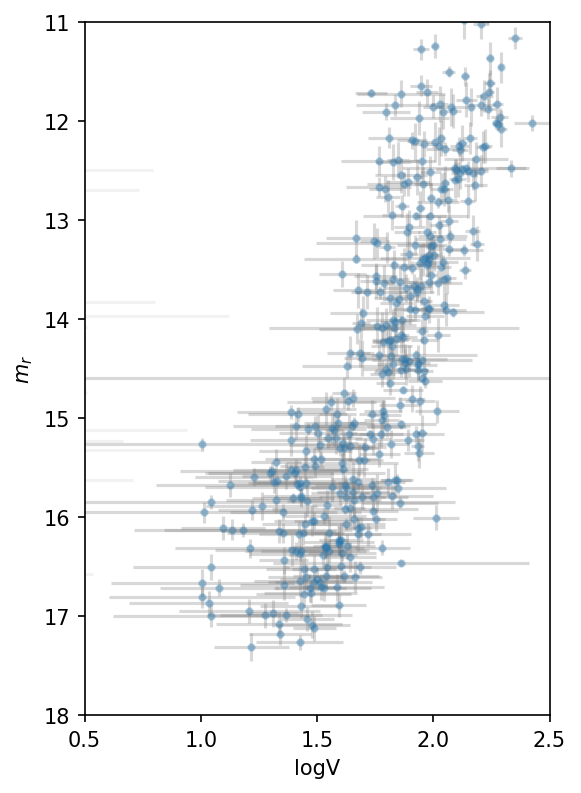

In [56]:
## Check if the lowest galaxies still are reasonably represented by an ellipse

low = sgatab['Z_DESI_CMB'] < 0.01
sample = (sgatab['MAIN'] & low)
sample_outlier = (~sgatab['MAIN'] & low)

plt.figure(figsize=(4,6), dpi=150, facecolor='none')
plt.errorbar(sgatab['logV_SBcorr'][sample], 
             sgatab['R_MAG_SB26_CORR'][sample], 
             xerr=sgatab['logV_SBcorr_err'][sample],
             yerr=sgatab['R_MAG_SB26_ERR_CORR'][sample], 
             fmt='.',
             color='tab:blue',
             alpha=0.3, 
             ecolor='gray')

plt.errorbar(np.log10(sgatab['logV_SBcorr'][sample_outlier]), 
             sgatab['R_MAG_SB26_CORR'][sample_outlier], 
             xerr=sgatab['logV_SBcorr_err'][sample_outlier],
             yerr=sgatab['R_MAG_SB26_ERR_CORR'][sample_outlier], 
             fmt='.',
             color='gray',
             alpha=0.1, 
             ecolor='gray')

plt.xlim(0.5,2.5)
plt.ylim(18,11)
plt.xlabel('logV')
plt.ylabel(r'$m_r$')

# Build the Calibration Table of SGA Galaxies

In [57]:
sgatab_sel['Z_BIN_IDX'] = zbin_indices

no_use = (zbin_indices == 0) | (zbin_indices == len(zbins))
caltab = sgatab_sel[~no_use]

rejtab = sgatab_sel[no_use]

# caltab.write('SGA-2020_iron_Vrot_cluster_calib_z0p1_Anthony2_dVsys.fits', overwrite=True)
caltab[['Z_BIN_IDX', 'Z_DESI_CMB', 'SGA_ID', 'R_MAG_SB26_CORR', 'R_MAG_SB26_ERR_CORR', 'V_0p4R26', 'V_0p4R26_ERR', 'logV_SBcorr', 'logV_SBcorr_err']]

Z_BIN_IDX,Z_DESI_CMB,SGA_ID,R_MAG_SB26_CORR,R_MAG_SB26_ERR_CORR,V_0p4R26,V_0p4R26_ERR,logV_SBcorr,logV_SBcorr_err
int64,float64,float64,float64,float64,float64,float64,float64,float64
18,0.09583935447193448,32.0,15.475734646579623,0.13234981016091993,242.31732801933134,18.2834008394214,2.387199814952756,0.03295926985314505
15,0.08162267561348635,38.0,16.943537400959432,0.13361490427350428,122.10002350181783,11.575073994874746,2.089558885184187,0.04141340080774459
18,0.09910672096429418,53.0,16.343658835513892,0.09388462142280865,237.8295282238147,19.144538438345666,2.379541032360435,0.03520011751754765
8,0.045082555650847844,55.0,17.150481296321377,0.10846211329218215,82.16642593696996,6.494247769763402,1.9138880666332518,0.03423874653893916
8,0.04576245512250576,63.0,16.379688388854266,0.16325676928664218,88.93146709845647,5.535181647491917,1.948469186144023,0.026976144512041254
6,0.039043626012540855,74.0,16.0340261644125,0.20054971863002308,92.43620953305918,10.018045188842146,1.9649419656619547,0.04693863163470957
10,0.055628906754008556,76.0,16.216555037330835,0.11055099423961041,131.82776915777,12.138195719213863,2.1203295457353946,0.03999075518816493
17,0.09120767170112742,117.0,16.15585258799605,0.13854330442033155,183.08805286733877,14.0547976285255,2.265192358420596,0.03351094481676575
7,0.04427201534577052,149.0,15.764151984307357,0.08336590469221816,166.06262670686112,17.77289747783132,2.219765776731953,0.046394867172323745


# Apply the Joint TFR Fit

In [58]:
#- Extract successful clusters
_zbin_ids = np.unique(caltab['Z_BIN_IDX'])
m = len(_zbin_ids)

#- Pack the results into arrays data and cov.
logV, logV_err = [], []
mag, mag_err = [], []
weights = []

logV0 = np.median(caltab['logV_SBcorr'])
print('logV0 =', logV0)

#- Loop over the redshift bins
for k, _zbin_id in enumerate(_zbin_ids):
    select_zbin = np.isin(caltab['Z_BIN_IDX'], _zbin_id)
    logV.append(caltab['logV_SBcorr'][select_zbin] - logV0)
    logV_err.append(caltab['logV_SBcorr_err'][select_zbin])
    mag.append(caltab['R_MAG_SB26_CORR'][select_zbin])
    mag_err.append(caltab['R_MAG_SB26_ERR_CORR'][select_zbin])
    # weights.append(np.array(1/caltab['MAX_VOL_FRAC'][select_zbin]))
    weights.append(np.array(1))

logV0 = 2.1667289487278083


## Multiline Fit using HyperFit

In [59]:
bounds = [[-20, 0]]                    # Bounds on a (slope)
bounds += m*[(-20, 20)]                # Bounds on b (intercepts: z-bins)
bounds += [(0,5)]                      # Bounds on sigma

results = hyperfit_line_multi(logV, mag, logV_err, mag_err, bounds, weights=weights, scatter=1)

a, b, sig_tfr, cov_tfr, tfr_mcmc_samples, hf_tfr = results

 message: Optimization terminated successfully.
 success: True
     fun: -38397.266203026746
       x: [-6.738e+00  1.299e+01 ...  1.716e+01  3.525e-01]
     nit: 247
    nfev: 74631
     jac: [-1.157e-01 -7.130e-02 ...  1.950e-01  3.936e-01]
Ndim: 20 18


100%|██████████| 1000/1000 [01:16<00:00, 13.03it/s]


Niterations/Max Iterations:  1000 / 100000
Integrated ACT/Min Convergence Iterations:  [76.00247918 75.58020422 82.8313519  81.07262232 85.06183362 83.56738043
 83.58938941 77.92762619 76.75608071 81.27167147 85.03223167 76.74398503
 81.55859727 75.32193734 77.54899824 79.5965374  79.16922986 82.39647206
 81.79409893 76.81199262] / 4253.091680875542


100%|██████████| 1000/1000 [01:14<00:00, 13.44it/s]


Niterations/Max Iterations:  2000 / 100000
Integrated ACT/Min Convergence Iterations:  [ 97.96775692  98.20763287 111.95042971 106.02552761 114.95866999
 103.14012359 109.48377871  96.16513262 102.42571684 109.05938956
 109.62449376 105.72041922 110.66802893 104.67024463 108.2596143
 101.82503859 109.91169723 109.18201336 113.99864063  95.20294699] / 5747.933499392371


...

Niterations/Max Iterations:  14000 / 100000
Integrated ACT/Min Convergence Iterations:  [231.10942907 212.535095   217.77235802 228.52837284 233.78913306
 242.16465939 239.63328549 206.29268872 206.26678081 240.18819761
 204.78792799 223.35093807 227.94816432 219.93989433 240.30936889
 210.01703166 215.2500847  228.0852786  230.11540024 204.64463432] / 12108.232969370176


100%|██████████| 1000/1000 [01:15<00:00, 13.16it/s]


Niterations/Max Iterations:  15000 / 100000
Integrated ACT/Min Convergence Iterations:  [236.16408934 223.96532579 227.18559336 235.00588656 239.79637321
 230.2894208  240.66184256 208.69244183 211.12810301 233.13112782
 209.56697594 225.7958425  236.57798923 228.44596303 240.88516822
 211.08921158 215.36464083 226.30146854 227.16196883 216.80725814] / 12044.258411106803


100%|██████████| 1000/1000 [01:16<00:00, 13.00it/s]


Niterations/Max Iterations:  16000 / 100000
Integrated ACT/Min Convergence Iterations:  [237.05993004 232.25042474 229.76635181 245.09052944 233.86729835
 238.86533354 238.63756471 216.72281786 213.69518074 230.7253997
 213.71372847 227.99685025 231.14610238 218.78897679 245.1790979
 211.60997539 218.59419303 232.67270485 227.41416554 222.49767341] / 12258.954895073166


In [60]:
# temp_outfile = open('/pscratch/sd/s/sgmoore1/TF/pickles/Y3/cov_ab_loa_jointTFR_ellipse_v5a_spirals.pickle', 
#                     'wb')
# pickle.dump((cov_tfr, tfr_mcmc_samples, logV0, zmin, zmax, dz, zbins), temp_outfile)
# temp_outfile.close()

In [76]:
# with open('/pscratch/sd/s/sgmoore1/TF/pickles/Y3/cov_ab_loa_jointTFR_ellipse_v3.pickle', 'rb') as f:
#     cov_tfr_saved, tfr_mcmc_samples_saved, logV0_saved, zmin_saved, zmax_saved, dz_saved, zbins_saved = pickle.load(f)

In [60]:
# with open('/pscratch/sd/s/sgmoore1/TF/pickles/Y3/cov_ab_loa_jointTFR_ellipse_v5a_spirals.pickle', 'rb') as f:
#     cov_tfr, tfr_mcmc_samples, logV0, zmin, zmax, dz, zbins = pickle.load(f)

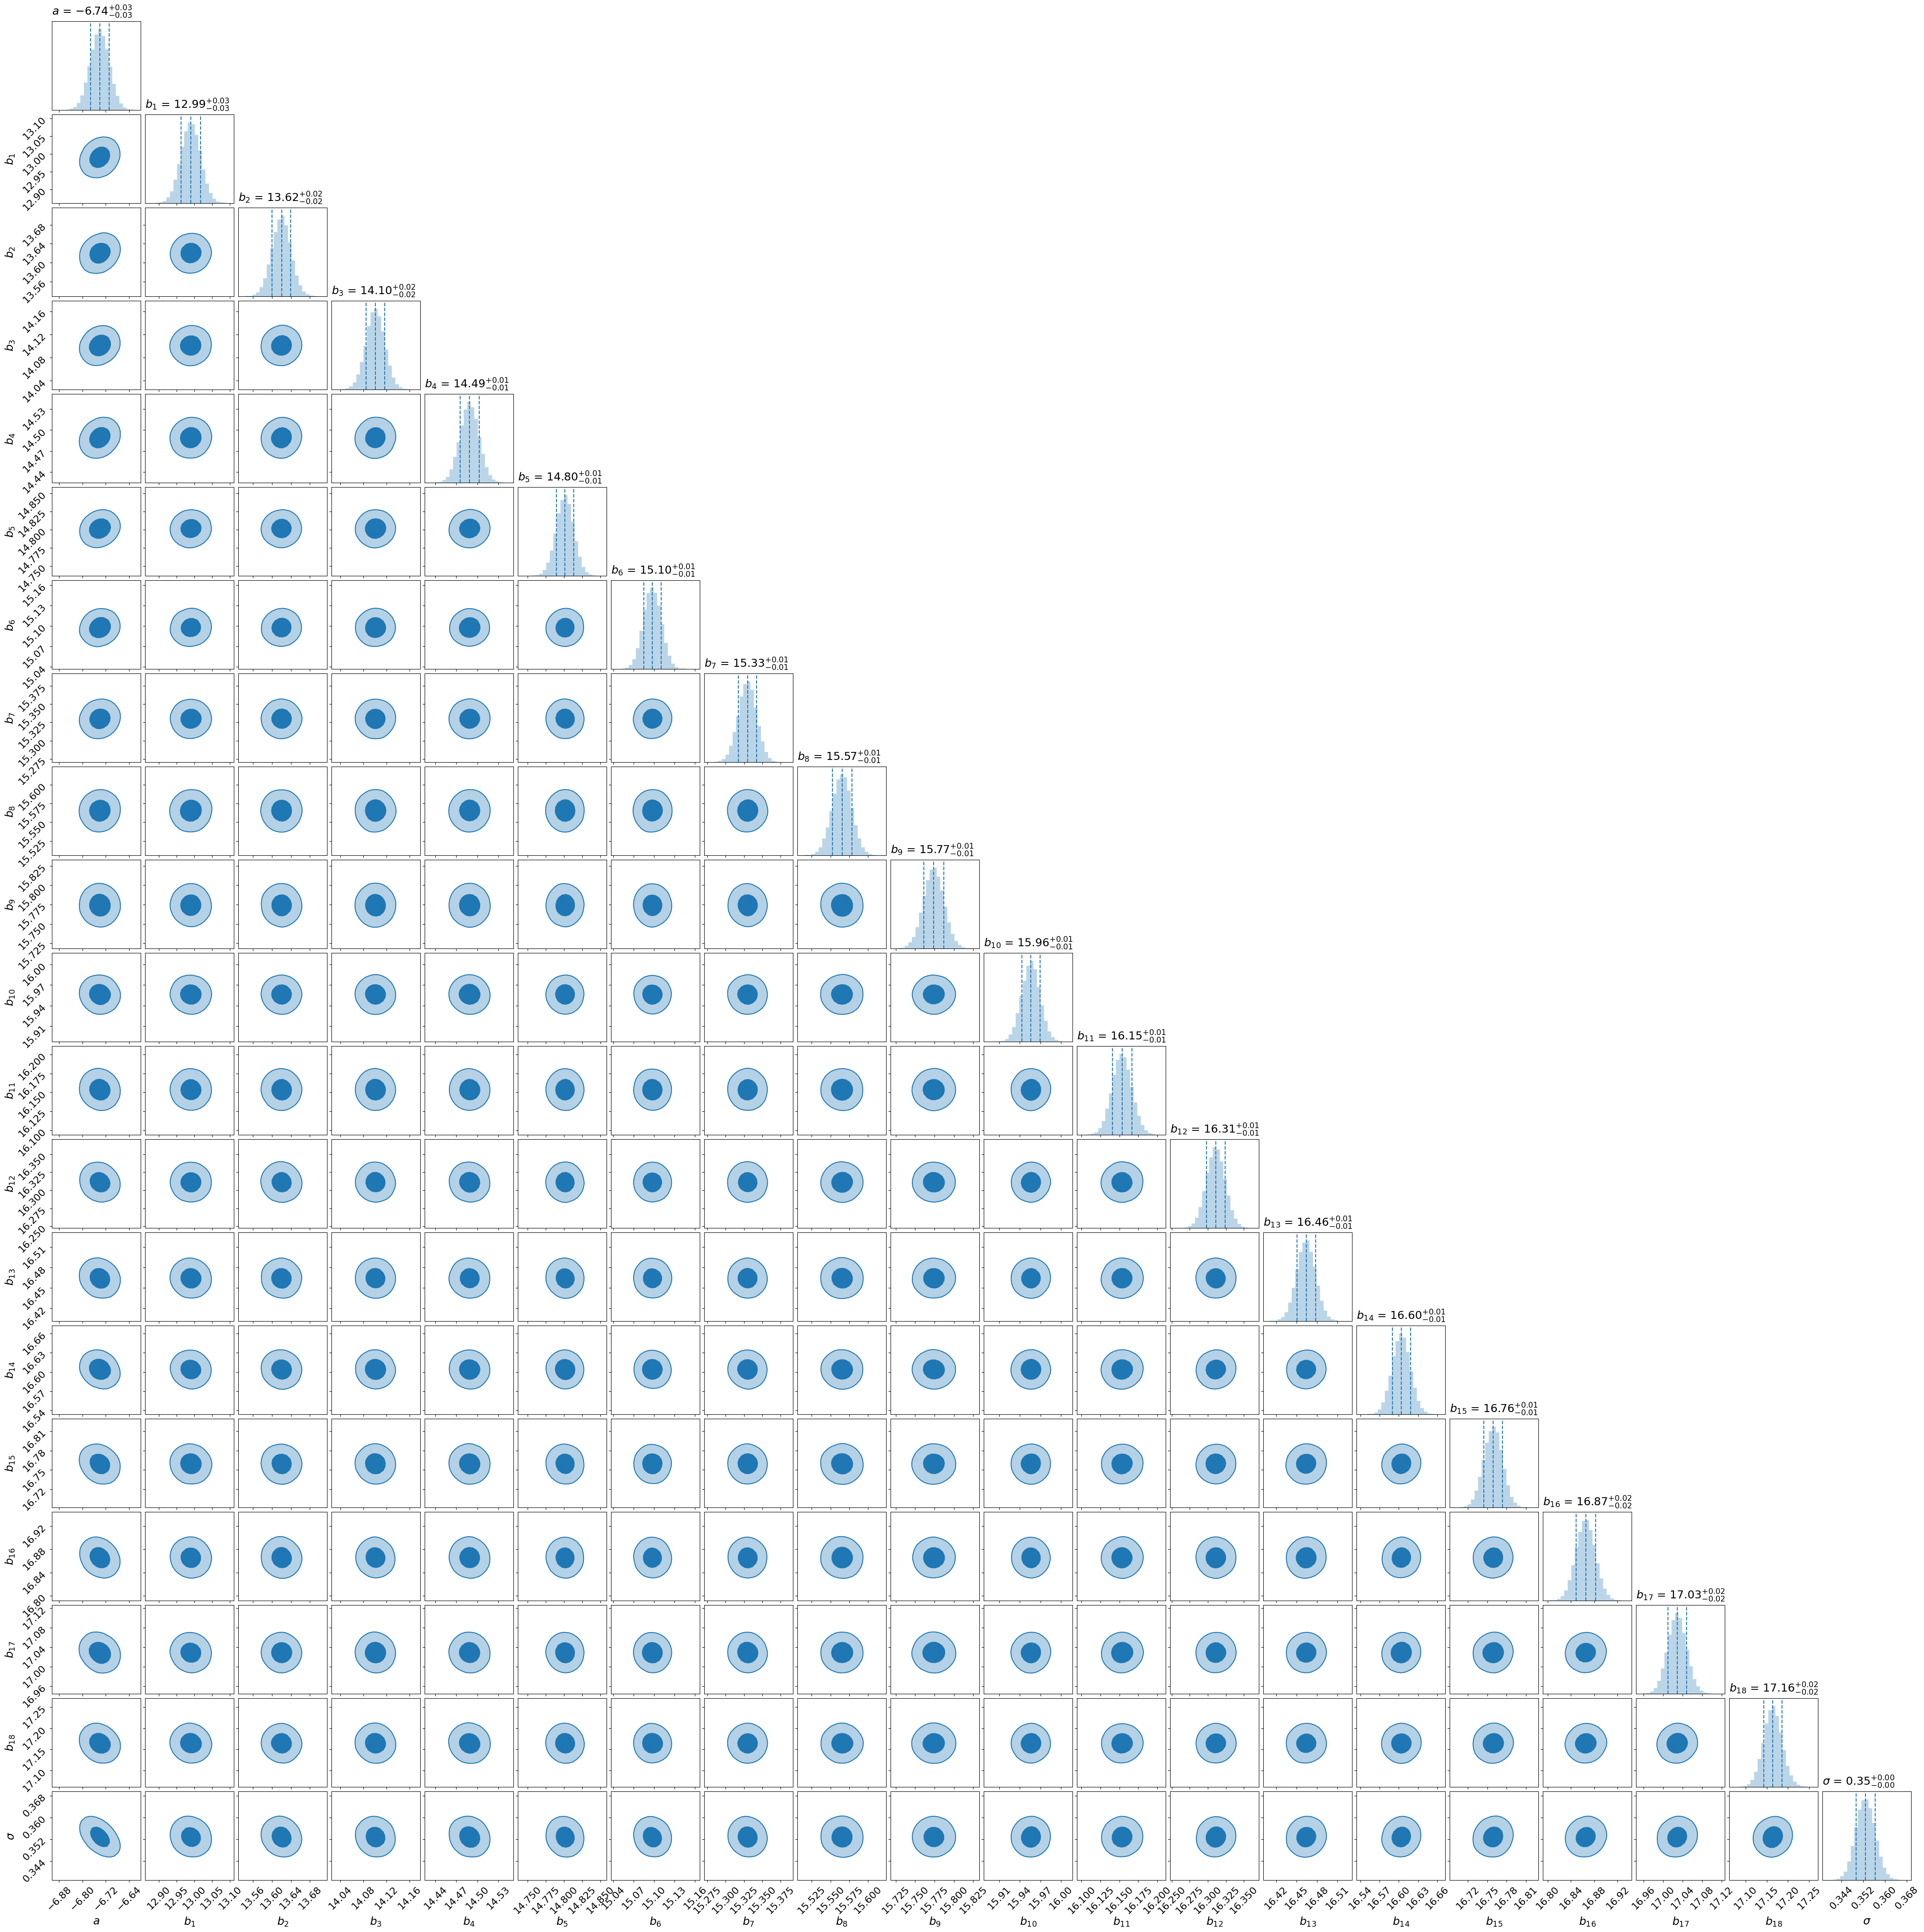

In [61]:
labels  = ['$a$']
labels += [f'$b_{{ {k+1} }}$' for k in np.arange(m)]
labels += [r'$\sigma$'] #+ [rf'$\sigma_{k}$' for k in np.arange(m)]

fig = corner(tfr_mcmc_samples.T, bins=25, smooth=1,
#              range=[[1.9, 2.4], [0.75, 1.1], [0.1, 0.3]],   # Range for a, b, sigma. Adjust as needed.
             labels=labels,
             label_kwargs={'fontsize':18},
             labelpad=0.1,
             levels=(1-np.exp(-0.5), 1-np.exp(-2)),
             quantiles=[0.16, 0.5, 0.84],
             color='tab:blue',
             hist_kwargs={'histtype':'stepfilled', 'alpha':0.3},
             plot_datapoints=False,
             fill_contours=True,
             show_titles=True,
             title_kwargs={"fontsize": 18, 'loc':'left', 'pad':10});

for ax in fig.get_axes():
    ax.tick_params(axis='both', which='major', labelsize=16)

# fig.savefig('/pscratch/sd/s/sgmoore1/TF/figures/DR2_cornerplot_v3.png',
#     dpi=150,
#     bbox_inches='tight',
#     pad_inches=0.2,
#     facecolor='none'
# )

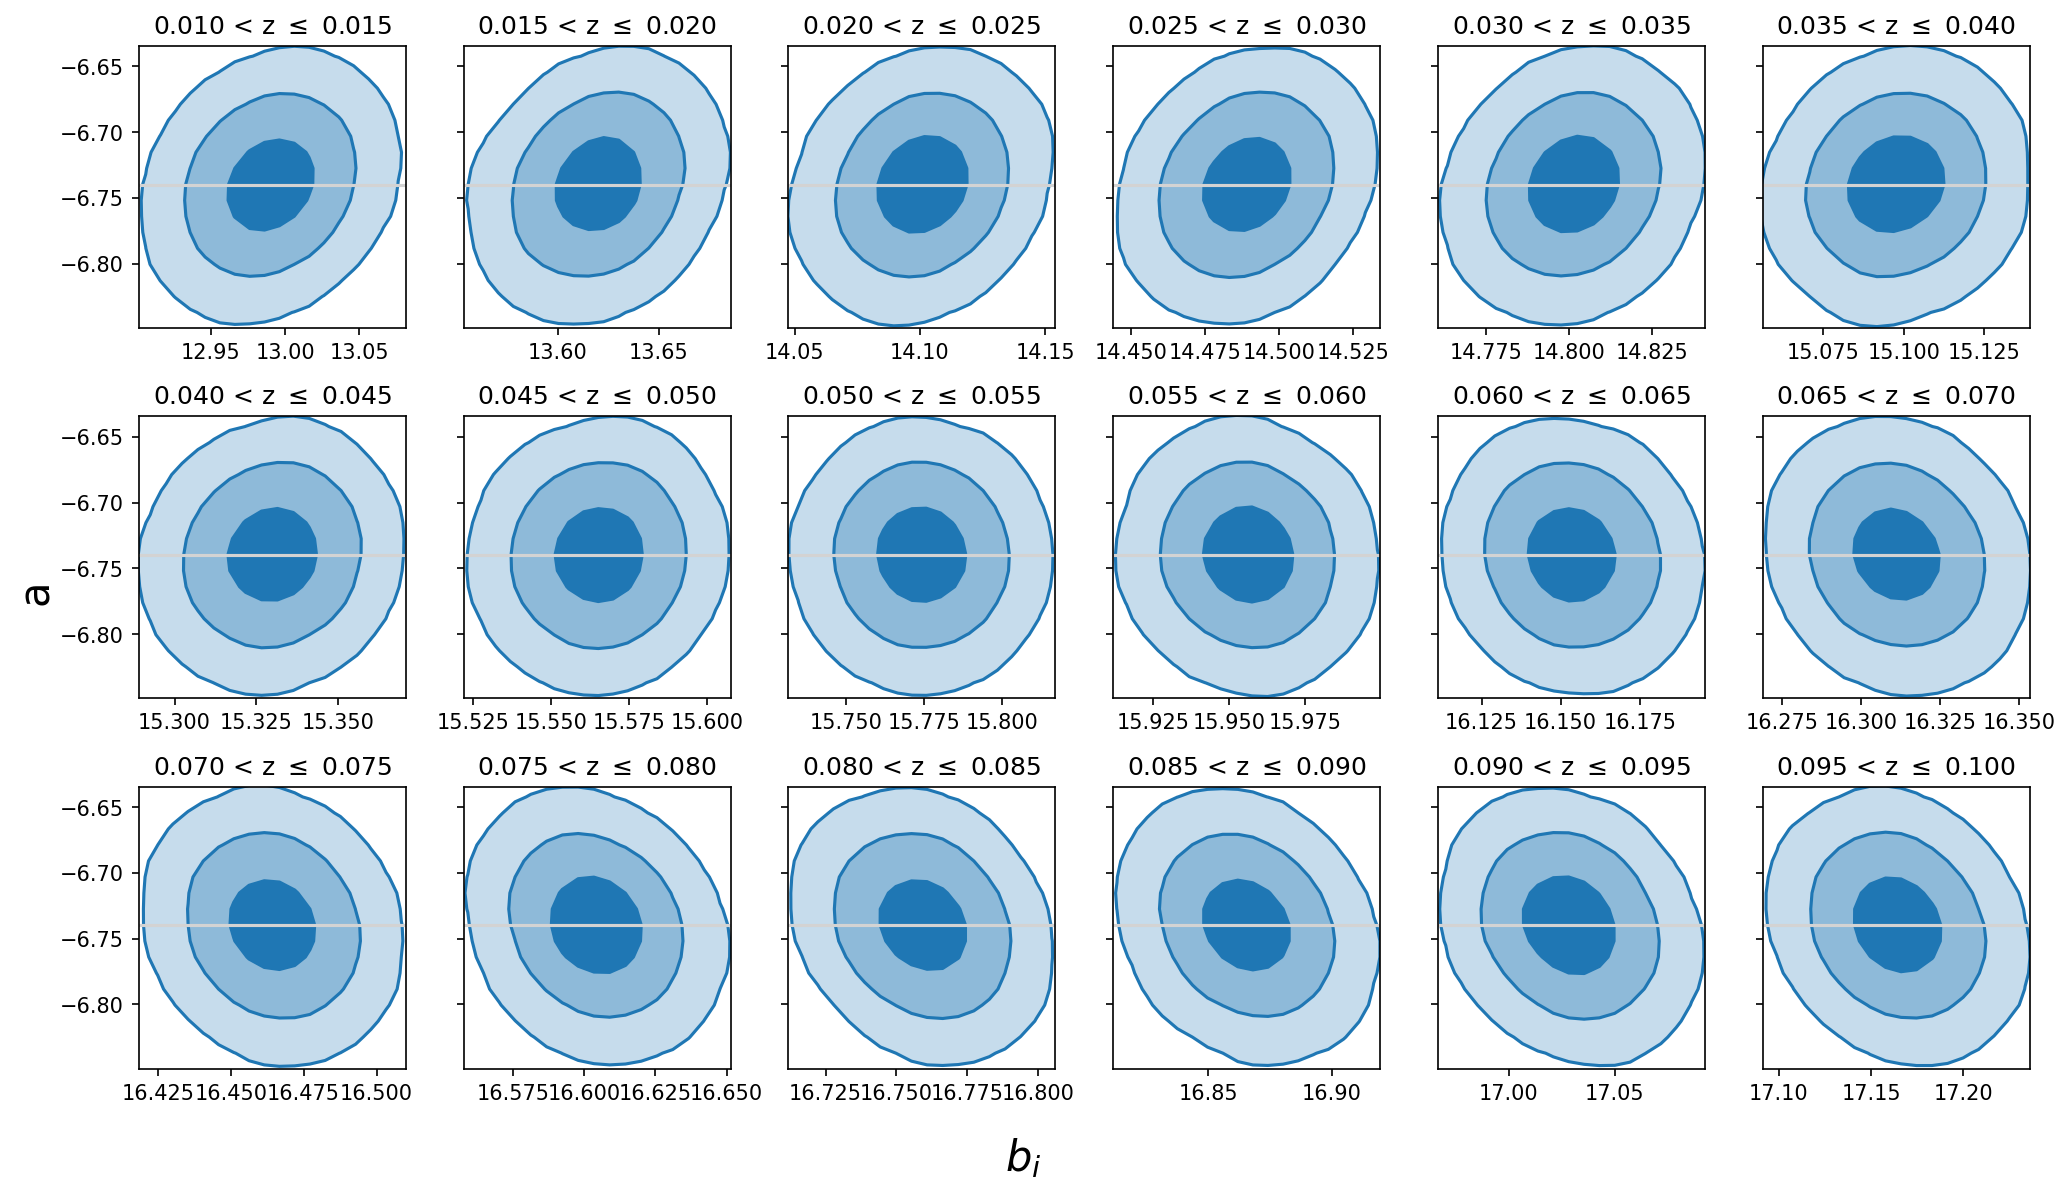

In [62]:
samples = tfr_mcmc_samples.T
a = samples[:, 0]
b_vals = samples[:, 1:-1]
n_b = b_vals.shape[1]
ncols = 6
nrows = 3
fig, axs = plt.subplots(nrows=3, ncols=ncols, sharex=False, sharey=True, figsize=(14,8), tight_layout=True,
                        facecolor='none', dpi=150)

axs = np.array(axs).reshape(-1)

for i in range(n_b):
    ax = axs[i]

    hist2d(
        b_vals[:, i],
        a,
        ax=ax,
        bins=25,
        smooth=1,
        levels=(1-np.exp(-0.5), 1-np.exp(-2), 1-np.exp(-4.5)),
        plot_datapoints=False,
        fill_contours=True,
        color='tab:blue'
    )
    ax.axhline(np.median(a), color='lightgray')

    ax.set(
        xlim = np.percentile(b_vals[:, i], [0.05,99.95]),
        ylim = np.percentile(a, [0.05,99.95]),
        title=f'{zbins[i]:.3f} < z $\\leq$ {(zbins[i+1] if i+2 < len(zbins) else zmax):.3f}'
    )

    # if i % ncols == 0:
    #     ax.set_ylabel(f'$b_{{{i+1}}}$', fontsize=14)
    # if i >= (nrows-1)*ncols:
    #     ax.set_xlabel('$a$', fontsize=14)


# turn off unused axes
for j in range(n_b, len(axs)):
    axs[j].axis('off')

fig.supxlabel(r'$b_i$', fontsize=20)
fig.supylabel('a', fontsize=20)

plt.tight_layout()
# plt.show()

# plt.savefig('/pscratch/sd/s/sgmoore1/TF/figures/Y3_v2_fit_contours.png', 
#             dpi=150, 
#             facecolor='none')


# Redo a separate calibration for the irregular galaxies

In [63]:
irregular_sel['Z_BIN_IDX'] = zbin_indices_irr

no_use = (zbin_indices_irr == 0) | (zbin_indices_irr == len(zbins))
caltab_irr = irregular_sel[~no_use]

rejtab_irr = irregular_sel[no_use]

# caltab.write('SGA-2020_iron_Vrot_cluster_calib_z0p1_Anthony2_dVsys.fits', overwrite=True)
caltab_irr[['Z_BIN_IDX', 'Z_DESI_CMB', 'SGA_ID', 'R_MAG_SB26_CORR', 'R_MAG_SB26_ERR_CORR', 'V_0p4R26', 'V_0p4R26_ERR', 
           'logV_SBcorr', 'logV_SBcorr_err']]

Z_BIN_IDX,Z_DESI_CMB,SGA_ID,R_MAG_SB26_CORR,R_MAG_SB26_ERR_CORR,V_0p4R26,V_0p4R26_ERR,logV_SBcorr,logV_SBcorr_err
int64,float64,float64,float64,float64,float64,float64,float64,float64
15,0.08340546654922387,20.0,16.89124365331456,0.09781881819206538,136.40320332954073,15.11967274982784,2.13816280609696,0.04847812207297467
5,0.03484676402082054,223.0,16.845516417807342,0.12040381932544775,75.85573954283541,7.2920942505668345,1.87782782667827,0.04151384274726358
7,0.04072728886203336,469.0,16.384041922092436,0.10514172039404823,81.51902216355329,10.003176670077446,1.9106120619607132,0.053176752004197664
10,0.058732115549104735,485.0,15.948094092084467,0.11510593098581842,147.66740237979482,13.458186595873844,2.1700176802121014,0.03962093176642538
12,0.06541748809592773,562.0,16.21389047655128,0.08986711771044842,151.3136400936256,11.615730059589167,2.1812544731196213,0.03342216318534447
10,0.058950704938611986,821.0,16.095370400967077,0.12719926098488096,146.90647343041115,5.992029405047928,2.167482416313449,0.017720020296232868
11,0.06448083836725993,822.0,15.638560146726668,0.13282299145452744,158.02076283439692,11.672594769217563,2.199419346063014,0.032110581930222065
14,0.07984167010675791,1135.0,15.791156138591468,0.10741708239943791,230.52940702744863,4.989973914356667,2.3641031589528354,0.009424069872378565
14,0.079203716939793,1384.0,15.770870424578899,0.10506782736649331,215.98639665884767,15.381609885886375,2.3364441313648734,0.031051519352797898


In [64]:
#- Extract successful clusters
_zbin_ids = np.unique(caltab_irr['Z_BIN_IDX'])
m_irr = len(_zbin_ids)

#- Pack the results into arrays data and cov.
logV_irr, logV_irr_err = [], []
mag_irr, mag_irr_err = [], []
weights_irr= []

logV0_irr = np.median(caltab_irr['logV_SBcorr'])
print('logV0 =', logV0_irr)

#- Loop over the redshift bins
for k, _zbin_id in enumerate(_zbin_ids):
    select_zbin_irr = np.isin(caltab_irr['Z_BIN_IDX'], _zbin_id)
    logV_irr.append(caltab_irr['logV_SBcorr'][select_zbin_irr] - logV0_irr)
    logV_irr_err.append(caltab_irr['logV_SBcorr_err'][select_zbin_irr])
    mag_irr.append(caltab_irr['R_MAG_SB26_CORR'][select_zbin_irr])
    mag_irr_err.append(caltab_irr['R_MAG_SB26_ERR_CORR'][select_zbin_irr])
    # weights_irr.append(np.array(1/caltab_irr['MAX_VOL_FRAC'][select_zbin_irr]))
    weights_irr.append(np.array(1))

logV0 = 2.0947517790238765


In [65]:
bounds = [[-20, 0]]                    # Bounds on a (slope)
bounds += m*[(-20, 20)]                # Bounds on b (intercepts: z-bins)
bounds += [(0,5)]                      # Bounds on sigma

results_irr = hyperfit_line_multi(logV_irr, mag_irr, logV_irr_err, mag_irr_err, bounds, weights=weights_irr, scatter=1)

a_irr, b_irr, sig_tfr_irr, cov_tfr_irr, tfr_mcmc_samples_irr, hf_tfr_irr = results_irr

 message: Optimization terminated successfully.
 success: True
     fun: -10271.166709582176
       x: [-6.483e+00  1.365e+01 ...  1.745e+01  3.079e-01]
     nit: 228
    nfev: 69015
     jac: [-3.802e-02 -9.586e-02 ...  3.201e-02  6.858e-02]
Ndim: 20 18


100%|██████████| 1000/1000 [01:02<00:00, 15.97it/s]


Niterations/Max Iterations:  1000 / 100000
Integrated ACT/Min Convergence Iterations:  [80.1386342  82.72366204 73.35670015 83.70197549 77.28735737 81.22796403
 77.32275292 81.30123847 80.3345883  76.22470692 74.37899274 83.31054095
 85.00225725 85.94657727 77.34524118 80.73809397 80.59080738 75.57155354
 80.93581721 79.01503981] / 4297.32886331743


100%|██████████| 1000/1000 [01:01<00:00, 16.14it/s]


Niterations/Max Iterations:  2000 / 100000
Integrated ACT/Min Convergence Iterations:  [104.78912557 105.4795853  105.87782485 104.0076306  105.96089894
  96.92505841 104.1403219   96.49168354 103.51208166 103.0482063
 113.98919226 109.17274124 102.70583816 106.41513762 108.95808325
 105.17767859 102.7636192  111.46872646 104.59164683 109.19523001] / 5699.459612845363


...

Niterations/Max Iterations:  13000 / 100000
Integrated ACT/Min Convergence Iterations:  [222.08170794 229.30074477 221.70297593 224.85003406 206.52059524
 219.54516602 234.9956733  228.88677638 208.17485575 232.59182239
 213.93680818 223.03220543 219.16486051 215.38787105 215.75123152
 212.73459583 204.31171303 210.13675572 207.48659716 222.76506129] / 11749.78366516552


100%|██████████| 1000/1000 [01:03<00:00, 15.82it/s]


Niterations/Max Iterations:  14000 / 100000
Integrated ACT/Min Convergence Iterations:  [221.07967717 223.67301522 228.51273739 224.38000213 209.25753518
 217.23215647 244.78844447 233.91049747 222.56016461 231.34628229
 221.21129124 220.18451736 231.85143813 209.33665326 219.90778019
 212.99785402 211.11340645 213.70134962 203.71372724 225.36073605] / 12239.422223338477


100%|██████████| 1000/1000 [01:05<00:00, 15.38it/s]


Niterations/Max Iterations:  15000 / 100000
Integrated ACT/Min Convergence Iterations:  [216.95418476 225.96101857 231.68176251 228.63122813 217.83187001
 213.512158   246.19641697 236.97137871 224.11645592 234.99642613
 228.20688022 223.7812242  229.03906745 208.57738664 216.76485909
 210.41514151 221.09180458 216.5101227  209.01700267 221.20139786] / 12309.82084847799


In [66]:
# temp_outfile = open('/pscratch/sd/s/sgmoore1/TF/pickles/Y3/cov_ab_loa_jointTFR_ellipse_v5a_irregulars_unweighted.pickle', 
#                     'wb')
# pickle.dump((cov_tfr_irr, tfr_mcmc_samples_irr, logV0_irr, zmin, zmax, dz, zbins), temp_outfile)
# temp_outfile.close()

In [67]:
# with open('/pscratch/sd/s/sgmoore1/TF/pickles/Y3/cov_ab_loa_jointTFR_ellipse_v5a_irregulars_unweighted.pickle', 'rb') as f:
#     cov_tfr_irr, tfr_mcmc_samples_irr, logV0_irr, zmin, zmax, dz, zbins = pickle.load(f)

In [ ]:
labels  = ['$a$']
labels += [f'$b_{{ {k+1} }}$' for k in np.arange(m)]
labels += [r'$\sigma$']

values = np.median(tfr_mcmc_samples, axis=1)
sigmas = np.sqrt(np.diag(cov_tfr))

values_irr = np.median(tfr_mcmc_samples_irr, axis=1)
sigmas_irr = np.sqrt(np.diag(cov_tfr_irr))

multiple = 1

# limits = []

# for i in range(len(values)):
#     # if i != len(values) - 2: # Need to skip the last z-bin
#     limits.append([values_old[i] - multiple*sigmas_old[i], 
#                    values_old[i] + multiple*sigmas_old[i]])

fig = plt.figure(figsize=(50,50))

corner(tfr_mcmc_samples.T,#[mask].T, 
       bins=25, smooth=1, 
       # range=limits, 
       labels=labels,
       label_kwargs={'fontsize':18},
       levels=(1-np.exp(-0.5), 1-np.exp(-2)),
       quantiles=[0.16, 0.5, 0.84],
       color='tab:blue',
       hist_kwargs={'histtype':'stepfilled', 'alpha':0.3},
       plot_datapoints=False,
       fill_contours=True,
       show_titles=False,
       title_fmt='.2f', 
       title_kwargs={"fontsize": 18, 'loc':'left', 'pad':10}, 
       fig=fig
       );

corner(tfr_mcmc_samples_irr.T,#[mask].T, 
       bins=25, smooth=1, 
       # range=limits, 
       labels=labels,
       label_kwargs={'fontsize':18},
       levels=(1-np.exp(-0.5), 1-np.exp(-2)),
       quantiles=[0.16, 0.5, 0.84],
       color='tab:orange',
       hist_kwargs={'histtype':'stepfilled', 'alpha':0.3},
       plot_datapoints=False,
       fill_contours=True,
       show_titles=False,
       title_fmt='.2f', 
       title_kwargs={"fontsize": 18, 'loc':'left', 'pad':10}, 
       fig=fig
       );

# Add a table of the best-fit parameters to the upper right corner
ax_table = fig.add_axes([0.55, 0.65, 0.35, 0.25])
ax_table.axis('off')

table_text = []

for i in range(len(labels)):
    table_text.append([
        f'{values[i]:.2f} ± {sigmas[i]:.2f}',
        f'{values_irr[i]:.2f} ± {sigmas_irr[i]:.2f}'
    ])
    
param_table = ax_table.table(
    cellText=table_text,
    rowLabels=labels,
    colLabels=['Spiral', 'Irregular'],
    loc='center',
    cellLoc='center',
)
param_table.scale(0.8,8)
param_table.set_fontsize(40)  

for ax in fig.get_axes():
    ax.tick_params(axis='both', which='major', labelsize=16)

# plt.show()
fig.savefig('/pscratch/sd/s/sgmoore1/TF/figures/DR2_cornerplot_v5a.png',
    dpi=150,
    bbox_inches='tight',
    pad_inches=0.2,
    facecolor='none'
)

# Plot the HyperFit Results

In [69]:
sigma_mcmc = np.percentile(tfr_mcmc_samples[-1], [16., 50., 84.])
a_mcmc = np.percentile(tfr_mcmc_samples[0], [16., 50., 84])
b_mcmc = []
# for k in range(1, m+2):
for k in range(1, m+1):
    b_mcmc.append(np.percentile(tfr_mcmc_samples[k], [16., 50., 84.]))
b_mcmc = np.asarray(b_mcmc)

sigma_mcmc_irr = np.percentile(tfr_mcmc_samples_irr[-1], [16., 50., 84.])
a_mcmc_irr = np.percentile(tfr_mcmc_samples_irr[0], [16., 50., 84])
b_mcmc_irr = []
# for k in range(1, m+2):
for k in range(1, m+1):
    b_mcmc_irr.append(np.percentile(tfr_mcmc_samples_irr[k], [16., 50., 84.]))
b_mcmc_irr = np.asarray(b_mcmc_irr)

In [70]:
i=0

print('Spirals         ; Irregulars')
while i < 20:
    print(f'{np.mean(tfr_mcmc_samples[i]):.4f}, {np.sqrt(cov_tfr[i,i]):.4f};     {np.mean(tfr_mcmc_samples_irr[i]):.4f}, {np.sqrt(cov_tfr_irr[i,i]):.4f}')
    i+=1

Spirals         ; Irregulars
-6.7400, 0.0326;     -6.4930, 0.0616
12.9899, 0.0274;     13.6408, 0.0604
13.6200, 0.0200;     14.1623, 0.0408
14.1009, 0.0162;     14.6261, 0.0289
14.4890, 0.0136;     14.9154, 0.0239
14.8014, 0.0121;     15.2071, 0.0210
15.0977, 0.0129;     15.5186, 0.0199
15.3299, 0.0126;     15.7849, 0.0213
15.5653, 0.0131;     15.9682, 0.0220
15.7742, 0.0132;     16.1319, 0.0222
15.9562, 0.0133;     16.3404, 0.0235
16.1536, 0.0130;     16.5494, 0.0241
16.3113, 0.0130;     16.6132, 0.0259
16.4645, 0.0138;     16.8144, 0.0301
16.6041, 0.0142;     16.9925, 0.0311
16.7593, 0.0144;     17.0855, 0.0335
16.8656, 0.0166;     17.1732, 0.0407
17.0290, 0.0193;     17.3288, 0.0490
17.1645, 0.0219;     17.4493, 0.0493
0.3529, 0.0035;     0.3098, 0.0065


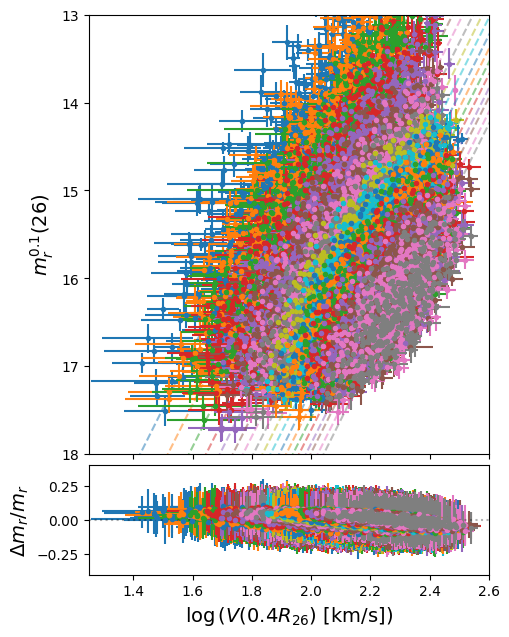

In [71]:
# fig, axes = plt.subplots(2,2, figsize=(10,7), sharex=True,
fig, axes = plt.subplots(2,1, figsize=(5,7), sharex=True,
                         gridspec_kw={'height_ratios':[4,1], 'hspace':0.04, 'wspace':0.25})

a_   = a_mcmc[1]
# b0pt = b_mcmc[0,1]
b_   = b_mcmc[:,1]#[1:]

a_irr   = a_mcmc_irr[1]
# b0pt = b_mcmc[0,1]
b_irr   = b_mcmc_irr[:,1]#[1:]

#- Plot redshift bins
# ax = axes[0,0]
ax = axes[0]

plt.rcParams['axes.prop_cycle'] = plt.cycler('color', plt.cm.viridis(np.linspace(0,1,m)))

_logv = np.arange(0, 3, 0.1) - logV0
for k in range(m):
    eb = ax.errorbar(x=logV0 + logV[k],#+1], 
                     y=mag[k],#+1], 
                     xerr=logV_err[k],#+1], 
                     yerr=mag_err[k],#+1],
                     fmt='.', 
                     label=f'{zbins[k]:.3f}-{zbins[k+1]:.3f}')

    ax.plot(_logv + logV0, a_*_logv + b_[k], color=eb[0].get_color(), ls='--', alpha=0.5)

ax.set(xlim=[1.25, 2.6],
       ylim=[18, 13])
ax.set_ylabel(r'$m_r^{0.1} (26)$', fontsize=14)
# ax.legend(loc='upper left', fontsize=9, ncol=2);
'''
#- Plot calibrators
ax = axes[0,1]
eb = ax.errorbar(x=logV[0] + logV0, y=mag[0], xerr=logV_err[0], yerr=mag_err[0],
                 fmt='.', color='tab:blue', label=f'0-pt')

ax.plot(_logv + logV0, a_*_logv + b0pt, color=eb[0].get_color(), ls='--')#, label='fit')
ax.set(xlim=[1.25, 2.6],
       ylim=[-18, -24]
      )
ax.set_ylabel(r'$M_r^{0.1}(26) = m_r^{0.1}(26) - \mu$', fontsize=14)
ax.legend(loc='upper left', fontsize=9, ncol=2)
'''
#- Plot residuals: z-bins
# ax = axes[1,0]
ax = axes[1]

plt.rcParams['axes.prop_cycle'] = plt.cycler('color', plt.cm.viridis(np.linspace(0,1,m)))

for k in range(m):
    logv_obs = logV[k]#+1]
    m_obs = mag[k]#+1]
    m_exp = (a_*logv_obs + b_[k])
    eb = ax.errorbar(x=logv_obs + logV0, y=(m_exp-m_obs)/m_exp, 
                     xerr=logV_err[k],#+1], 
                     yerr=mag_err[k],#+1],
                     fmt='.')

ax.axhline(0, ls=':', color='k', alpha=0.3)

ax.set(xlim=[1.25, 2.6],
       ylim=[-0.4, 0.4])
ax.set_xlabel(r'$\log{(V(0.4R_{26})~[\mathrm{km/s}]}$)', fontsize=14)
ax.set_ylabel(r'$\Delta m_r/m_r$', fontsize=14)
'''
#- Plot residuals: calibrators
ax = axes[1,1]

logv_obs = logV[0]
m_obs = mag[0]
m_exp = (a_*logv_obs + b0pt)

b = ax.errorbar(x=logv_obs + logV0, y=(m_exp-m_obs)/m_exp, 
                xerr=logV_err[0], yerr=mag_err[0],
                fmt='.', color='tab:blue')
ax.axhline(0, ls=':', color='k', alpha=0.3)

ax.set(xlim=[1.25, 2.6],
       ylim=[-0.4, 0.4])
ax.set_xlabel(r'$\log{(V(0.4R_{26})~[\mathrm{km/s}]}$)', fontsize=14)
ax.set_ylabel(r'$\Delta M_r/M_r$', fontsize=14)
'''
fig.subplots_adjust(left=0.1, bottom=0.1, top=0.9, right=0.9);

# fig.savefig('../../Figures/Y1/TF_Y1_cluster_calibration_0pt_binaryMLupdated_z0p1_Anthony2_weightsVmax-1_dVsys_fit0_20250717.png', 
#             dpi=150, 
#             facecolor='none')

In [72]:
print(f'slope (alpha): {-a_/2.5:.2f} +/- {np.sqrt(cov_tfr[0,0])/2.5:.3f}')

slope (alpha): 2.70 +/- 0.013


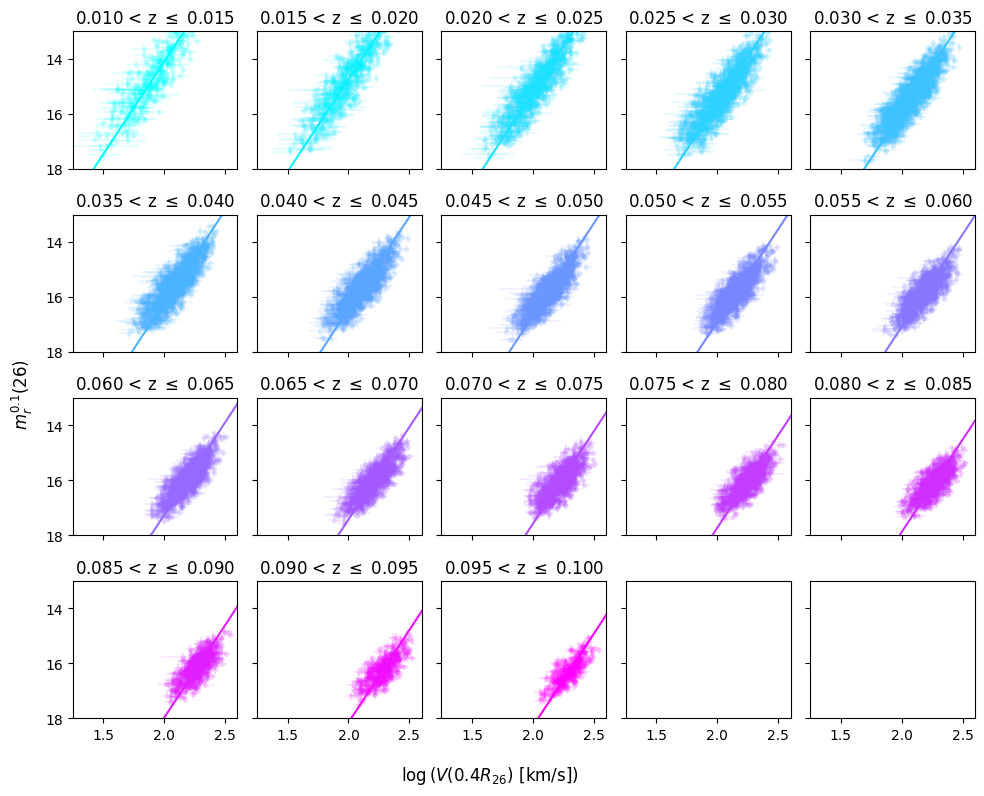

In [73]:
# fig, axs = plt.subplots(nrows=7, ncols=10, sharex=True, sharey=True, figsize=(20,16), tight_layout=True)
fig, axs = plt.subplots(nrows=4, ncols=5, sharex=True, sharey=True, figsize=(10,8), tight_layout=True)

color = iter(plt.cm.cool(np.linspace(0,1,m)))
for i in range(m):
    c = next(color)
    
    row = int(i/5)
    col = i%5
    
    eb = axs[row,col].errorbar(logV0 + logV[i],#+1], 
                               mag[i],#+1], 
                               xerr=logV_err[i],#+1], 
                               yerr=mag_err[i],#+1], 
                               fmt='.', color=c, alpha=0.1)
    axs[row,col].plot(_logv + logV0, a_*_logv + b_[i], color=c)
    
    axs[row,col].set(xlim=[1.25, 2.6], ylim=[18, 13], title=f'{zbins[i]:.3f} < z $\leq$ {zbins[i+1]:.3f}')

# Delete extra axes
# fig.delaxes(axs[-1,-1])

fig.supxlabel(r'$\log{(V(0.4R_{26})~[\mathrm{km/s}]}$)')
fig.supylabel(r'$m_r^{0.1} (26)$');

# plt.savefig('../../Figures/Y1/TF_Y1_individual_cluster_calibration_0pt_binaryMLupdated_z0p1_Anthony2_weightsVmax-1_dVsys_fit0_20250717.png', 
#             dpi=150, 
#             facecolor='none')

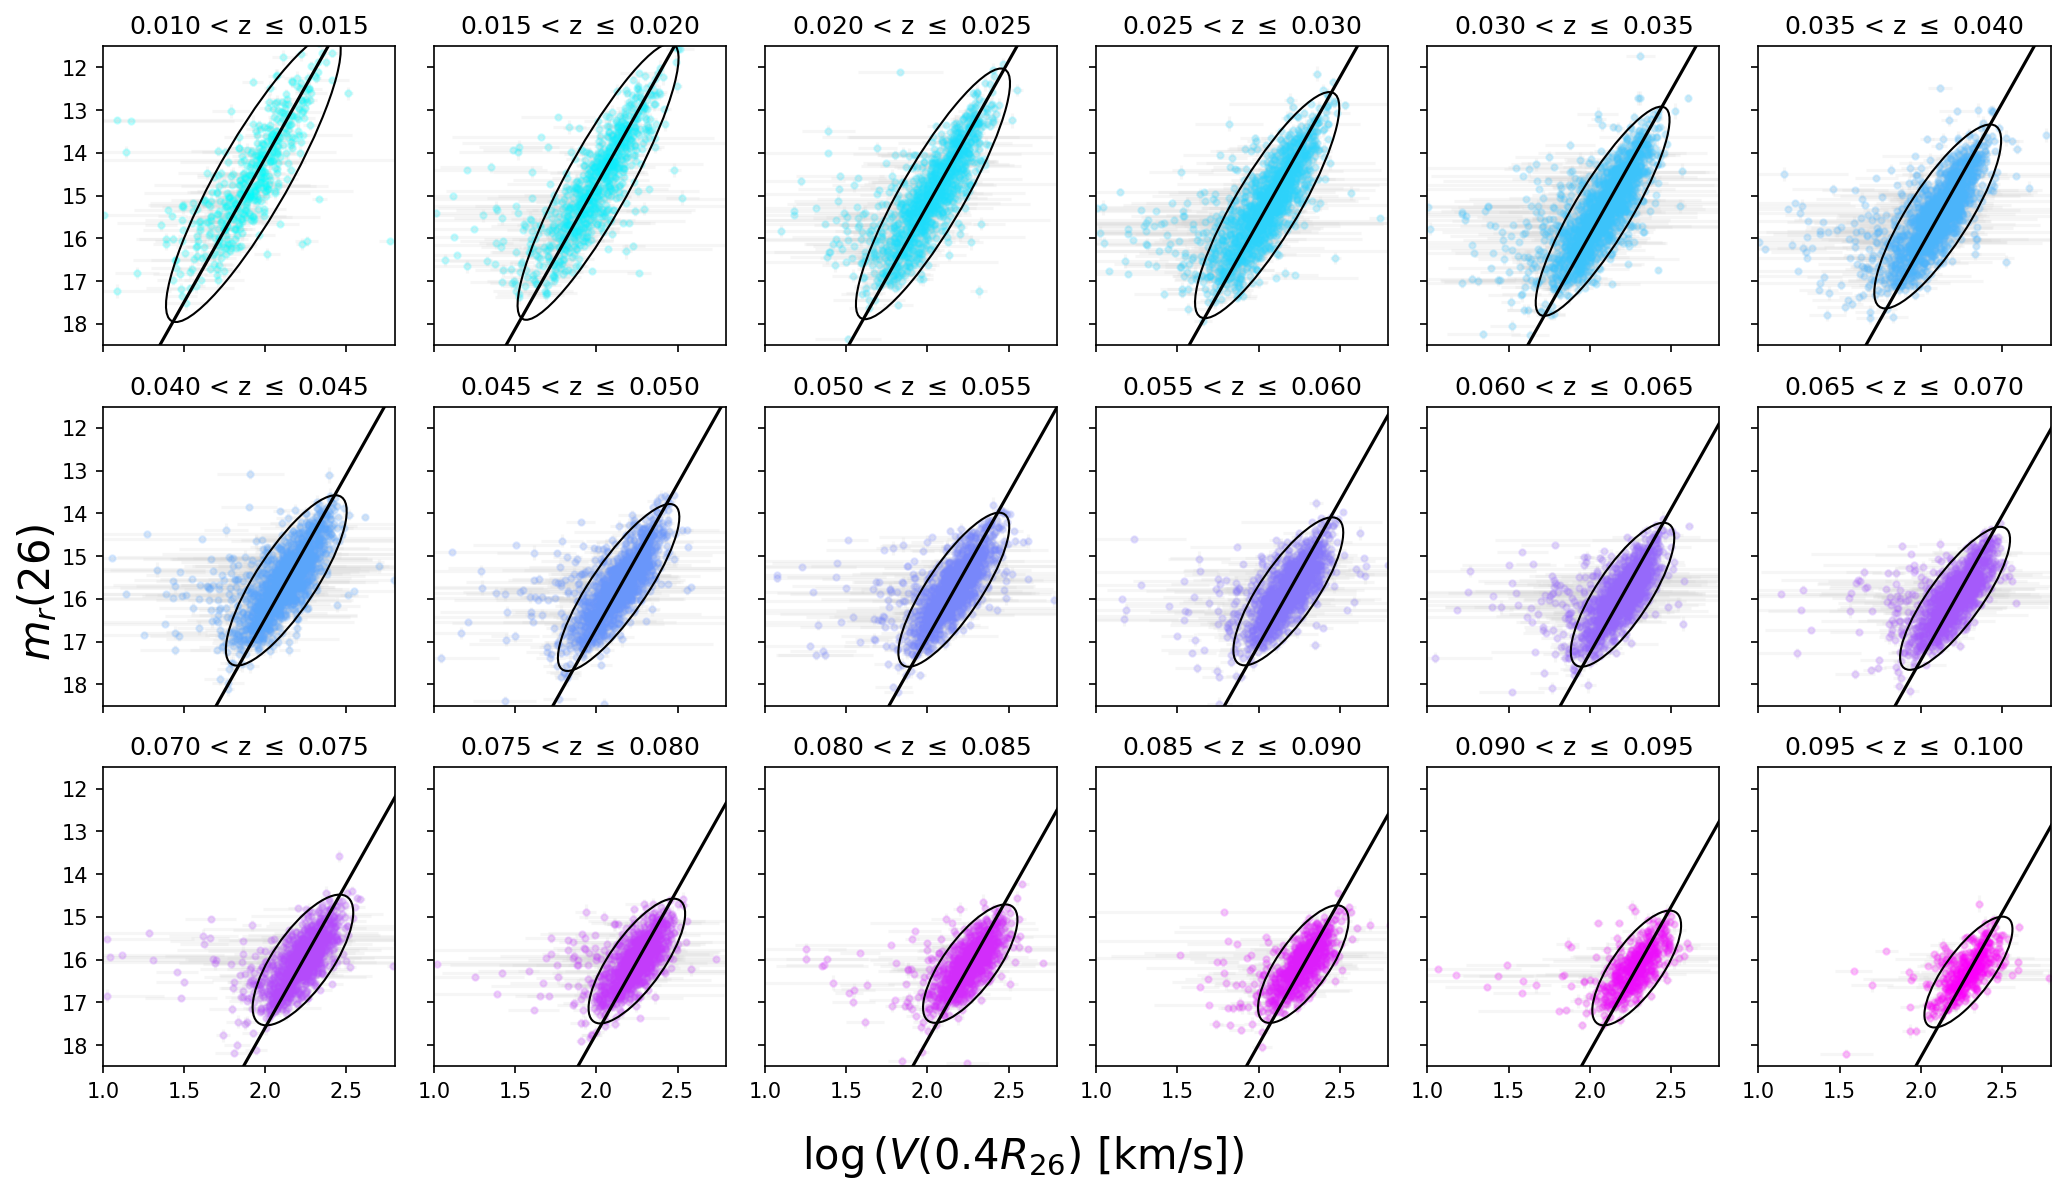

In [74]:
sgatab_spirals = sgatab[sgatab['MORPHTYPE']=='Spiral']

zbin_indices = np.digitize(sgatab_spirals['Z_DESI_CMB'], zbins, right=True)

ncols=6
fig, axs = plt.subplots(nrows=3, ncols=ncols, sharex=True, sharey=True, figsize=(14,8), tight_layout=True,
                        facecolor='none', dpi=150)
# fig, axs = plt.subplots(nrows=3, ncols=5, sharex=True, sharey=True, figsize=(10,8), tight_layout=True)
m = len(mu_x)
color = iter(plt.cm.cool(np.linspace(0,1,m)))
for i in range(m):
    c = next(color)
    
    row = int(i/ncols)
    col = i%ncols
    
    eb = axs[row,col].errorbar(np.log10(sgatab_spirals['V_0p4R26'][zbin_indices==i+1]),#+1], 
                               sgatab_spirals['R_MAG_SB26_CORR'][zbin_indices==i+1],#+1], 
                               xerr=0.43*sgatab_spirals['V_0p4R26_ERR'][zbin_indices==i+1]/sgatab_spirals['V_0p4R26'][zbin_indices==i+1],#+1], 
                               yerr=sgatab_spirals['R_MAG_SB26_ERR_CORR'][zbin_indices==i+1],#+1], 
                               fmt='.', color=c, ecolor='lightgray', alpha=0.2)
    # axs[row,col].plot(_logv + logV0, a_*_logv + b_[i], color=c)
    plot_ellipse(mean=(mu_x[i], mu_y[i]), cov = ([cov_xx[i], cov_xy[i]],[cov_yx[i], cov_yy[i]]),
                 n_std = sigma, ax=axs[row,col], edgecolor='k', facecolor='none', zorder=6)

    
    # axs[row,col].set(xlim=[1.5, 2.6], ylim=[18, 13], title=f'{zbins[i]:.3f} < z $\leq$ {(zbins[i+1] if i+2 < len(zbins) else zmax):.3f}')
    axs[row,col].plot(_logv + logV0, a_*_logv + b_[i], color='k', zorder=6)
    axs[row,col].set(xlim=[1, 2.8], ylim=[18.5, 11.5], title=f'{zbins[i]:.3f} < z $\leq$ {(zbins[i+1] if i+2 < len(zbins) else zmax):.3f}')

# Delete extra axes
# fig.delaxes(axs[-1,-1])

fig.supxlabel(r'$\log{(V(0.4R_{26})~[\mathrm{km/s}]}$)', fontsize=20)
fig.supylabel(r'$m_r (26)$', fontsize=20);

# plt.savefig('/pscratch/sd/s/sgmoore1/TF/figures/DR2_v3_bin_ellipses_postfit.png', 
#             dpi=150, 
#             facecolor='none')


In [75]:
for i in range(m):

    # Number of galaxies in this bin
    N_gal = len(mag[i])

    # Calculate expected magnitude given the measured V
    mag_TF = a_*logV[i] + b_[i]

    # Calculate difference between the predicted and measured magnitude
    mag_diff = mag[i] - mag_TF

    # plt.figure(tight_layout=True)
    # plt.hist(mag_diff, bins=30)
    # break

    # Calculate rms
    rms_scatter = np.sqrt(np.sum(mag_diff**2)/N_gal)
    
    print(f'{i:2d}  {zbins[i]:0.3f} < z <= {zbins[i+1]:0.3f}, {N_gal}  {rms_scatter:.2f} mag')

 0  0.010 < z <= 0.015, 367  0.60 mag
 1  0.015 < z <= 0.020, 626  0.53 mag
 2  0.020 < z <= 0.025, 934  0.51 mag
 3  0.025 < z <= 0.030, 1256  0.52 mag
 4  0.030 < z <= 0.035, 1514  0.47 mag
 5  0.035 < z <= 0.040, 1335  0.49 mag
 6  0.040 < z <= 0.045, 1310  0.48 mag
 7  0.045 < z <= 0.050, 1158  0.46 mag
 8  0.050 < z <= 0.055, 1178  0.45 mag
 9  0.055 < z <= 0.060, 1110  0.46 mag
10  0.060 < z <= 0.065, 1159  0.44 mag
11  0.065 < z <= 0.070, 1123  0.45 mag
12  0.070 < z <= 0.075, 974  0.48 mag
13  0.075 < z <= 0.080, 922  0.45 mag
14  0.080 < z <= 0.085, 924  0.45 mag
15  0.085 < z <= 0.090, 690  0.43 mag
16  0.090 < z <= 0.095, 502  0.44 mag
17  0.095 < z <= 0.100, 376  0.39 mag


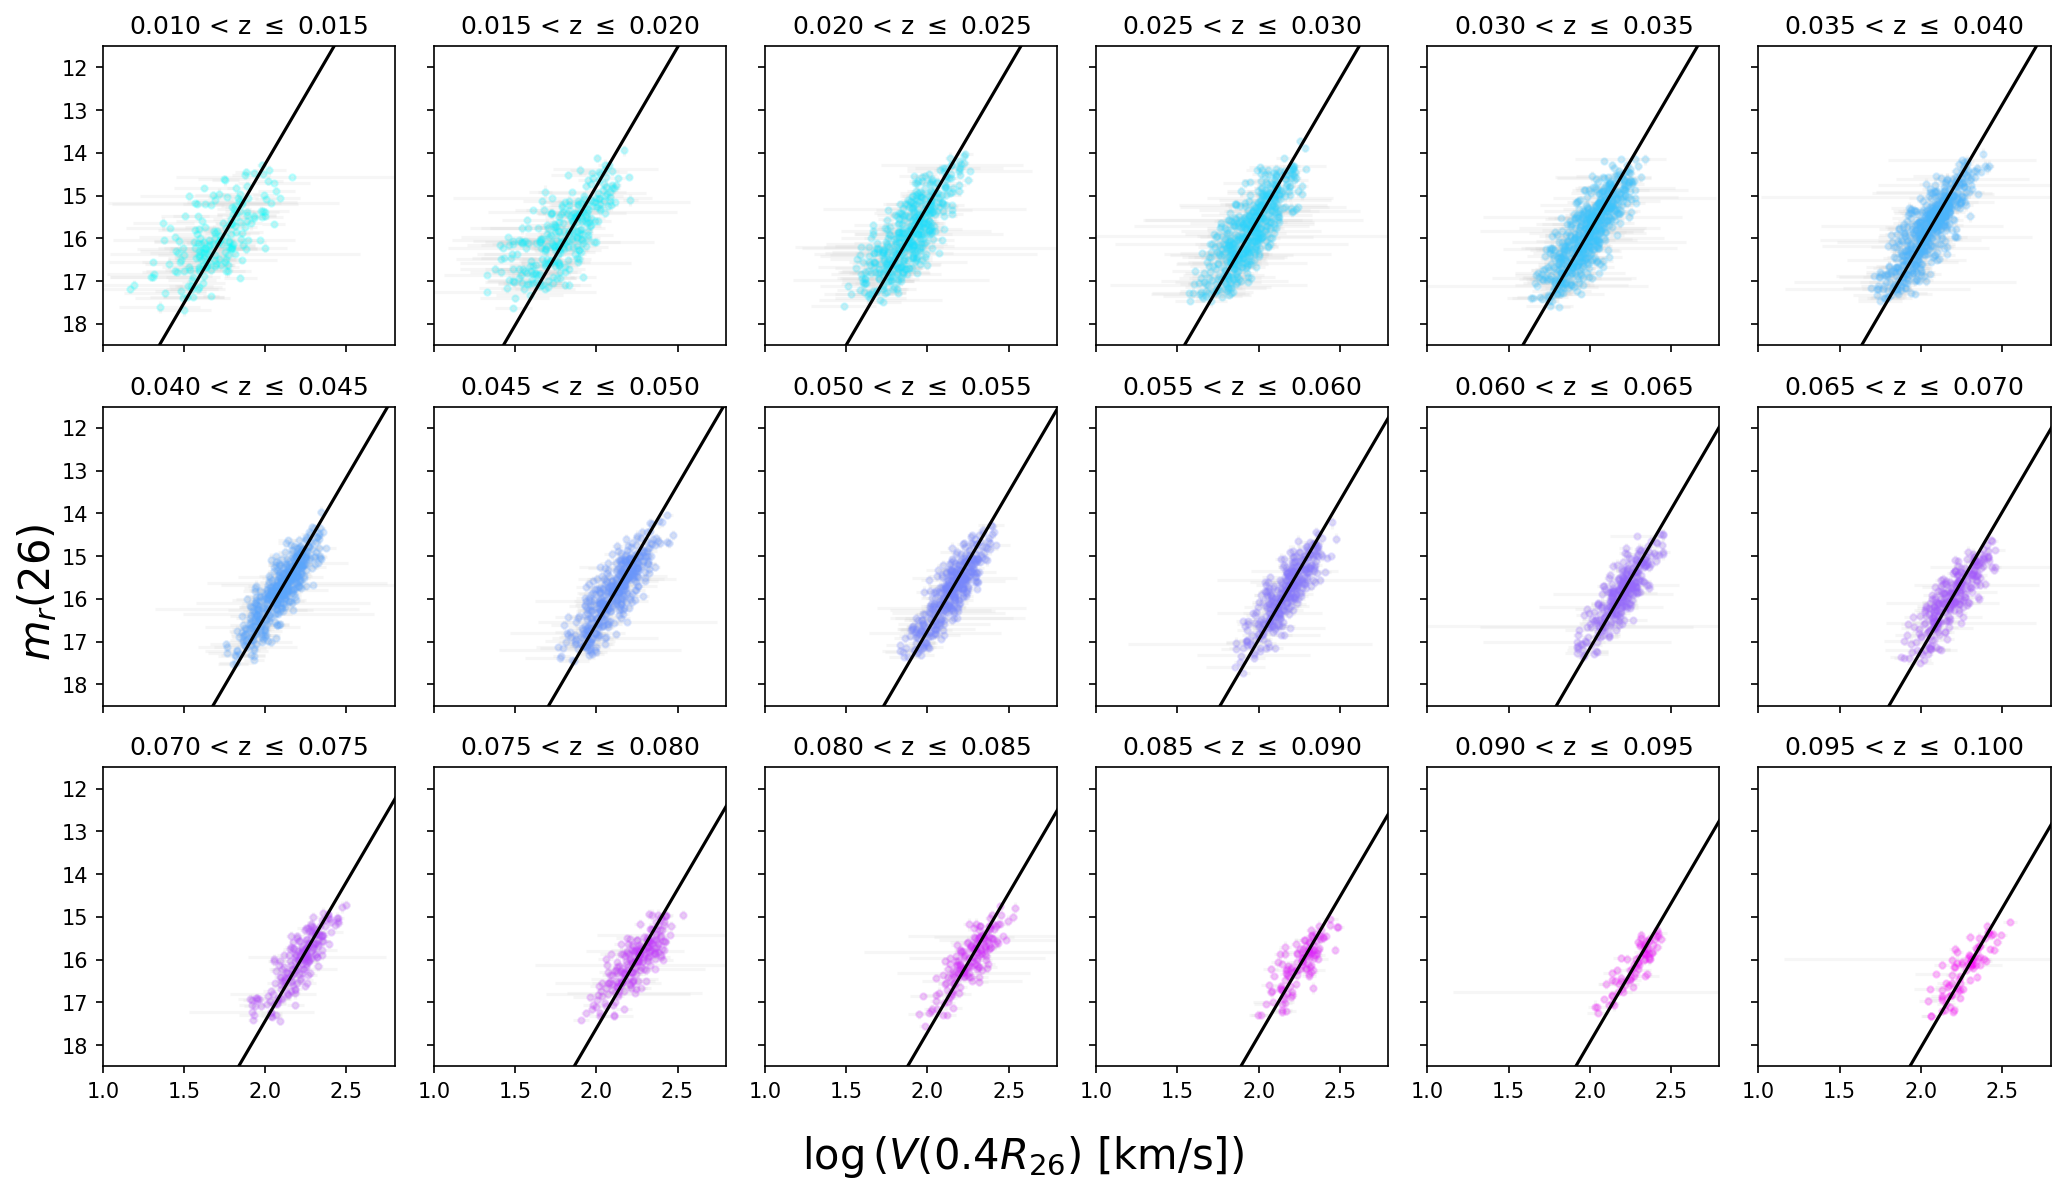

In [76]:
sgatab_irr = sgatab[(sgatab['MORPHTYPE']=='Irregular') & ~outlier_boolean_irr]

zbin_indices = np.digitize(sgatab_irr['Z_DESI_CMB'], zbins, right=True)

ncols=6
fig, axs = plt.subplots(nrows=3, ncols=ncols, sharex=True, sharey=True, figsize=(14,8), tight_layout=True,
                        facecolor='none', dpi=150)
# fig, axs = plt.subplots(nrows=3, ncols=5, sharex=True, sharey=True, figsize=(10,8), tight_layout=True)
m = len(mu_x)
color = iter(plt.cm.cool(np.linspace(0,1,m)))
for i in range(m):
    c = next(color)
    
    row = int(i/ncols)
    col = i%ncols
    
    eb = axs[row,col].errorbar(np.log10(sgatab_irr['V_0p4R26'][zbin_indices==i+1]),#+1], 
                               sgatab_irr['R_MAG_SB26_CORR'][zbin_indices==i+1],#+1], 
                               xerr=0.43*sgatab_irr['V_0p4R26_ERR'][zbin_indices==i+1]/sgatab_irr['V_0p4R26'][zbin_indices==i+1],#+1], 
                               yerr=sgatab_irr['R_MAG_SB26_ERR_CORR'][zbin_indices==i+1],#+1], 
                               fmt='.', color=c, ecolor='lightgray', alpha=0.2)
    # # axs[row,col].plot(_logv + logV0, a_*_logv + b_[i], color=c)
    # plot_ellipse(mean=(mu_x[i], mu_y[i]), cov = ([cov_xx[i], cov_xy[i]],[cov_yx[i], cov_yy[i]]),
    #              n_std = sigma, ax=axs[row,col], edgecolor='k', facecolor='none', zorder=6)

    
    # axs[row,col].set(xlim=[1.5, 2.6], ylim=[18, 13], title=f'{zbins[i]:.3f} < z $\leq$ {(zbins[i+1] if i+2 < len(zbins) else zmax):.3f}')
    axs[row,col].plot(_logv + logV0_irr, a_irr*_logv + b_irr[i], color='k', zorder=6)
    axs[row,col].set(xlim=[1, 2.8], ylim=[18.5, 11.5], title=f'{zbins[i]:.3f} < z $\leq$ {(zbins[i+1] if i+2 < len(zbins) else zmax):.3f}')

# Delete extra axes
# fig.delaxes(axs[-1,-1])

fig.supxlabel(r'$\log{(V(0.4R_{26})~[\mathrm{km/s}]}$)', fontsize=20)
fig.supylabel(r'$m_r (26)$', fontsize=20);

# plt.savefig('/pscratch/sd/s/sgmoore1/TF/figures/DR2_v3_bin_ellipses_postfit.png', 
#             dpi=150, 
#             facecolor='none')


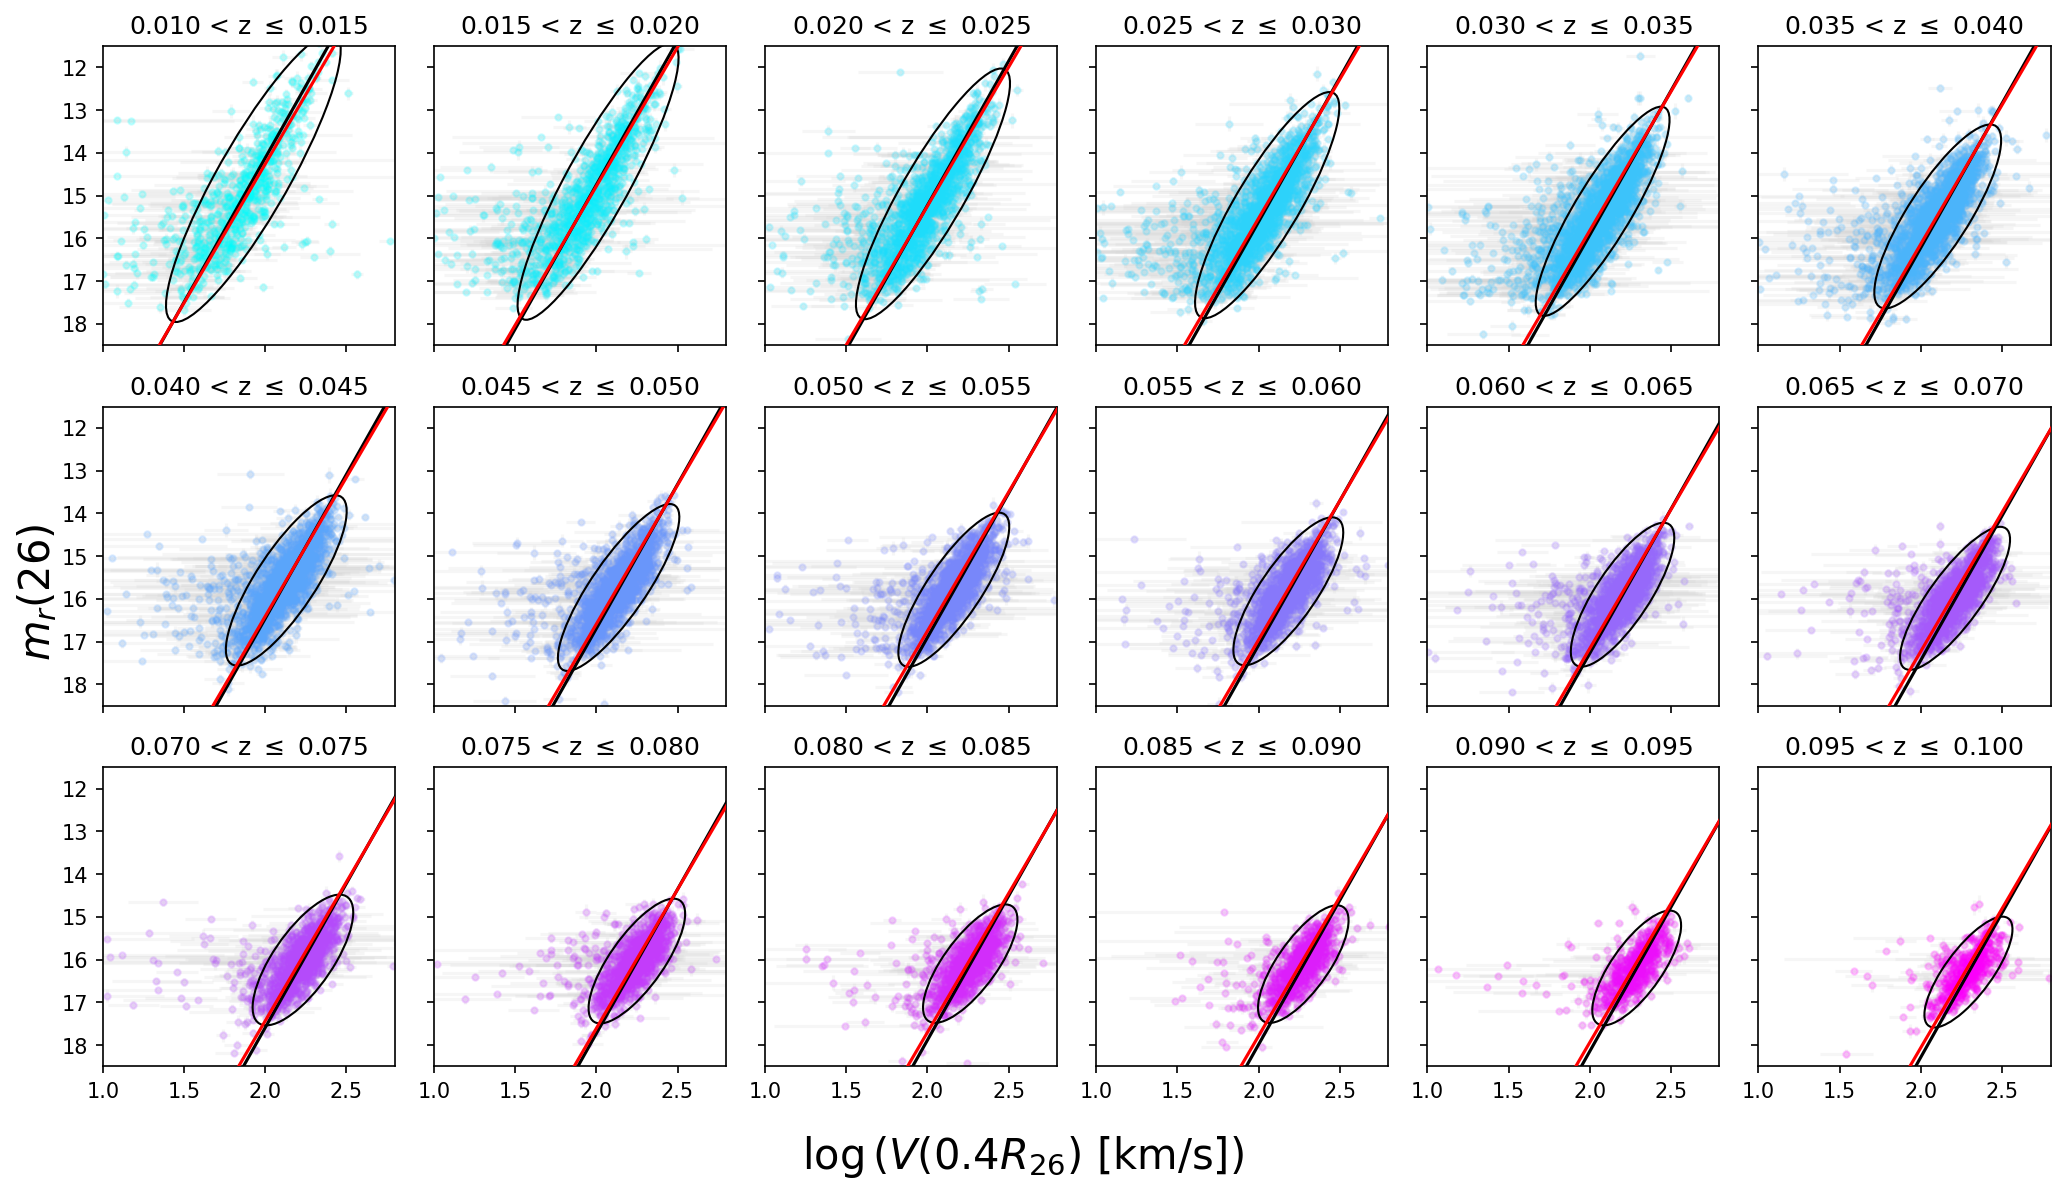

In [77]:
zbin_indices = np.digitize(sgatab['Z_DESI_CMB'], zbins, right=True)

ncols=6
fig, axs = plt.subplots(nrows=3, ncols=ncols, sharex=True, sharey=True, figsize=(14,8), tight_layout=True,
                        facecolor='none', dpi=150)
# fig, axs = plt.subplots(nrows=3, ncols=5, sharex=True, sharey=True, figsize=(10,8), tight_layout=True)
m = len(mu_x)
color = iter(plt.cm.cool(np.linspace(0,1,m)))
for i in range(m):
    c = next(color)
    
    row = int(i/ncols)
    col = i%ncols
    
    eb = axs[row,col].errorbar(np.log10(sgatab['V_0p4R26'][zbin_indices==i+1]),#+1], 
                               sgatab['R_MAG_SB26_CORR'][zbin_indices==i+1],#+1], 
                               xerr=0.43*sgatab['V_0p4R26_ERR'][zbin_indices==i+1]/sgatab['V_0p4R26'][zbin_indices==i+1],#+1], 
                               yerr=sgatab['R_MAG_SB26_ERR_CORR'][zbin_indices==i+1],#+1], 
                               fmt='.', color=c, ecolor='lightgray', alpha=0.2)
    # axs[row,col].plot(_logv + logV0, a_*_logv + b_[i], color=c)
    plot_ellipse(mean=(mu_x[i], mu_y[i]), cov = ([cov_xx[i], cov_xy[i]],[cov_yx[i], cov_yy[i]]),
                 n_std = sigma, ax=axs[row,col], edgecolor='k', facecolor='none', zorder=6)

    
    # axs[row,col].set(xlim=[1.5, 2.6], ylim=[18, 13], title=f'{zbins[i]:.3f} < z $\leq$ {(zbins[i+1] if i+2 < len(zbins) else zmax):.3f}')
    axs[row,col].plot(_logv + logV0, a_*_logv + b_[i], color='k', zorder=6)
    axs[row,col].plot(_logv + logV0_irr, a_irr*_logv + b_irr[i], color='red', zorder=6)
    axs[row,col].set(xlim=[1, 2.8], ylim=[18.5, 11.5], title=f'{zbins[i]:.3f} < z $\leq$ {(zbins[i+1] if i+2 < len(zbins) else zmax):.3f}')

# Delete extra axes
# fig.delaxes(axs[-1,-1])

fig.supxlabel(r'$\log{(V(0.4R_{26})~[\mathrm{km/s}]}$)', fontsize=20)
fig.supylabel(r'$m_r (26)$', fontsize=20);

# plt.savefig('/pscratch/sd/s/sgmoore1/TF/figures/DR2_v3_bin_ellipses_postfit.png', 
#             dpi=150, 
#             facecolor='none')


In [78]:
# ncols = 6
# fig, axs = plt.subplots(
#     3, ncols,
#     sharex=True, sharey=True,
#     figsize=(14,8),
#     tight_layout=True,
#     dpi=150,
#     facecolor='none'
# )

# for i in range(len(mu_x)):

#     row = i // ncols
#     col = i % ncols
#     ax = axs[row, col]

#     # -----------------------
#     # data (gray)
#     # -----------------------
#     m = zbin_indices == i+1

#     ax.errorbar(
#         np.log10(sgatab['V_0p4R26'][m]),
#         sgatab['R_MAG_SB26_CORR'][m],
#         xerr=0.43*sgatab['V_0p4R26_ERR'][m]/sgatab['V_0p4R26'][m],
#         yerr=sgatab['R_MAG_SB26_ERR_CORR'][m],
#         fmt='.',
#         color='lightgray',
#         ecolor='lightgray',
#         alpha=0.01,
#         zorder=1
#     )

#     # -----------------------
#     # fit 1
#     # -----------------------
#     a_samples = tfr_mcmc_samples[0]          # (n_samples,)
#     b_samples = np.asarray(tfr_mcmc_samples[1:-1])  # (m, n_samples)
#     y_draws = (
#         a_samples[:, None] * _logv[None, :]
#         + b_samples[i][:, None]
#     )
    
#     y_med = np.median(y_draws, axis=0)
#     y_lo  = np.percentile(y_draws, 16, axis=0)
#     y_hi  = np.percentile(y_draws, 84, axis=0)
#     ax.fill_between(
#         _logv+logV0,
#         y_lo,
#         y_hi,
#         color='tab:blue',
#         alpha=0.5,
#         zorder=2
#     )

#     ax.plot(
#         _logv+logV0,
#         y_med,
#         color='tab:blue',
#         lw=1,
#         zorder=3
#     )

#     # -----------------------
#     # fit 2
#     # -----------------------
#     a_samples_irr = tfr_mcmc_samples_irr[0]          # (n_samples,)
#     b_samples_irr = np.asarray(tfr_mcmc_samples_irr[1:-1])  # (m, n_samples)
#     y_draws = (
#         a_samples_irr[:, None] * _logv[None, :]
#         + b_samples_irr[i][:, None]
#     )
    
#     y_med = np.median(y_draws, axis=0)
#     y_lo  = np.percentile(y_draws, 16, axis=0)
#     y_hi  = np.percentile(y_draws, 84, axis=0)

#     ax.fill_between(
#         _logv+logV0_irr,
#         y_lo,
#         y_hi,
#         color='tab:orange',
#         alpha=0.5,
#         zorder=2
#     )

#     ax.plot(
#         _logv+logV0_irr,
#         y_med,
#         color='tab:orange',
#         lw=1,
#         zorder=3
#     )

#     ax.set(
#         xlim=[1, 2.8],
#         ylim=[18.5, 11.5],
#         title=f'{zbins[i]:.3f} < z ≤ {(zbins[i+1] if i+2 < len(zbins) else zmax):.3f}'
#     )

# fig.supxlabel(r'$\log(V(0.4R_{26})\,[\mathrm{km/s}])$', fontsize=20)
# fig.supylabel(r'$m_r(26)$', fontsize=20)

In [79]:
# i=4
# color = iter(plt.cm.Purples_r(np.linspace(0,1,8)))
# plt.figure(figsize=(5,5), facecolor='none', dpi=150)
# fig = plt.gcf()
# ax = plt.gca()
# plt.errorbar(np.log10(sgatab['V_0p4R26'][zbin_indices==i+1]),#+1], 
#              sgatab['R_MAG_SB26_CORR'][zbin_indices==i+1],#+1], 
#              xerr=0.43*sgatab['V_0p4R26_ERR'][zbin_indices==i+1]/sgatab['V_0p4R26'][zbin_indices==i+1],#+1], 
#              yerr=sgatab['R_MAG_SB26_ERR_CORR'][zbin_indices==i+1],#+1], 
#              fmt='.', c='gray', ecolor='lightgray', alpha=0.05)
#     # axs[row,col].plot(_logv + logV0, a_*_logv + b_[i], color=c)
# # for scale in {2,2.5,3,4,5}:
# #     plot_ellipse(mean=(mu_x[i], mu_y[i]), cov = ([cov_xx[i], cov_xy[i]],[cov_yx[i], cov_yy[i]]),
# #                  n_std = scale, ax=ax, edgecolor=next(color), linewidth=1, linestyle ='dashed',facecolor='none', label=f'scale={scale}', zorder=3)

# plot_ellipse(mean=(mu_x[i], mu_y[i]), cov = ([cov_xx[i], cov_xy[i]],[cov_yx[i], cov_yy[i]]),
#                  n_std = sigma, ax=ax, edgecolor='k', linewidth=2,facecolor='none', label=f'scale=2.86 (best)', zorder=3)

# # plt.plot(_logv + logV0, a_*_logv + b_[i], color='k', zorder=6)
# # plt.plot(_logv + logV0_irr, a_irr*_logv + b_irr[i], color='orange', zorder=6)

# a_samples = tfr_mcmc_samples[0]          # (n_samples,)
# b_samples = np.asarray(tfr_mcmc_samples[1:-1])  # (m, n_samples)
# y_draws = (
#     a_samples[:, None] * _logv[None, :]
#     + b_samples[i][:, None]
# )

# y_med = np.median(y_draws, axis=0)
# y_lo  = np.percentile(y_draws, 16, axis=0)
# y_hi  = np.percentile(y_draws, 84, axis=0)


# plt.fill_between(
#         _logv+logV0,
#         y_lo,
#         y_hi,
#         color='tab:blue',
#         alpha=0.8,
#         zorder=5, label='Spiral Fit')

# a_samples_irr = tfr_mcmc_samples_irr[0]          # (n_samples,)
# b_samples_irr = np.asarray(tfr_mcmc_samples_irr[1:-1])  # (m, n_samples)
# y_draws_irr = (
#     a_samples_irr[:, None] * _logv[None, :]
#     + b_samples_irr[i][:, None]
# )

# y_med_irr = np.median(y_draws_irr, axis=0)
# y_lo_irr  = np.percentile(y_draws_irr, 16, axis=0)
# y_hi_irr  = np.percentile(y_draws_irr, 84, axis=0)


# plt.fill_between(
#         _logv+logV0_irr,
#         y_lo_irr,
#         y_hi_irr,
#         color='tab:orange',
#         alpha=0.8,
#         zorder=5, label='Irregular Fit')


# ax.set(xlim=[1, 2.8], ylim=[18.5, 11.5])
# plt.title(f'{zbins[i]:.3f} < z $\leq$ {(zbins[i+1] if i+2 < len(zbins) else zmax):.3f}', fontsize=14)
# plt.xlabel(r'$\log{(V(0.4R_{26})~[\mathrm{km/s}]}$)', fontsize=16)
# plt.ylabel(r'$m_r (26)$', fontsize=16)
# plt.legend();

# # plt.savefig('/pscratch/sd/s/sgmoore1/TF/figures/v7_bin_ellipses_scales.png', 
# #             dpi=150, 
# #             facecolor='none')


# Calculate logdistance ratios

In [80]:
cosmo = FlatLambdaCDM(H0=H0, Om0=0.3151)
# cosmo = DESI()

# sgatab['MU_ZCMB'] = cosmo.distmod(sgatab['Z_DESI_CMB'])
# update to properly account for which redshift belong where, consistent with FP
# sgatab['MU_ZCMB'] = 5*np.log10(cosmo.comoving_distance(sgatab["Z_DESI_CMB"]).value * (1 + sgatab["Z_DESI"]))+25


sgatab['R_ABSMAG_SB26'] = sgatab['R_MAG_SB26_CORR'] - sgatab['MU_ZCMB'].value

In [81]:
rng = np.random.default_rng()

N_samples = 1000

mu_err = np.empty(len(sgatab['MU_ZCMB']))*u.mag

for i in tqdm(range(len(mu_err))):
    
    z_desi_random = rng.normal(np.abs(sgatab['Z_DESI_CMB'][i]), 
                               sgatab['ZERR_DESI'][i], 
                               N_samples)
    
    mu_random = cosmo.distmod(z_desi_random)
    
    mu_err[i] = np.std(mu_random)

sgatab['MU_ZCMB_ERR'] = mu_err

sgatab['R_ABSMAG_SB26_ERR'] = np.sqrt(sgatab['R_MAG_SB26_ERR_CORR']**2 + sgatab['MU_ZCMB_ERR'].value**2)

100%|██████████| 32488/32488 [00:29<00:00, 1099.36it/s]


In [82]:
# Center redshift values of each bin
zmin = 0.01
zmax = 0.1
dz = 0.005
zbins = np.arange(zmin, zmax+dz/2, dz)
zc = 0.5*dz + zbins[:-1]

# Distance modulus for each redshift bin center
mu_zc = cosmo.distmod(zc)

In [83]:
slopes = tfr_mcmc_samples[0]
slope = np.median(tfr_mcmc_samples[0])
slope_err = np.sqrt(cov_tfr[0,0])

# Each redshift bin has its own 0pt
# To put it in absolute-magnitude space, we'll convert it to an absolute magnitude using the middle of the redshift bin
ZPs = tfr_mcmc_samples[1:-1] - mu_zc[:,None].value
ZP = np.median(tfr_mcmc_samples[1:-1], axis=1) - mu_zc.value
ZP_err = np.sqrt(np.diagonal(cov_tfr[1:-1,1:-1])) # Should include z-bin width to this uncertainty

sig = np.median(tfr_mcmc_samples[-1])

logv = np.linspace(-1*np.ones(len(zbins)-1), 3.5*np.ones(len(zbins)-1), 100)
absmag = slope*(logv - logV0) + ZP

In [84]:
slopes_irr = tfr_mcmc_samples_irr[0]
slope_irr = np.median(tfr_mcmc_samples_irr[0])
slope_irr_err = np.sqrt(cov_tfr_irr[0,0])

# Each redshift bin has its own 0pt
# To put it in absolute-magnitude space, we'll convert it to an absolute magnitude using the middle of the redshift bin
ZPs_irr = tfr_mcmc_samples_irr[1:-1] - mu_zc[:,None].value
ZP_irr = np.median(tfr_mcmc_samples_irr[1:-1], axis=1) - mu_zc.value
ZP_irr_err = np.sqrt(np.diagonal(cov_tfr_irr[1:-1,1:-1])) # Should include z-bin width to this uncertainty

sig_irr = np.median(tfr_mcmc_samples_irr[-1])

logv = np.linspace(-1*np.ones(len(zbins)-1), 3.5*np.ones(len(zbins)-1), 100)
absmag_irr = slope_irr*(logv - logV0) + ZP_irr

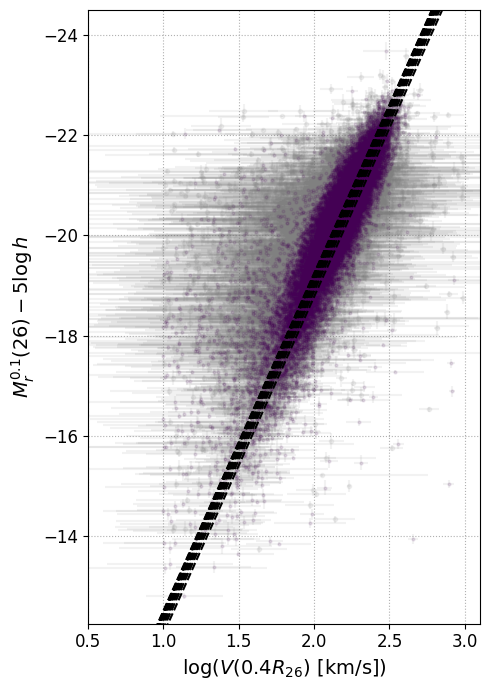

In [85]:
plt.figure(figsize=(5,7), tight_layout=True)

plt.grid(ls=':')

# plt.fill_between(logv, line_err[0], line_err[1], color='lightgray')

sample = outlier_boolean# & morph_boolean
plt.errorbar(sgatab['logV_SBcorr'][sample], 
             sgatab['R_ABSMAG_SB26'][sample], 
             xerr=sgatab['logV_SBcorr_err'][sample],
             yerr=sgatab['R_ABSMAG_SB26_ERR'][sample], 
             fmt='.',
             color='gray',
             alpha=0.1, 
             ecolor='gray')

sample = ~outlier_boolean# & morph_boolean
plt.errorbar(sgatab['logV_SBcorr'][sample], 
             sgatab['R_ABSMAG_SB26'][sample], 
             xerr=sgatab['logV_SBcorr_err'][sample],
             yerr=sgatab['R_ABSMAG_SB26_ERR'][sample], 
             fmt='.', 
             markersize=4, 
             alpha=0.1, 
             ecolor='gray')

# sample = ~outlier_boolean_alt & outlier_boolean
# plt.errorbar(np.log10(sgatab['V_0p4R26'][sample]), 
#              sgatab['R_ABSMAG_SB26'][sample], 
#              xerr=0.434*sgatab['V_0p4R26_ERR'][sample]/sgatab['V_0p4R26'][sample],
#              yerr=sgatab['R_ABSMAG_SB26_ERR'][sample], 
#              fmt='.', 
#              markersize=4, 
#              alpha=0.2, 
#              ecolor='gray')



plt.plot(logv, absmag, 'k--', zorder=3)

plt.xlim([0.5, 3.1])
plt.ylim([-12.25, -24.5])

plt.xlabel('log($V(0.4R_{26})$ [km/s])', fontsize=14)
plt.ylabel('$M_r^{0.1} (26) - 5\log h$', fontsize=14);

ax = plt.gca()
ax.tick_params(axis='both', which='major', labelsize=12);

# plt.savefig('../../Figures/Y1/iron_jointTFR_varyV0-perpdwarf_z0p1_Anthony2_weightsVmax-1_dVsys_20250717.png', 
#             dpi=150, 
#             facecolor='none')

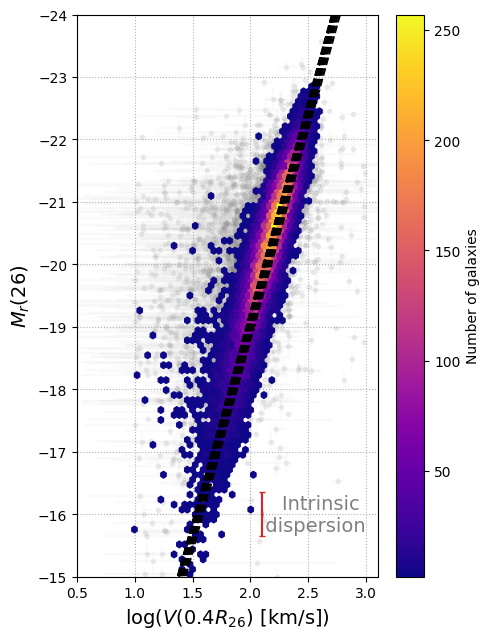

In [86]:
plt.figure(figsize=(5,6.5), tight_layout=True)
plt.grid(ls=':')

plt.errorbar(sgatab['logV_SBcorr'][outlier_boolean], 
             sgatab['R_ABSMAG_SB26'][outlier_boolean], 
             xerr=sgatab['logV_SBcorr_err'][outlier_boolean],
             yerr=sgatab['R_ABSMAG_SB26_ERR'][outlier_boolean], 
             fmt='.',
             color='gray',
             alpha=0.1, 
             ecolor='lightgray', zorder=1)

plt.hexbin(sgatab['logV_SBcorr'][~outlier_boolean], 
           sgatab['R_ABSMAG_SB26'][~outlier_boolean], 
           cmap='plasma', 
           mincnt=2, 
           gridsize=(70,80), 
           extent=(-0.1, 3.1, -25, -12.25), zorder=2)
plt.colorbar(label='Number of galaxies')

# plt.fill_between(logv, line_err[0], line_err[1], color='lightgray', alpha=0.2)
plt.plot(logv, absmag, 'k--', zorder=3)


plt.errorbar([2.1], [-16], 
             xerr=0,
             yerr=sig, 
             ecolor='tab:red', 
             capsize=2)
plt.annotate('Intrinsic \n dispersion', 
             (3, -16), 
             va='center',
             ha='right',
             c='gray',
             fontsize=14)

plt.xlim([0.5, 3.1])
plt.ylim([-15, -24])

plt.xlabel('log($V(0.4R_{26})$ [km/s])', fontsize=14)
plt.ylabel('$M_r(26)$', fontsize=14)

plt.savefig('/pscratch/sd/s/sgmoore1/TF/figures/Y3_tfr_hexbin_hyperfit_v5a.png', 
            dpi=150, 
            facecolor='none')

## Store TFR fit parameters

In [87]:
###### Write to a table
tfr_params = Table([mu_zc, ZP, ZP_err, ZP_irr, ZP_irr_err],
    names=['MU_BIN', 'B_SPIRAL', 'B_SPIRAL_ERR', 'B_IRR', 'B_IRR_ERR'])

hdr = fits.Header()

hdr['A_SPIRAL'] = slope
hdr['A_SPIRAL_ERR'] = slope_err
hdr['A_IRR'] = slope_irr
hdr['A_IRR_ERR'] = slope_irr_err
hdr['LOGV0'] = logV0
hdr['ZMIN'] = 0.01
hdr['ZMAX'] = 0.10
hdr['ZBIN_WIDTH']=0.005


empty_primary = fits.PrimaryHDU(header=hdr)
table_hdu = fits.BinTableHDU(data=tfr_params)

hdul = fits.HDUList([empty_primary, table_hdu])

# # Write results to file
hdul.writeto('../TF_Y3_TFR_fit_params_v5a.fits', 
             overwrite=True)

#### Redshift distribution

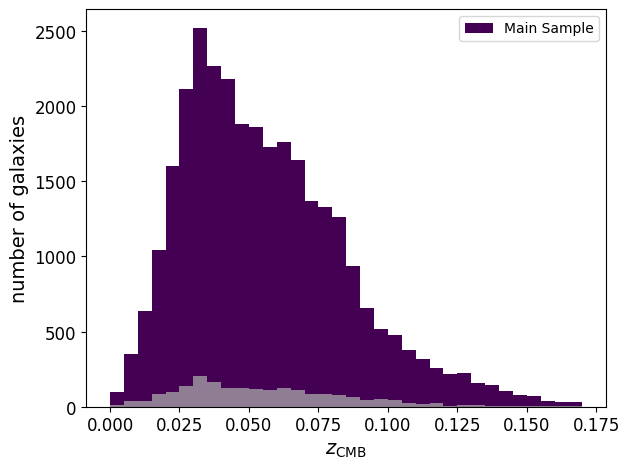

In [88]:
plt.figure(tight_layout=True)

plt.hist(sgatab['Z_DESI_CMB'][~outlier_boolean],
         bins=np.arange(0, 0.175, 0.005), label='Main Sample')
plt.hist(sgatab['Z_DESI_CMB'][outlier_boolean],
         bins=np.arange(0, 0.175, 0.005), 
         color='darkgray',
         alpha=0.75, label='')

plt.tick_params(axis='both', which='major', labelsize=12)

plt.xlabel(r'$z_{\text{CMB}}$', fontsize=14)
plt.ylabel('number of galaxies', fontsize=14)
plt.legend()
# plt.savefig('/pscratch/sd/s/sgmoore1/TF/figures/DR2_v3_histogram_z.png', 
#             dpi=150, 
#             facecolor='none')

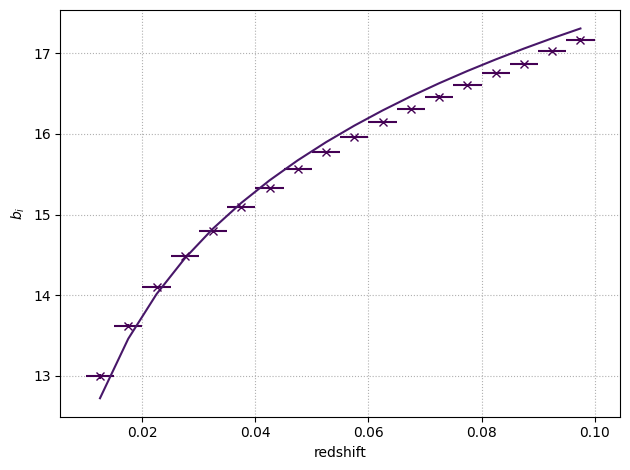

In [89]:
plt.figure(tight_layout=True)

plt.grid(ls=':')

plt.errorbar(zc, np.median(tfr_mcmc_samples[1:-1], axis=1), 
             xerr=0.5*dz, 
             yerr=ZP_err, 
             fmt='x')

plt.plot(zc, mu_zc-20.17*u.mag, label=r'$\mu (\Omega_{m,0}=0.3151, h=1) - 20.17$')
# plt.xlim(0.028, 0.102)
# plt.ylim(-20.5, -20.7)

plt.xlabel('redshift')
plt.ylabel('$b_i$');

# Distance moduli

## For spirals
Or for the sake of the calculation, everything but the irregulars

In [90]:
sgatab_spirals = sgatab[sgatab['MORPHTYPE']=='Spiral']

In [91]:
# First, match each galaxy to its redshift bin
zbin_indices = np.digitize(sgatab_spirals['Z_DESI_CMB'], zbins, right=True)

# For those galaxies that fall outside the calibration range, assign them to the closest bin
zbin_indices[zbin_indices == 0] = 1
zbin_indices[zbin_indices == len(zbins)] = len(zbins) - 1

# Then, use that galaxy's redshift bin's zero-point to calculate the distance modulus
sgatab_spirals['R_ABSMAG_SB26_TF'] = np.nan
for i in range(len(sgatab_spirals)):
    sgatab_spirals['R_ABSMAG_SB26_TF'][i] = slope*(sgatab_spirals['logV_SBcorr'][i] - logV0) + ZP[zbin_indices[i] - 1]

In [92]:
sgatab_spirals['R_ABSMAG_SB26_TF_ERR'] = np.nan
sgatab_spirals['R_ABSMAG_SB26_TF_ERR_STAT'] = np.nan

rng = np.random.default_rng()

for i in tqdm(range(len(sgatab_spirals))):
    
    v_random = rng.normal(10**sgatab_spirals['logV_SBcorr'][i], 
                          (10**sgatab_spirals['logV_SBcorr'][i])*sgatab_spirals['logV_SBcorr_err'][i]/0.434, 
                          # size=10000)
                          size=len(slopes))
    v_random_good = v_random[v_random > 0]

    ############################################################################
    # Statistical uncertainty
    #---------------------------------------------------------------------------
    Ms_stat = slope*(np.log10(v_random_good) - logV0) + ZP[zbin_indices[i] - 1]

    sgatab_spirals['R_ABSMAG_SB26_TF_ERR_STAT'][i] = np.nanstd(Ms_stat)
    ############################################################################

    
    ############################################################################
    # Total uncertainty
    #---------------------------------------------------------------------------
    Ms = slopes[v_random > 0]*(np.log10(v_random_good) - logV0) + ZPs[zbin_indices[i] - 1,v_random > 0]
    
    sgatab_spirals['R_ABSMAG_SB26_TF_ERR'][i] = np.sqrt(np.nanstd(Ms)**2 + sig**2)
    ############################################################################
    

################################################################################
# Systematic uncertainty
#-------------------------------------------------------------------------------
sgatab_spirals['R_ABSMAG_SB26_TF_ERR_SYS'] = np.sqrt(sgatab_spirals['R_ABSMAG_SB26_TF_ERR']**2 - sgatab_spirals['R_ABSMAG_SB26_TF_ERR_STAT']**2)
################################################################################

100%|██████████| 25388/25388 [31:56<00:00, 13.25it/s]


In [13]:
def profile_histogram(x, y, xbins, yerr=None, weights=None, median=False, weighted=False):
    """Compute a profile histogram from scattered data.
    
    Parameters
    ----------
    x : list or ndarray
        Ordinates (independent variable).
    y : list or ndarray
        Coordinates (dependent variable).
    xbins : list or ndarray
        Bin edges for the independent variable.
    yerr : list or ndarray
        Uncertainties on the dependent variable. Assumed independent.
    weights : list or ndarray
        If not None (and weighted=True), will use this instead of yerr to weight 
        the summary statistics.
    median : bool
        If true, compute median as central value; else, the (weighted) mean.
    weighted : bool
        Weight the summary statistics, either by the uncertainty in y or the 
        provided weights.
        
    Returns
    -------
    N : ndarray
        Unweighted counts per bin.
    h : ndarray
        Summary statistic (mean or median) of independent variable per bin.
    e : ndarray
        Uncertainty on the summary statistic per bin.
    """
    
    N = binned_statistic(x, y, bins=xbins, statistic='count').statistic

    if weighted:
        if (yerr is None) and (weights is None):
            raise ValueError('need to define either yerr or weights if using weighted fit.')

        if weights is None:
            # weight based on yerr
            w = 1/yerr**2
        else:
            w = weights
        W, H, E = binned_statistic(x, [w, w*y, w*y**2], bins=xbins, statistic='sum').statistic
        h = H/W
        e = 1/np.sqrt(W)
    else:
        mean, mean2 = binned_statistic(x, [y, y**2], bins=xbins, statistic='mean').statistic
        h = mean
        e = np.sqrt((mean2 - mean**2) / (N - 1))

    if median:
        h = binned_statistic(x, y, bins=xbins, statistic='median').statistic
    
    return N, h, e

In [94]:
# zbins = np.arange(0, 0.105, 0.005)
# dz = 0.5*np.diff(zbins)
# zc = 0.5*(zbins[1:] + zbins[:-1])

# sample1 = ~outlier_boolean
# sample2 = outlier_boolean

# plt.figure(tight_layout=True)

# # plt.plot(tf_data['Z_DESI_CMB'][sample1], tf_data['R_ABSMAG_SB26_TF_ERR'][sample1], '.', alpha=0.1)

# # Total uncertainty
# N, y_avg, y_std = profile_histogram(sgatab_spirals['Z_DESI_CMB'][sample1], 
#                                     sgatab_spirals['R_ABSMAG_SB26_TF_ERR'][sample1], 
#                                     zbins, 
#                                     median=True)
# plt.errorbar(zc, y_avg, xerr=dz, yerr=y_std, fmt='x', color='darkblue', label='total error')

# # Statistical uncertainty (just from velocity uncertainty)
# N, y_avg, y_std = profile_histogram(sgatab_spirals['Z_DESI_CMB'][sample1], 
#                                     sgatab_spirals['R_ABSMAG_SB26_TF_ERR_STAT'][sample1], 
#                                     zbins, 
#                                     median=True)
# plt.errorbar(zc, y_avg, xerr=dz, yerr=y_std, fmt='x', color='steelblue', label='statistical')

# # Systematic uncertainty (from TF calibration)
# N, y_avg, y_std = profile_histogram(sgatab_spirals['Z_DESI_CMB'][sample1], 
#                                     sgatab_spirals['R_ABSMAG_SB26_TF_ERR_SYS'][sample1], 
#                                     zbins, 
#                                     median=True)
# plt.errorbar(zc, y_avg, xerr=dz, yerr=y_std, fmt='x', color='lightsteelblue', label='systematic')

# plt.grid(ls=':')

# plt.legend()

# plt.xlim(0, 0.1)
# plt.ylim(0, 0.7)

# plt.tick_params(axis='both', which='major', labelsize=12)

# plt.xlabel(r'$z_{\text{CMB}}$', fontsize=14)
# plt.ylabel(r'$\sigma_{M_r, TF}$', fontsize=14);

## For irregulars

In [95]:
sgatab_irr = sgatab[sgatab['MORPHTYPE']=='Irregular']

In [96]:
# First, match each galaxy to its redshift bin
zbin_indices = np.digitize(sgatab_irr['Z_DESI_CMB'], zbins, right=True)

# For those galaxies that fall outside the calibration range, assign them to the closest bin
zbin_indices[zbin_indices == 0] = 1
zbin_indices[zbin_indices == len(zbins)] = len(zbins) - 1

# Then, use that galaxy's redshift bin's zero-point to calculate the distance modulus
sgatab_irr['R_ABSMAG_SB26_TF'] = np.nan
for i in range(len(sgatab_irr)):
    sgatab_irr['R_ABSMAG_SB26_TF'][i] = slope_irr*(sgatab_irr['logV_SBcorr'][i] - logV0_irr) + ZP_irr[zbin_indices[i] - 1]

In [97]:
sgatab_irr['R_ABSMAG_SB26_TF_ERR'] = np.nan
sgatab_irr['R_ABSMAG_SB26_TF_ERR_STAT'] = np.nan

rng = np.random.default_rng()

for i in tqdm(range(len(sgatab_irr))):
    
    v_random = rng.normal(10**sgatab_irr['logV_SBcorr'][i], 
                          (10**sgatab_irr['logV_SBcorr'][i])*sgatab_irr['logV_SBcorr_err'][i]/0.434, 
                          # size=10000)
                          size=len(slopes_irr))
    v_random_good = v_random[v_random > 0]

    ############################################################################
    # Statistical uncertainty
    #---------------------------------------------------------------------------
    Ms_stat = slope_irr*(np.log10(v_random_good) - logV0_irr) + ZP_irr[zbin_indices[i] - 1]

    sgatab_irr['R_ABSMAG_SB26_TF_ERR_STAT'][i] = np.nanstd(Ms_stat)
    ############################################################################

    
    ############################################################################
    # Total uncertainty
    #---------------------------------------------------------------------------
    Ms_irr = slopes_irr[v_random > 0]*(np.log10(v_random_good) - logV0_irr) + ZPs_irr[zbin_indices[i] - 1,v_random > 0]
    
    sgatab_irr['R_ABSMAG_SB26_TF_ERR'][i] = np.sqrt(np.nanstd(Ms_irr)**2 + sig_irr**2)
    ############################################################################
    

################################################################################
# Systematic uncertainty
#-------------------------------------------------------------------------------
sgatab_irr['R_ABSMAG_SB26_TF_ERR_SYS'] = np.sqrt(sgatab_irr['R_ABSMAG_SB26_TF_ERR']**2 - sgatab_irr['R_ABSMAG_SB26_TF_ERR_STAT']**2)
################################################################################

100%|██████████| 7100/7100 [08:16<00:00, 14.29it/s]


In [98]:
np.sum(np.isnan(sgatab_spirals['R_ABSMAG_SB26_TF_ERR']))

0

## Compute distance modulus based on our TFR

In [99]:
sgatab = vstack([sgatab_spirals, sgatab_irr])

In [100]:
sgatab['MU_TF'] = sgatab['R_MAG_SB26_CORR'] - sgatab['R_ABSMAG_SB26_TF']

sgatab['MU_TF_ERR'] = np.sqrt(sgatab['R_MAG_SB26_ERR_CORR']**2 + sgatab['R_ABSMAG_SB26_TF_ERR']**2)

## $\Delta M_r$ v. redshift

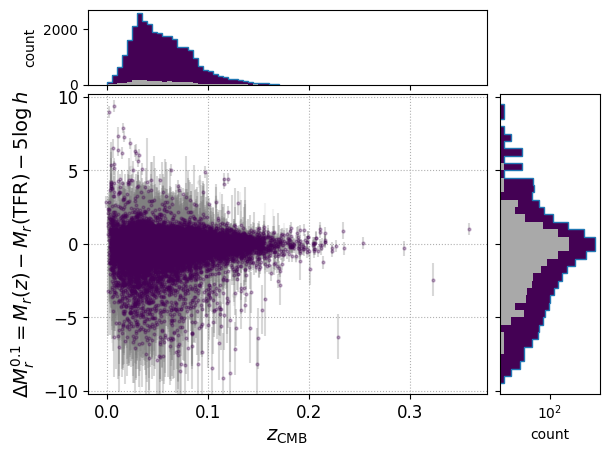

In [101]:
fig = plt.figure()

gs = fig.add_gridspec(2, 2, width_ratios=(4,1), height_ratios=(1,4), left=0.1, right=0.9, bottom=0.1, top=0.9, wspace=0.05, hspace=0.05)

ax = fig.add_subplot(gs[1,0])

sample = outlier_boolean# & morph_boolean
ax.errorbar(sgatab['Z_DESI_CMB'][sample], 
             sgatab['R_ABSMAG_SB26'][sample] - sgatab['R_ABSMAG_SB26_TF'][sample], 
             xerr=sgatab['ZERR_DESI'][sample], 
             yerr=sgatab['MU_TF_ERR'][sample],
             fmt='.', 
             color='gray',
             alpha=0.1, 
             ecolor='gray')

sample = ~outlier_boolean
ax.errorbar(sgatab['Z_DESI_CMB'][sample], 
             sgatab['R_ABSMAG_SB26'][sample] - sgatab['R_ABSMAG_SB26_TF'][sample], 
             xerr=sgatab['ZERR_DESI'][sample], 
             yerr=sgatab['MU_TF_ERR'][sample],
             fmt='.', 
             markersize=4, 
             alpha=0.3, 
             ecolor='gray')

ax.grid(ls=':')

plt.tick_params(axis='both', which='major', labelsize=12)

ax.set_xlabel(r'$z_{\text{CMB}}$', fontsize=14)
ax.set_ylabel(r'$\Delta M_r^{0.1} = M_r(z) - M_r(\text{TFR}) - 5\log h$', fontsize=14)

ax.set_ylim((-10.2, 10.2))


ax_histx = fig.add_subplot(gs[0,0], sharex=ax)
ax_histx.hist(sgatab['Z_DESI_CMB'][~outlier_boolean],
              bins=np.arange(0, 0.175, 0.005))
ax_histx.hist(sgatab['Z_DESI_CMB'][outlier_boolean],
              bins=np.arange(0, 0.175, 0.005), 
              color='darkgray')
ax_histx.hist(sgatab['Z_DESI_CMB'][~outlier_boolean],
              bins=np.arange(0, 0.175, 0.005), 
              color='tab:blue', 
              histtype='step')

ax_histx.tick_params(axis='x', labelbottom=False)
ax_histx.set_ylabel('count')


ax_histy = fig.add_subplot(gs[1,1], sharey=ax)
sample1 = ~outlier_boolean
sample2 = outlier_boolean
ax_histy.hist(sgatab['R_ABSMAG_SB26'][sample1] - sgatab['R_ABSMAG_SB26_TF'][sample1], 
              bins=np.arange(-12.5, 10, 0.5), 
              orientation='horizontal')
ax_histy.hist(sgatab['R_ABSMAG_SB26'][sample2] - sgatab['R_ABSMAG_SB26_TF'][sample2], 
              bins=np.arange(-12.5, 10, 0.5), 
              color='darkgray', 
              orientation='horizontal')
ax_histy.hist(sgatab['R_ABSMAG_SB26'][sample1] - sgatab['R_ABSMAG_SB26_TF'][sample1], 
              bins=np.arange(-12.5, 10, 0.5), 
              orientation='horizontal', 
              histtype='step', 
              color='tab:blue')

ax_histy.set_xscale('log')
ax_histy.tick_params(axis='y', labelleft=False)
ax_histy.set_xlabel('count');

## $\eta$ v. redshift

In [102]:
sgatab['LOGDIST'] = 0.2*(sgatab['MU_ZCMB'] - sgatab['MU_TF'])
sgatab['LOGDIST_ERR'] = 0.2*np.sqrt(sgatab['MU_ZCMB_ERR']**2 + sgatab['MU_TF_ERR']**2)

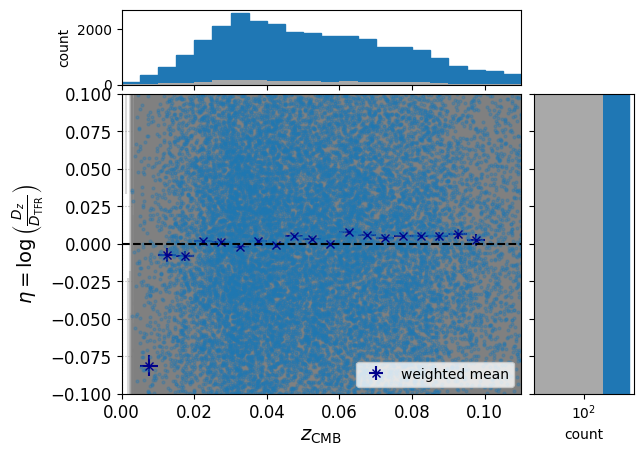

In [103]:
zbins = np.arange(0, 0.105, 0.005)
dz = 0.5*np.diff(zbins)
zc = 0.5*(zbins[1:] + zbins[:-1])

sample1 = ~outlier_boolean
sample2 = outlier_boolean

fig = plt.figure()

gs = fig.add_gridspec(2, 2, width_ratios=(4,1), height_ratios=(1,4), left=0.1, right=0.9, bottom=0.1, top=0.9, wspace=0.05, hspace=0.05)

ax = fig.add_subplot(gs[1,0])

ax.errorbar(sgatab['Z_DESI_CMB'][sample2], 
             sgatab['LOGDIST'][sample2], 
             xerr=sgatab['ZERR_DESI'][sample2], 
             yerr=sgatab['LOGDIST_ERR'][sample2],
             fmt='.', 
             color='gray',
             alpha=0.1, 
             ecolor='gray')

ax.errorbar(sgatab['Z_DESI_CMB'][sample1], 
             sgatab['LOGDIST'][sample1], 
             xerr=sgatab['ZERR_DESI'][sample1], 
             yerr=sgatab['LOGDIST_ERR'][sample1],
             fmt='.', 
             markersize=4, 
             alpha=0.3,
             color='tab:blue',
             ecolor='gray')

# Plot the weighted mean
N, y_avg, y_std = profile_histogram(sgatab['Z_DESI_CMB'][sample1], 
                                    sgatab['LOGDIST'][sample1], 
                                    zbins, 
                                    weights=sgatab['LOGDIST_ERR'][sample1]**-2, 
                                    weighted=True)
ax.errorbar(zc, y_avg, xerr=dz, yerr=y_std, fmt='x', color='darkblue', label='weighted mean')
'''
# Plot the median
N, y_avg, y_std = profile_histogram(sgatab['Z_DESI_CMB'][sample1], 
                                    sgatab['R_LOGDIST'][sample1], 
                                    zbins, 
                                    median=True)
ax.errorbar(zc, y_avg, xerr=dz, yerr=y_std, fmt='x', color='lightsteelblue', label='median')
'''
# Line at eta = 0
ax.hlines(0, 0, 0.2, linestyles='dashed', colors='k', zorder=5)

ax.legend()

ax.grid(ls=':')

plt.tick_params(axis='both', which='major', labelsize=12)

ax.set_xlabel(r'$z_{\text{CMB}}$', fontsize=14)
ax.set_ylabel(r'$\eta = \log \left( \frac{D_z}{D_{\text{TFR}}} \right)$', fontsize=14)

# ax.set_ylim((-1.9, 1.9))
ax.set_xlim((0, 0.2))
# ax.set_ylim((-0.5, 0.5))
ax.set_ylim((-0.1, 0.1))
ax.set_xlim((0, 0.11))

ax.grid(ls=':')


ax_histx = fig.add_subplot(gs[0,0], sharex=ax)
ax_histx.hist(sgatab['Z_DESI_CMB'][sample1], 
              color='tab:blue',
              bins=np.arange(0, 0.175, 0.005))
ax_histx.hist(sgatab['Z_DESI_CMB'][sample2], 
              bins=np.arange(0, 0.175, 0.005), 
              color='darkgray')
ax_histx.hist(sgatab['Z_DESI_CMB'][sample1], 
              bins=np.arange(0, 0.175, 0.005), 
              color='tab:blue', 
              histtype='step')

ax_histx.tick_params(axis='x', labelbottom=False)
ax_histx.set_ylabel('count')


ax_histy = fig.add_subplot(gs[1,1], sharey=ax)
ax_histy.hist(sgatab['LOGDIST'][sample1], 
              bins=np.arange(-2, 2, 0.1),
              color='tab:blue',
              orientation='horizontal')
ax_histy.hist(sgatab['LOGDIST'][sample2], 
              bins=np.arange(-2, 2, 0.1), 
              color='darkgray', 
              orientation='horizontal')
ax_histy.hist(sgatab['LOGDIST'][sample1], 
              bins=np.arange(-2, 2, 0.1), 
              orientation='horizontal', 
              histtype='step',
              color='tab:blue')

ax_histy.set_xscale('log')
ax_histy.tick_params(axis='y', labelleft=False)
ax_histy.set_xlabel('count');

# plt.savefig('../../Figures/Y1/iron_logdist-v-z_jointTFR-varyV0-perpdwarfs_z0p1_Anthony2_weightsVmax-1_dVsys_20250717.png', 
#             dpi=150, 
#             facecolor='none', 
#             bbox_inches='tight');

/tmp/ipykernel_316534/2699345809.py:27: RuntimeWarning: invalid value encountered in log10
  deltamarray = np.log10(dzarray/dharray)


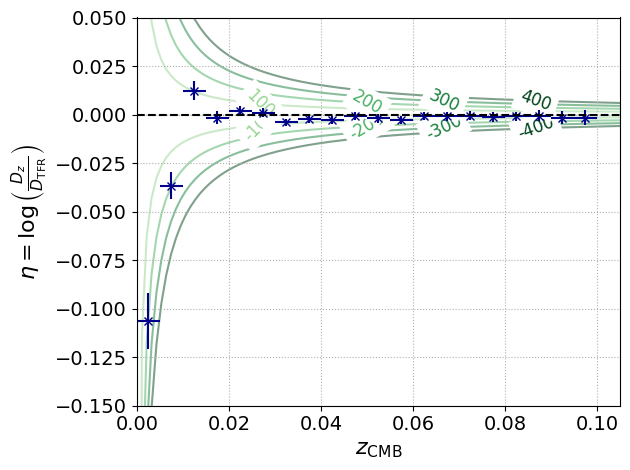

In [104]:
plt.figure(tight_layout=True)

# zbins = np.arange(0, 0.1025, 0.0025)
zbins = np.arange(0, 0.105, 0.005)
dz = 0.5*np.diff(zbins)
zc = 0.5*(zbins[1:] + zbins[:-1])

sample1=sgatab['MAIN']
# sample1=~outlier_boolean
N, y_avg, y_std = profile_histogram(sgatab['Z_DESI_CMB'][sample1], 
                                    sgatab['LOGDIST'][sample1], 
                                    zbins, 
                                    weights=sgatab['LOGDIST_ERR'][sample1]**-2, 
                                    weighted=True)
plt.errorbar(zc, y_avg, xerr=dz, yerr=y_std, fmt='x', color='darkblue', label='Main sample')



# PV lines (code taken from Cullen)
c = const.c.to('km/s')
velarray = np.arange(-400, 401, 100)
zarray = np.linspace(0.00005, 0.21, 200)

dzarray = cosmo.comoving_distance(zarray).value
dharray = cosmo.comoving_distance(np.outer(1.0/(1.0 + velarray/c.value), 
								  (1.0 + zarray)) - 1.0).value
deltamarray = np.log10(dzarray/dharray)

rotation = [20.0, 25.0, 30.0, 45.0, 0.0, -45.0, -30.0, -25.0, -20.0]
labels = ["-400", "-300", "-200", "-100", "0", "100", "200", "300", "400"]
xcoord = np.array([26000.0, 20000.0, 15000.0, 8000.0, -1000.0, 8000.0, 15000.0, 20000.0, 26000.0])
coord = np.searchsorted(zarray, xcoord/c.value)
ycoord = np.array([deltamarray[i,j] for i, j in enumerate(coord)])

colors = 0.8*np.fabs(velarray)/np.amax(np.fabs(velarray)) + 0.2

for v in range(len(velarray)):
    col = plt.cm.Greens(colors[v])

    plt.plot(zarray, deltamarray[v,:], 
             color=col, 
             linestyle='-', 
             alpha=0.5, 
             zorder=0)

    if (v != 4):
        plt.text(xcoord[v]/c.value, ycoord[v], 
                 labels[v], 
                 color=col, 
                 fontsize=12, 
                 rotation=rotation[v], 
                 ha="center", 
                 va="center", 
                 bbox=dict(boxstyle="square", ec="w", fc="w"), 
                 zorder=1)

# Line at eta = 0
plt.hlines(0, 0, 0.2, linestyles='dashed', colors='k', zorder=5)
#-------------------------------------------------------------------------------

plt.grid(ls=':')

# plt.vlines([0.03, 0.1], -0.05, 0.05, colors='gray', linestyles='dashed')

plt.tick_params(axis='both', which='major', labelsize=14)

plt.xlabel(r'$z_{\text{CMB}}$', fontsize=16)
plt.ylabel(r'$\eta = \log \left( \frac{D_z}{D_{\text{TFR}}} \right)$', 
           fontsize=16)

plt.ylim((-0.15, 0.05))
# plt.ylim((-0.12, 0.1))
# plt.ylim((-0.2, 0.2))
plt.xlim((0, 0.105))
# plt.xlim((0, 0.2))

# plt.legend(loc='lower right');

plt.savefig('/pscratch/sd/s/sgmoore1/TF/figures/TFR_DR2_eta_z_v5a.png',facecolor='none', dpi=150)

/tmp/ipykernel_2259020/2807516743.py:45: RuntimeWarning: invalid value encountered in log10
  deltamarray = np.log10(dzarray/dharray)


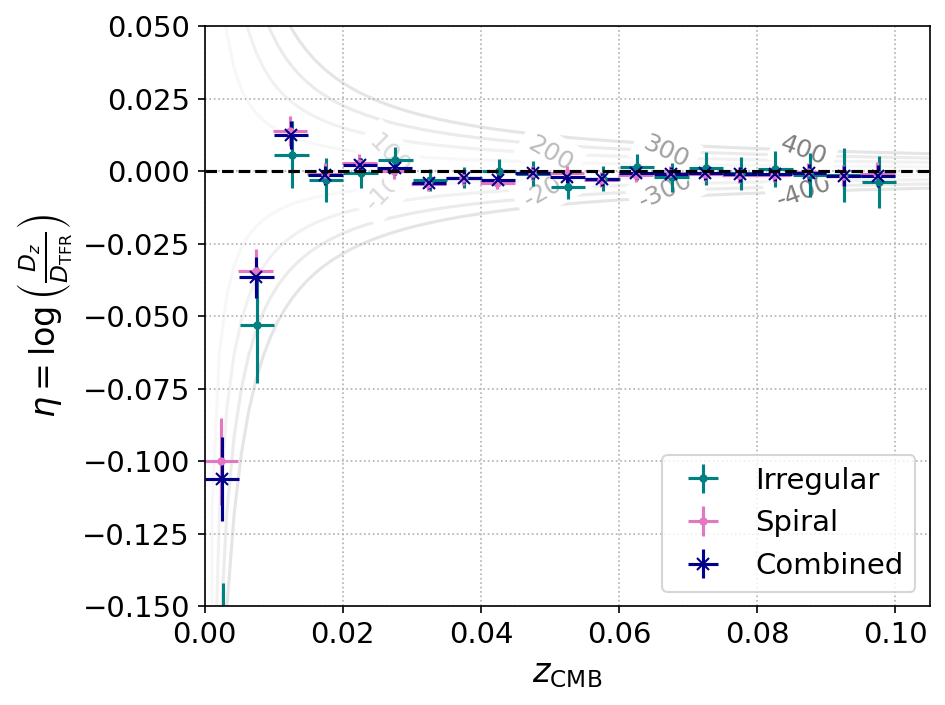

In [29]:
plt.figure(tight_layout=True,dpi=150, facecolor='none')

# zbins = np.arange(0, 0.1025, 0.0025)
zbins = np.arange(0, 0.105, 0.005)
dz = 0.5*np.diff(zbins)
zc = 0.5*(zbins[1:] + zbins[:-1])

sample1=((sgatab['MAIN']) & (sgatab['MORPHTYPE']=='Spiral'))
sample2=((sgatab['MAIN']) & (sgatab['MORPHTYPE']=='Irregular'))
sample3=((sgatab['MAIN']))


N, y_avg, y_std = profile_histogram(sgatab['Z_DESI_CMB'][sample2], 
                                    sgatab['LOGDIST'][sample2], 
                                    zbins, 
                                    weights=sgatab['LOGDIST_ERR'][sample2]**-2, 
                                    weighted=True)
plt.errorbar(zc+0.0001, y_avg, xerr=dz, yerr=y_std, fmt='.', color='teal', label='Irregular')

N, y_avg, y_std = profile_histogram(sgatab['Z_DESI_CMB'][sample1], 
                                    sgatab['LOGDIST'][sample1], 
                                    zbins, 
                                    weights=sgatab['LOGDIST_ERR'][sample1]**-2, 
                                    weighted=True)
plt.errorbar(zc-0.0001, y_avg, xerr=dz, yerr=y_std, fmt='.', color='tab:pink', label='Spiral')

N, y_avg, y_std = profile_histogram(sgatab['Z_DESI_CMB'][sample3], 
                                    sgatab['LOGDIST'][sample3], 
                                    zbins, 
                                    weights=sgatab['LOGDIST_ERR'][sample3]**-2, 
                                    weighted=True)
plt.errorbar(zc, y_avg, xerr=dz, yerr=y_std, fmt='x', color='darkblue', label='Combined')




# PV lines (code taken from Cullen)
c = const.c.to('km/s')
velarray = np.arange(-400, 401, 100)
zarray = np.linspace(0.00005, 0.21, 200)

dzarray = cosmo.comoving_distance(zarray).value
dharray = cosmo.comoving_distance(np.outer(1.0/(1.0 + velarray/c.value), 
								  (1.0 + zarray)) - 1.0).value
deltamarray = np.log10(dzarray/dharray)

rotation = [20.0, 25.0, 30.0, 45.0, 0.0, -45.0, -30.0, -25.0, -20.0]
labels = ["-400", "-300", "-200", "-100", "0", "100", "200", "300", "400"]
xcoord = np.array([26000.0, 20000.0, 15000.0, 8000.0, -1000.0, 8000.0, 15000.0, 20000.0, 26000.0])
coord = np.searchsorted(zarray, xcoord/c.value)
ycoord = np.array([deltamarray[i,j] for i, j in enumerate(coord)])

colors = 0.8*np.fabs(velarray)/np.amax(np.fabs(velarray)) + 0.2

for v in range(len(velarray)):
    col = plt.cm.Greys(colors[v])

    plt.plot(zarray, deltamarray[v,:], 
             color=col, 
             linestyle='-', 
             alpha=0.1, 
             zorder=0)

    if (v != 4):
        plt.text(xcoord[v]/c.value, ycoord[v], 
                 labels[v], 
                 color=col, 
                 fontsize=12, 
                 rotation=rotation[v], 
                 ha="center", 
                 va="center", 
                 bbox=dict(boxstyle="square", ec="w", fc="w"), 
                 zorder=1, alpha=0.5)

# Line at eta = 0
plt.hlines(0, 0, 0.2, linestyles='dashed', colors='k', zorder=5)
#-------------------------------------------------------------------------------

plt.grid(ls=':')

# plt.vlines([0.03, 0.1], -0.05, 0.05, colors='gray', linestyles='dashed')

plt.tick_params(axis='both', which='major', labelsize=14)

plt.xlabel(r'$z_{\text{CMB}}$', fontsize=16)
plt.ylabel(r'$\eta = \log \left( \frac{D_z}{D_{\text{TFR}}} \right)$', 
           fontsize=16)


plt.ylim(-0.15, 0.05)
# plt.ylim((-0.12, 0.1))
# plt.ylim((-0.2, 0.2))
plt.xlim(0, 0.105)
# plt.xlim((0, 0.2))

plt.legend(loc='lower right', fontsize=14);

# plt.savefig('/pscratch/sd/s/sgmoore1/TF/figures/TFR_DR2_eta_z_spiral_irr_v5a_.png',facecolor='none', dpi=150)

In [109]:
np.sum(sgatab['MAIN'])

28856

In [110]:
np.unique(sgatab['MORPHTYPE'][sgatab['MAIN']], return_counts=True)

(<MaskedColumn name='MORPHTYPE' dtype='bytes21' length=2>
 Irregular
    Spiral,
 array([ 5921, 22935]))

In [111]:
np.sum(sgatab['MORPHTYPE']=='Irregular'), np.sum(sgatab['MORPHTYPE']=='Elliptical'), np.sum(sgatab['MORPHTYPE']=='Lenticular'), np.sum(sgatab['MORPHTYPE']=='Spiral')

(7100, 0, 0, 25388)

In [112]:
hdr = fits.Header()

hdr['DESI_DR'] = 'DR1'
hdr['V_RADIUS'] = '0.4 R26'
hdr['M'] = slope
hdr['M_ERR'] = slope_err
hdr['M_IRR'] = slope_irr
hdr['M_IRR_ERR'] = slope_irr_err
# hdr['0PT'] = ZP
# hdr['0PT_ERR'] = ZP_err
hdr['logV0'] = logV0
hdr['SIG_SP'] = np.median(tfr_mcmc_samples[-1])
hdr['SIG_SP_ERR'] = np.sqrt(cov_tfr[-1,-1])
hdr['SIG_IRR'] = np.median(tfr_mcmc_samples_irr[-1])
hdr['SIG_IRR_ERR'] = np.sqrt(cov_tfr_irr[-1,-1])
hdr['H0'] = H0
hdr['EL_STD'] = sigma
hdr['EL_TYPE'] = 'binned'
hdr['RINTDUST'] = internalDust_coeffs_r[0]
hdr['RINTDUST_ERR'] = internalDust_coeffs_err_r[0]

# hdr['EL_MU_X'] = ellipse_mean[0]
# hdr['EL_MU_Y'] = ellipse_mean[1]

# # Ellipse covariance matrix
# hdr['EL_COV00'] = ellipse_cov[0, 0]
# hdr['EL_COV01'] = ellipse_cov[0, 1]
# hdr['EL_COV10'] = ellipse_cov[1, 0]
# hdr['EL_COV11'] = ellipse_cov[1, 1]


empty_primary = fits.PrimaryHDU(header=hdr)

## Convert all masked elements to False before saving

In [113]:
sgatab['MAIN'] = sgatab['MAIN'].filled(False)
sgatab['GOOD_MORPH'] = sgatab['GOOD_MORPH'].filled(False)

In [115]:
table_hdu = fits.BinTableHDU(data=sgatab)

hdul = fits.HDUList([empty_primary, table_hdu])

# # Write results to file
hdul.writeto('eta_cats/SGA_loa_jointTFR_v5a_unweighted_irrcal_morphcorr.fits', 
             overwrite=True)

In [ ]:
# sgatab_this = sgatab

In [133]:
hdul.writeto('/global/cfs/cdirs/desi/science/td/pv/tfgalaxies/Y3/DESI-DR2_TF_pv_cat_v5a.fits', 
             overwrite=True)

!chgrp desi /global/cfs/cdirs/desi/science/td/pv/tfgalaxies/Y3/DESI-DR2_TF_pv_cat_v5a.fits

In [11]:
sgatab= Table.read('eta_cats/SGA_loa_jointTFR_v5a_unweighted_irrcal_morphcorr.fits')